# Matrix Factorization for Recommender Systems
### Research Notebook — Lý thuyết đầy đủ + Implementation từ đầu

---
**Mục tiêu:**
- Hiểu bản chất toán học của Matrix Factorization (MF)
- Tự implement model từ đầu bằng NumPy
- Phân tích behavior dưới các điều kiện khác nhau
- Tạo nền tảng đọc/viết paper về recommender systems

**Outline:**
1. Problem Formulation
2. Matrix Factorization Model
3. Objective Function (MSE, WLS, BPR)
4. Regularization
5. Optimization: SGD và ALS
6. Bias Terms
7. Evaluation Metrics
8. Experiments on Synthetic Data
9. Experiments on Real Data
10. Limitations
11. Extensions


## Setup — Imports và utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'monospace',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

np.random.seed(42)
print("✓ Setup complete")


✓ Setup complete


---

## 1. Khái niệm & Problem Formulation (Góc nhìn lý thuyết sâu)

**Recommender System** không chỉ đơn giản là một hàm dự đoán điểm số giữa user và item, mục tiêu là **suy luận (inference) với dữ liệu đã có nhưng ít và dữ liệu bị thiếu có hệ thống và bị lệch (biased, incomplete data)**. Ta có thể biểu diễn dưới dạng:

$$
f(\text{user},\ \text{item}) \rightarrow \text{score}
$$

và hệ thống sẽ chọn ra Top-K item có score cao nhất. Tuy nhiên, cách nhìn này che giấu một thực tế quan trọng: **score mà ta học được không phải là “sở thích thật” của người dùng, mà chỉ là ước lượng từ dữ liệu quan sát được — nhiễu, không ổn định và bị chi phối bởi nhiều yếu tố bên ngoài.**

---

### Bản chất thật sự của dữ liệu trong Recommender System

Trong lý tưởng, ta muốn học một đại lượng:

$$
y_{ui}
$$

đại diện cho **true preference (utility thật)** của user $u$ đối với item $i$. Đây là thứ hệ thống thực sự cần, nhưng:

- Không thể quan sát trực tiếp
- Chỉ tồn tại dưới dạng latent variable

Thay vào đó, ta chỉ quan sát:

$$
r_{ui}
$$

là hành vi (click, rating, purchase, watch, …). Quan trọng là:

> **$r_{ui}$ không phải là $y_{ui}$, mà chỉ là một tín hiệu gián tiếp và bị nhiễu.**

---

### Quá trình sinh dữ liệu (Data Generating Process)

Để hiểu đúng bản chất của recommender system, điều quan trọng không nằm ở việc viết ra công thức, mà ở việc nhận ra rằng **dữ liệu mà ta có không phải là dữ liệu “đầy đủ” về sở thích người dùng**, mà là kết quả của một quá trình nhiều bước, trong đó thông tin bị mất đi ngay từ đầu. Thay vì nghĩ rằng hệ thống chỉ đơn giản học từ một ma trận user–item, ta cần nhìn nó như một quá trình sinh dữ liệu gồm hai tầng khác nhau: một tầng về **sở thích thật** và một tầng về **cơ hội được quan sát**.

---

#### (1) Preference process — sở thích thật (nhưng không nhìn thấy)

Ở tầng đầu tiên, mỗi user thực sự có một mức độ yêu thích nhất định đối với mỗi item. Ví dụ, bạn có thể rất thích một bộ phim nào đó, hoặc hoàn toàn không quan tâm đến một sản phẩm nào khác. Đây chính là “sự thật” mà hệ thống muốn học.

Tuy nhiên, vấn đề là:

> **Hệ thống không bao giờ nhìn thấy trực tiếp sở thích này.**

Không có database nào lưu trữ “user A thích item B ở mức 8/10”. Thứ này chỉ tồn tại trong đầu người dùng. Vì vậy, toàn bộ bài toán recommender thực chất là **đoán lại một đại lượng mà ta không thể quan sát trực tiếp**, dựa trên những tín hiệu gián tiếp.

$$ y_{ui} \rightarrow \text{mức độ user thích item} $$

Đây là biến latent mà ta muốn học.

---

#### (2) Exposure / Observation process — điều kiện để dữ liệu tồn tại

Trước khi người dùng có thể thể hiện sở thích (click, xem, mua…), họ cần phải **được thấy item đó trước**. Đây là một điều rất dễ bị bỏ qua, nhưng lại cực kỳ quan trọng.

Trong thực tế, một user không thể tương tác với toàn bộ hàng triệu item trong hệ thống. Họ chỉ thấy một tập rất nhỏ, được chọn ra bởi:

- hệ thống recommendation trước đó
- vị trí hiển thị (cái nào nằm trên cùng thì dễ được chú ý hơn)
- thời điểm (ban ngày vs ban đêm, mùa vụ, trend)
- giao diện và cách thiết kế UI

$$ o_{ui} \in \{0,1\} $$

với:
- $o_{ui} = 1$: user được expose item
- $o_{ui} = 0$: không được thấy

Xác suất:

$$ P(o_{ui} = 1) = e_{ui} $$

Điều này có nghĩa là:

> **Dữ liệu không chỉ phụ thuộc vào user thích gì, mà còn phụ thuộc vào việc user có được “cho cơ hội” để thể hiện sở thích đó hay không.**

Một item dù có phù hợp đến đâu, nếu không bao giờ được hiển thị, thì trong dữ liệu nó sẽ trông giống hệt như một item mà user không hề thích.

---

#### (3) Observed interaction — thứ duy nhất hệ thống thực sự nhìn thấy

Sau hai bước trên, thứ duy nhất còn lại trong dữ liệu là các hành vi quan sát được như click, view, rating, purchase. Đây chính là cái mà ta gọi là “interaction”.

Nhưng cần hiểu rõ rằng:

> **Interaction không phải là sở thích, mà là kết quả của cả sở thích và cơ hội được thấy.**

Nói cách khác, để một tương tác xảy ra, cần đồng thời:

- user có hứng thú với item
- và user đã nhìn thấy item đó

Nếu một trong hai điều này không xảy ra, thì:

> hệ thống sẽ không ghi nhận gì cả

Dữ liệu ta thấy thực chất là:
$$ r_{ui} = \begin{cases} g(y_{ui}) & \text{nếu } o_{ui} = 1 \\ \text{missing} & \text{nếu } o_{ui} = 0 \end{cases} $$

Trong đó $g(\cdot)$ là hàm chuyển:
- explicit: gần như identity
- implicit: threshold / Bernoulli

---

### Một số điểm cần chú ý

Khi nhìn vào dữ liệu, ta thường thấy rất nhiều cặp user–item không có tương tác. Bản năng tự nhiên ta có thể cho rằng

> “User không tương tác → chắc là không thích”

Nhưng thực tế không có thể không phải. Một giá trị “không có dữ liệu” có thể đến từ hai nguyên nhân hoàn toàn khác nhau:

- user không thích thật
- hoặc user **chưa bao giờ thấy** item đó

Và vấn đề là:

> **Hai trường hợp này trông giống hệt nhau trong dữ liệu.**

---

### Hệ quả quan trọng

Điều này dẫn đến một nhận định cực kỳ quan trọng trong recommender systems:

> **Dữ liệu mà model học không phải là toàn bộ sự thật, mà chỉ là phần sự thật đã đi qua một bộ lọc (exposure).**

Bộ lọc này không ngẫu nhiên, mà bị ảnh hưởng bởi chính hệ thống, UI, và hành vi người dùng trước đó. Vì vậy, dữ liệu luôn mang theo bias.

---

### Cách hiểu đơn giản nhất

Bạn có thể hình dung toàn bộ quá trình như sau:

- Người dùng có sở thích thật (nhưng bị ẩn)
- Hệ thống chọn một số item để hiển thị
- Người dùng chỉ phản ứng với những gì họ thấy
- Hệ thống ghi lại những phản ứng đó và coi đó là dữ liệu

---
### Insight cốt lõi — diễn giải theo góc nhìn lý thuyết

Điểm mấu chốt cần hiểu là: **dữ liệu trong recommender system không phải là phép đo trực tiếp của sở thích**, mà là kết quả của một chuỗi các quyết định và điều kiện trước đó. Khi một tương tác xuất hiện trong dữ liệu, nó không chỉ phản ánh việc người dùng có thích item hay không, mà còn phản ánh việc item đó đã được hệ thống lựa chọn để hiển thị, được đặt ở vị trí nào, và có phù hợp với ngữ cảnh tại thời điểm đó hay không.

Vì vậy, về mặt lý thuyết, mỗi điểm dữ liệu quan sát được là một **kết quả có điều kiện (conditional outcome)**, không phải là một mẫu độc lập được lấy từ toàn bộ không gian user–item. Điều này làm thay đổi hoàn toàn cách ta nên hiểu bài toán: thay vì học từ “toàn bộ thực tế”, ta đang học từ một **phiên bản đã bị lọc (filtered reality)**.

---

### Insight quan trọng — dữ liệu không phải là mẫu ngẫu nhiên

Trong các bài toán machine learning cổ điển, ta thường giả định rằng dữ liệu được lấy mẫu một cách ngẫu nhiên từ một phân phối cố định. Điều này đảm bảo rằng những gì ta học được từ dữ liệu sẽ đại diện cho thế giới thực.

Tuy nhiên, trong recommender system, giả định này bị phá vỡ ngay từ đầu. Ta không quan sát tất cả các cặp user–item, mà chỉ quan sát một tập con rất nhỏ — và tập con này không được chọn ngẫu nhiên, mà được quyết định bởi chính hệ thống.

Nói cách khác:

> **Dữ liệu mà ta có là kết quả của một quá trình chọn lọc có chủ đích, không phải là một mẫu ngẫu nhiên.**

Hệ quả là, những item xuất hiện nhiều trong dữ liệu không nhất thiết là những item tốt nhất, mà có thể chỉ là những item đã được hiển thị nhiều hơn. Ngược lại, những item ít xuất hiện không phải vì chúng kém, mà có thể vì chúng chưa có cơ hội được hiển thị.

---

### Missing Not At Random (MNAR) — bản chất của việc thiếu dữ liệu

MNAR (Missing Not At Random) là một khái niệm trong thống kê mô tả cách dữ liệu bị thiếu — cụ thể là trường hợp mà **việc dữ liệu bị thiếu phụ thuộc vào chính giá trị thật của dữ liệu đó.**

Giải thích trực quan. Hãy hiểu theo cách đơn giản:

- Có những dữ liệu bị thiếu ngẫu nhiên → không sao
- Nhưng có những dữ liệu bị thiếu vì bản thân nó có giá trị đặc biệt → nguy hiểm

> MNAR là trường hợp thứ hai.

Ví dụ bạn hỏi mọi người:

> “Thu nhập của bạn là bao nhiêu?”

- Người thu nhập bình thường → trả lời
- Người thu nhập rất cao → không muốn trả lời
- Người thu nhập rất thấp → cũng không muốn trả lời

**Kết quả**:

- Dữ liệu bị thiếu không ngẫu nhiên
- Nó phụ thuộc vào chính giá trị thu nhập

→ Đây chính là MNAR

Trong nhiều bài toán thống kê, dữ liệu bị thiếu thường được giả định là “thiếu ngẫu nhiên”, nghĩa là việc thiếu hay không thiếu không liên quan đến giá trị thực của dữ liệu. Nhưng trong recommender system, điều này không đúng.

Ở đây, việc một tương tác có được quan sát hay không lại phụ thuộc vào chính mức độ hấp dẫn của item và hành vi của user. Những item hấp dẫn thường dễ được click hơn, dễ được hệ thống ưu tiên hiển thị hơn, và do đó xuất hiện nhiều hơn trong dữ liệu. Ngược lại, những item ít phổ biến hoặc ít được chú ý sẽ ít có cơ hội xuất hiện.

Điều này dẫn đến một tình huống:

> **Dữ liệu bị thiếu theo một cách có hệ thống, và sự thiếu này mang thông tin về chính dữ liệu.**

Đây chính là bản chất của **Missing Not At Random (MNAR)**.

Áp dụng vào Recommender System

- Ta không thấy tất cả user–item
- Ta chỉ thấy những gì user đã tương tác

Nhưng:

> User chỉ tương tác với những item họ thấy và (thường là) họ thích

Điều này dẫn đến:
- Item hấp dẫn → dễ được click → xuất hiện nhiều trong data
- Item không hấp dẫn → ít click → ít xuất hiện
- Item chưa được hiển thị → hoàn toàn không có data

Insight quan trọng

> Việc một cặp user–item có xuất hiện trong dữ liệu hay không phụ thuộc vào chính mức độ “hấp dẫn” của nó.

**Vì sao MNAR nguy hiểm?**

Trong machine learning, ta thường giả định dữ liệu là đại diện cho toàn bộ thế giới.

Nhưng với MNAR dữ liệu bị lệch dẫn đến những gì ta thấy khác thực tế. Hệ quả
- Model học sai phân phối
- Overestimate item phổ biến
- Ignore item ít xuất hiện
- Feedback loop xảy ra

> MNAR = cái gì bị thiếu là vì chính nó “đặc biệt”.

---

### Hệ quả lý thuyết — khi giả định thống kê bị phá vỡ

Khi dữ liệu không còn được lấy mẫu ngẫu nhiên, nhiều giả định nền tảng của machine learning không còn đúng nữa. Cụ thể:

1. Thứ nhất, các điểm dữ liệu không còn độc lập và phân phối giống nhau (i.i.d). Chúng bị phụ thuộc vào quá trình hiển thị và các quyết định trước đó của hệ thống.
2. Thứ hai, dữ liệu bị **selection bias**, nghĩa là một số loại item hoặc user được đại diện nhiều hơn trong dữ liệu, trong khi những loại khác bị thiếu hụt.
3. Thứ ba, các phương pháp học dựa trên empirical risk (tức là tối ưu trên dữ liệu quan sát được) không còn đảm bảo rằng chúng đang tối ưu đúng mục tiêu trong thế giới thực. Nói cách khác, mô hình có thể rất tốt trên dữ liệu hiện có, nhưng lại không phản ánh đúng sở thích thực sự của người dùng.

---

### Kết luận trực quan nhưng mang tính lý thuyết

> **Model không học từ “sự thật”, mà học từ “phiên bản của sự thật đã bị hệ thống gián tiếp ảnh hưởng”.**

Và chính vì vậy, một trong những thách thức lớn nhất của recommender systems không phải là xây dựng model mạnh hơn, mà là **hiểu và xử lý sự lệch (bias) trong dữ liệu** mà model đang học từ đó.
---
### Mục tiêu thực sự của hệ thống — diễn giải trực quan

Khi mới tiếp cận recommender system, ta rất dễ nghĩ rằng mục tiêu của model là **dự đoán lại những gì đã xảy ra**, tức là học sao cho đầu ra gần giống với dữ liệu quan sát được. Nói cách khác, ta tưởng rằng chỉ cần học một hàm sao cho:

- user nào đã click thì dự đoán cao
- user nào không click thì dự đoán thấp

Nhưng cách hiểu này là chưa đúng về mặt lý thuyết.

Lý do là vì dữ liệu quan sát được không phản ánh đầy đủ sở thích thật của người dùng. Nó chỉ phản ánh **hành vi trong những tình huống mà hệ thống đã tạo ra**. Do đó, nếu model chỉ học để khớp với dữ liệu này, nó sẽ học cả những bias có sẵn trong hệ thống.

---

### Điều hệ thống thực sự cần học

Thay vì cố gắng **bắt chước dữ liệu**, mục tiêu đúng hơn là:

> **Ước lượng xem nếu user thực sự được tiếp xúc với item, thì họ sẽ thích nó đến mức nào.**

Điều này có nghĩa là model đang cố gắng trả lời một câu hỏi mang tính giả định:

> Nếu user này nhìn thấy item kia, họ có thích không?

chứ không phải:

> User này đã từng tương tác với item đó chưa?

---

### Insight quan trọng

> **Model tốt không phải là model dự đoán đúng quá khứ, mà là model dự đoán đúng những gì chưa xảy ra.**

Đây chính là điểm khác biệt lớn giữa recommender system và nhiều bài toán supervised learning thông thường.

---

## Matrix Factorization

Matrix Factorization thường được giới thiệu như một kỹ thuật phân tích ma trận, nơi ta **tách** ma trận user–item thành hai ma trận nhỏ hơn. Nhưng nếu chỉ hiểu như vậy thì rất dễ bị lệch hướng.

Cách hiểu sâu hơn là:

> **Matrix Factorization là một mô hình giả định rằng mỗi user và mỗi item đều có một “vector đặc trưng ẩn”, và mức độ phù hợp giữa chúng được quyết định bởi sự tương tác giữa hai vector này.**

---

### Ý nghĩa của latent representation — mở rộng (góc nhìn sâu hơn)

Latent representation không chỉ là một cách biểu diễn “gọn hơn” của dữ liệu, mà thực chất là **cách model xây dựng một không gian khái niệm (conceptual space)** để hiểu mối quan hệ giữa user và item. Nếu hiểu đúng, đây là phần cốt lõi nhất của recommender system.

**Từ “bảng dữ liệu” sang “không gian ý nghĩa”**

Ma trận user–item ban đầu chỉ là một bảng:

- hàng = user
- cột = item
- giá trị = tương tác

Nhưng bảng này không cho ta biết:

- user giống nhau ở điểm nào
- item giống nhau ở điểm nào
- vì sao một tương tác xảy ra

Latent representation biến bảng này thành một **không gian**, trong đó:

- mỗi user là một điểm
- mỗi item là một điểm
- khoảng cách / hướng giữa chúng mang ý nghĩa

> **Model không còn nhìn dữ liệu như bảng, mà như một “hình học” (geometry) trong không gian.**

---

**Không gian latent = không gian của hành vi, không phải thuộc tính thật**

Một hiểu nhầm phổ biến là nghĩ rằng latent dimension tương ứng trực tiếp với:

- genre (phim hành động, tình cảm…)
- category (đồ điện tử, thời trang…)

Nhưng thực tế:

> **Latent space không được học từ metadata, mà từ pattern hành vi.**

---

### Ví dụ

Model có thể học một chiều như:

- “những item mà user kiểu A thích”

Chiều này có thể:

- gần với “action”
- nhưng cũng có thể là “phim có tiết tấu nhanh + nhiều plot twist”

> **Latent feature là “cách data tự tổ chức”, không phải cách con người định nghĩa.**

---

**Dot product không phải ngẫu nhiên — nó có ý nghĩa hình học**

Khi ta tính:

- độ phù hợp = tích vô hướng giữa user vector và item vector

thực chất ta đang đo:

- mức độ “cùng hướng” giữa hai vector

---

### Trực giác

- user vector chỉ hướng “sở thích”
- item vector chỉ hướng “đặc trưng”

Nếu hai vector:

- cùng hướng → phù hợp cao
- ngược hướng → không phù hợp

> **Recommendation là bài toán “align vector”, không phải lookup bảng.**

---

**Latent space cho phép “so sánh gián tiếp”**

Một trong những sức mạnh lớn nhất của latent representation là:

> **Ta có thể so sánh những thứ chưa từng xuất hiện cùng nhau.**

---

### Ví dụ

- User A chưa bao giờ xem item X
- Nhưng:
  - A giống user B
  - B thích X

→ model vẫn suy ra A có thể thích X

> **Latent space cho phép lan truyền thông tin qua cấu trúc.**

Embedding là một dạng **nén thông tin có cấu trúc**. Thay vì lưu:

- hàng triệu tương tác rời rạc

ta nén thành:

- vài chục chiều latent

Nhưng điều quan trọng là:

> **Đây không phải nén thông tin ngẫu nhiên, mà là nén giữ lại cấu trúc quan trọng.**

---

### So sánh

- Ma trận: nhiều dữ liệu nhưng rời rạc
- Latent: ít chiều nhưng có cấu trúc

---

### Insight

> **Latent representation là dạng “compression có hiểu biết”.**

---

**Tại sao nó giải được sparsity?**

Trong ma trận gốc:

- mỗi user chỉ có vài tương tác
- phần lớn là missing

Nhưng trong latent space:

- mỗi user có vector đầy đủ
- mỗi item có vector đầy đủ

---

### Điều này có nghĩa

> **Model đã “lấp đầy” thông tin bằng cách học cấu trúc chung.**
> **Latent factor biến bài toán sparse thành bài toán dense.**

---

Không gian latent có thể học được quan hệ phức tạp, latent space không chỉ encode similarity (giống nhau) mà còn encode:

- hierarchy
- cluster
- direction

---

### Ví dụ

- nhóm user thích anime
- nhóm user thích documentary
- nhóm user overlap cả hai

Tất cả có thể xuất hiện tự nhiên trong không gian latent.
> **Latent space không chỉ lưu thông tin, mà còn tổ chức thông tin.**

---

**Tại sao cách này mạnh hơn rule-based?**

Nếu bạn dùng rule-based:

- nếu user thích action → recommend action

thì bạn đang:

- giả định structure trước

Trong khi latent:

- tự học structure từ data

> **Latent representation không cần định nghĩa feature trước — nó tự khám phá feature.**

Để hiểu đúng, cũng cần thấy giới hạn:

- latent không luôn “interpretable”
- có thể học bias từ data
- phụ thuộc mạnh vào quality của data

> **Latent space mạnh vì nó linh hoạt, nhưng cũng nguy hiểm vì nó học cả bias.**

Latent representation không chỉ là kỹ thuật, mà là một cách nhìn:

> **Ta không học trực tiếp từ dữ liệu, mà học một không gian ẩn giải thích dữ liệu.**
> **Recommender system không tìm item giống nhau — nó tìm những item nằm gần nhau trong “không gian ý nghĩa” mà model tự học ra.**

---

### Vai trò của noise

Trong thực tế, hành vi người dùng luôn có nhiễu:

- cùng một user, cùng một item, nhưng ở thời điểm khác nhau có thể hành xử khác nhau
- mood, context, thời gian đều ảnh hưởng

Do đó, model không giả định rằng mọi thứ là chính xác tuyệt đối, mà luôn có một phần sai lệch ngẫu nhiên.

Điều này phản ánh một ý tưởng quan trọng:

> **Dữ liệu hành vi không bao giờ là tín hiệu “sạch”, mà luôn chứa nhiễu.**

---

## Diễn giải xác suất — cách nhìn mang tính lý thuyết

Khi nhìn dưới góc độ xác suất, Matrix Factorization không còn là một kỹ thuật tuyến tính đơn giản, mà trở thành một mô hình sinh dữ liệu.

Cụ thể, ta giả định rằng:

- mỗi user và item được sinh ra từ một phân phối nào đó
- các vector latent không phải là tùy ý, mà tuân theo một cấu trúc xác suất

Điều này mang lại một insight quan trọng:

> **Regularization không phải là một mẹo kỹ thuật, mà là cách ta áp đặt niềm tin (prior) về cấu trúc của dữ liệu.**

Nói cách khác, khi ta ép các vector không được quá lớn hoặc quá phức tạp, ta đang nói rằng:

- sở thích của user không quá “dị”
- item không có đặc trưng quá cực đoan

---

### Kết luận mang tính lý thuyết

Toàn bộ framework này dẫn đến một cách hiểu sâu hơn:

> **Recommender system không phải là bài toán nội suy dữ liệu đã thấy, mà là bài toán suy luận cấu trúc ẩn của sở thích từ dữ liệu không đầy đủ và có nhiễu.**

Và Matrix Factorization chỉ là một trong những cách đơn giản nhất để hiện thực hóa giả định đó.

---

### Regularization là gì? — cách hiểu mang tính bản chất

Khi nhìn vào công thức, nhiều người thường nghĩ regularization chỉ là một “kỹ thuật thêm vào” để tránh overfitting, giống như một mẹo kỹ thuật giúp model không học quá sát dữ liệu. Tuy nhiên, cách hiểu này là khá nông.

Về mặt lý thuyết, regularization thực chất phản ánh một giả định rất quan trọng:

> **Ta tin rằng sở thích của user và đặc trưng của item không phải là ngẫu nhiên hoàn toàn, mà có cấu trúc và bị giới hạn.**

Nói cách khác, khi ta thêm regularization, ta đang ngầm nói rằng:

- user không thể có sở thích cực đoan theo mọi hướng
- item không thể có đặc trưng quá “dị” hoặc quá phức tạp
- các embedding nên nằm trong một không gian “hợp lý”

Điều này tương đương với việc đặt một **prior** lên các vector latent. Nếu không có prior này, model có thể “bịa ra” những biểu diễn rất cực đoan chỉ để khớp dữ liệu, nhưng lại không có ý nghĩa gì trong thực tế.

---

### Insight quan trọng

> **Regularization không phải là để “fix model”, mà là để đưa kiến thức trước (prior knowledge) vào bài toán.**

---

## Tại sao latent factor lại hoạt động?

Nếu chỉ nhìn bề ngoài, matrix factorization có vẻ như là một kỹ thuật toán học khá cơ học: tách một ma trận lớn thành hai ma trận nhỏ hơn. Nhưng điều khiến nó thực sự hiệu quả không nằm ở phép toán, mà nằm ở một giả định sâu hơn về thế giới.

Giả định đó là:

> **Sở thích của con người không phải là ngẫu nhiên, mà có cấu trúc và có thể được biểu diễn bằng một số chiều ẩn nhỏ.**

---

### Trực giác phía sau

Hãy tưởng tượng thay vì hàng triệu item khác nhau, ta mô tả chúng bằng một số “trục ý nghĩa” như:

- mức độ giải trí
- mức độ nghiêm túc
- thể loại (action, romance, drama…)
- độ phổ biến

Tương tự, mỗi user cũng có “tọa độ” trên các trục này.

Khi đó:

- việc user thích item hay không
- không còn là một quan hệ rời rạc
- mà trở thành một phép “khớp” trong không gian đặc trưng

---

### Ý nghĩa sâu hơn

Điều này dẫn đến một insight quan trọng:

> **Dữ liệu user–item có vẻ rất lớn và phức tạp, nhưng thực chất nằm trên một cấu trúc thấp chiều.**

Hay nói cách khác:

- Ma trận lớn chỉ là biểu hiện bề mặt
- Cấu trúc thật nằm trong không gian latent nhỏ hơn nhiều

Có thể nói rằng các chiều nhỏ hơn thông qua nhiều cách biểu diễn và kết hợp với môi trường, nền tảng và nghiệp vụ hay những ảnh hưởng có thể quan sát được trong  đời sống đã khuếch đại đặc trưng tạo nên môột bề mặt lớn hơn nhưng nguoofnn gốc vẫn bắt đầu từ những cấu trúc chiều thấp mà ta đã đề cập làm cơ sở

---

## Sparsity — nhưng vấn đề thật sự là bias

Một trong những đặc điểm rõ ràng nhất của dữ liệu recommender là cực kỳ thưa (sparse). Phần lớn các cặp user–item không có tương tác.

Nhưng nếu chỉ dừng ở việc nói “data sparse” thì chưa đủ sâu. Vấn đề nghiêm trọng hơn là:

> **Những gì ta quan sát được không phải là một mẫu đại diện cho toàn bộ không gian.**

---

### Tại sao đây mới là vấn đề chính?

Nếu dữ liệu chỉ đơn thuần là sparse nhưng vẫn ngẫu nhiên, thì model vẫn có thể học được phân phối đúng (dù chậm hơn). Nhưng trong recommender system:

- dữ liệu không chỉ thiếu
- mà còn bị lệch theo một hướng nhất định

Ví dụ:

- item phổ biến xuất hiện nhiều
- item niche gần như không xuất hiện
- user active có nhiều data
- user mới gần như không có gì

---

### Insight quan trọng

> **Ta không chỉ thiếu dữ liệu, mà còn thiếu dữ liệu một cách có hệ thống.**

---

## Hệ quả lý thuyết

Những đặc điểm trên dẫn đến một số hệ quả rất quan trọng:

---

### (1) Cold-start là bài toán không xác định tốt (ill-posed)

Khi một user hoặc item mới xuất hiện:

- gần như không có dữ liệu
- không đủ thông tin để xác định embedding

Điều này không phải do model yếu, mà là do:

> **Bài toán bản chất là không đủ thông tin để giải.**

---

### (2) Model học exposure thay vì preference

Vì dữ liệu bị lệch bởi việc hiển thị, model dễ học:

- cái gì được thấy nhiều → dự đoán cao

thay vì:

- cái gì thực sự phù hợp → dự đoán cao

---

### (3) Feedback loop (vòng lặp tự củng cố)

Đây là một hệ quả rất quan trọng trong thực tế:

- Model recommend item phổ biến
- User tương tác với item đó
- Data mới reinforce rằng item đó “tốt”
- Model càng recommend nó nhiều hơn

Kết quả:

> **Hệ thống tự củng cố bias của chính nó theo thời gian.**

---

### Kết luận mang tính lý thuyết

> **Khó khăn của recommender system không nằm ở việc thiếu dữ liệu, mà nằm ở việc dữ liệu vừa thiếu vừa bị lệch.**

Và chính sự kết hợp này khiến bài toán trở nên khó hơn rất nhiều so với các bài toán machine learning thông thường.

---
## Explicit vs Implicit — khác biệt bản chất (diễn giải lý thuyết dễ hiểu)

Khi nói về dữ liệu trong recommender system, sự khác biệt giữa explicit và implicit không chỉ là “dạng dữ liệu khác nhau”, mà là **khác nhau về bản chất thông tin mà ta đang quan sát**. Nếu không hiểu đúng điểm này, rất dễ áp dụng sai mô hình hoặc hiểu sai kết quả.

---

### Explicit feedback — tín hiệu trực tiếp (nhưng vẫn có nhiễu)

Với explicit feedback, người dùng **chủ động cung cấp thông tin về sở thích**, ví dụ như chấm điểm phim, đánh giá sản phẩm, hoặc bấm like/dislike. Điều quan trọng là:

> **Ta đang quan sát trực tiếp một phiên bản gần đúng của sở thích thật.**

Tuy nhiên, “trực tiếp” không có nghĩa là “chính xác tuyệt đối”. Những tín hiệu này vẫn có nhiễu vì:

- Người dùng có thể chấm điểm theo cảm xúc nhất thời
- Hai người khác nhau có thể hiểu thang điểm khác nhau
- Cùng một người, ở thời điểm khác nhau có thể cho điểm khác nhau

Dù vậy, về mặt lý thuyết, explicit feedback vẫn là một dạng **measurement khá gần với ground truth**, nên việc dùng các mô hình dự đoán giá trị (regression) là hợp lý.

---

### Implicit feedback — tín hiệu gián tiếp và không đầy đủ

Ngược lại, implicit feedback không phải là “ý kiến” của người dùng, mà là **hành vi**:

- click
- view
- purchase
- watch time

Ở đây, ta không thấy người dùng “nói gì”, mà chỉ thấy họ “làm gì”.

Vấn đề là:

> **Hành vi không chỉ phụ thuộc vào sở thích, mà còn phụ thuộc vào hoàn cảnh.**

Một user có thể thích một item nhưng không click vì:

- không nhìn thấy
- không chú ý
- không có thời gian
- bị distract bởi item khác

Do đó, khi ta thấy:

- user click → có thể họ thích
- user không click → hoàn toàn không rõ

---

### Điểm mấu chốt của implicit data

> **“Không có tương tác” không phải là một tín hiệu rõ ràng.**

Nó có thể mang nhiều ý nghĩa khác nhau, nhưng trong dữ liệu, tất cả đều trông giống nhau. Đây chính là điểm làm implicit feedback khó hơn rất nhiều về mặt lý thuyết.

---

## Vấn đề lý thuyết — sự nhập nhằng giữa sở thích và cơ hội

Một trong những khó khăn lớn nhất của implicit feedback là:

> **Ta không thể tách biệt được đâu là do user không thích, và đâu là do user chưa có cơ hội tiếp cận.**

Hai yếu tố này bị “trộn” vào nhau trong dữ liệu, tạo ra cái gọi là **confounding**.

---

### Hiểu một cách trực quan

Khi nhìn vào một cặp user–item không có tương tác, ta không biết:

- user đã thấy và không thích
- hay user chưa từng thấy

Nhưng model buộc phải đưa ra một con số duy nhất.

Điều này dẫn đến một tình huống:

> **Model phải học từ dữ liệu mà bản thân dữ liệu đã mơ hồ.**

---

## Weighted Matrix Factorization — một cách xử lý gần đúng

Để đối phó với sự mơ hồ này, một ý tưởng quan trọng là:

> **Không nên đối xử tất cả các điểm dữ liệu giống nhau.**

Cụ thể:

- Những tương tác đã xảy ra → đáng tin hơn
- Những chỗ không có dữ liệu → ít tin hơn

---

### Trực giác phía sau “confidence”

Thay vì nói:

- “có tương tác = 1”
- “không tương tác = 0”

ta chuyển sang cách hiểu:

- “có tương tác → rất có thể user thích”
- “không tương tác → chưa biết rõ”

---

### Insight quan trọng

> **Không phải mọi dữ liệu đều đáng tin như nhau.**

Những gì user đã làm (click, mua) mang nhiều thông tin hơn rất nhiều so với những gì họ không làm.

---

## Ranking thay vì Regression — thay đổi mục tiêu học

Trong nhiều hệ thống thực tế, ta không thực sự cần biết:

- user thích item ở mức 7 hay 8

Mà chỉ cần biết:

- item A có nên đứng trên item B hay không

---

### Trực giác

Nếu hệ thống phải hiển thị 10 item, điều quan trọng là:

- chọn đúng 10 item tốt nhất
- và sắp xếp chúng hợp lý

Giá trị tuyệt đối của score không quan trọng bằng **thứ tự tương đối**.

---

### Ý nghĩa lý thuyết

Điều này dẫn đến một thay đổi quan trọng:

> **Recommender system không phải là bài toán dự đoán giá trị, mà là bài toán ra quyết định (decision problem).**

Model không cần mô tả chính xác thế giới, mà cần:

- đưa ra lựa chọn tốt nhất trong số các lựa chọn có thể

---

### Kết luận

- Explicit feedback: gần với “sự thật”, nên dễ học hơn
- Implicit feedback: là tín hiệu gián tiếp, mơ hồ và bị bias
- Weighted MF: cố gắng xử lý sự không chắc chắn trong dữ liệu
- Ranking: phù hợp hơn với mục tiêu thực tế của hệ thống

---

### Insight chốt

> **Trong recommender system, điều quan trọng không phải là dự đoán đúng từng điểm dữ liệu, mà là đưa ra thứ tự đúng cho những gì chưa xảy ra.**

---
## Two-stage architecture — vì sao đây là hệ quả tất yếu (không chỉ là tối ưu hệ thống)

Khi nhìn vào kiến trúc hai giai đoạn (candidate generation → ranking), nhiều người nghĩ đây đơn thuần là một “giải pháp kỹ thuật” để tăng tốc. Điều đó đúng, nhưng chưa đủ. Ở mức sâu hơn, kiến trúc này phản ánh một thực tế quan trọng:

> **Ta không thể vừa “tìm kiếm toàn bộ không gian” vừa “đánh giá chính xác” trong cùng một bước.**

---

### Bản chất của vấn đề

Trong thực tế, số lượng item là cực kỳ lớn (hàng triệu đến hàng tỷ). Nếu mỗi lần user truy cập mà ta phải:

- tính score cho toàn bộ item
- rồi sắp xếp toàn bộ

thì gần như không thể đạt yêu cầu realtime.

Nhưng vấn đề không chỉ là tốc độ. Nếu ta cố làm một model duy nhất xử lý toàn bộ:

- Model sẽ phải rất đơn giản để đủ nhanh
- Và vì đơn giản, nó sẽ không đủ khả năng phân biệt tinh vi giữa các item

Ngược lại, nếu ta dùng model phức tạp:

- nó sẽ chính xác hơn
- nhưng không thể chạy trên toàn bộ item trong thời gian ngắn

---

### Insight quan trọng

> **Không tồn tại một model duy nhất vừa nhanh vừa chính xác trên toàn bộ không gian.**

Do đó, hệ thống buộc phải tách bài toán thành hai bước với hai mục tiêu khác nhau.

---

## Candidate Generation — bước “lọc thô”

Ở giai đoạn đầu, mục tiêu không phải là chọn ra item tốt nhất, mà là:

> **Không bỏ sót những item có khả năng tốt.**

Hệ thống sẽ lấy từ toàn bộ tập item một tập con nhỏ hơn nhiều, thường chỉ vài trăm hoặc vài nghìn item. Đây là bước “lọc thô”, nơi:

- ưu tiên tốc độ
- chấp nhận sai số
- miễn là giữ lại được phần lớn item tiềm năng

---

### Cách hiểu đúng

Candidate generation không trả lời:

- “item nào là tốt nhất?”

mà trả lời:

- “item nào *có thể* là tốt?”

---

### Ý nghĩa lý thuyết

Đây là bước đảm bảo **recall**:

> **Nếu một item tốt bị loại ở bước này, nó sẽ không bao giờ có cơ hội xuất hiện ở kết quả cuối.**

---

## Ranking — bước “chọn chính xác”

Sau khi đã có một tập ứng viên nhỏ, hệ thống mới áp dụng model phức tạp hơn để:

- đánh giá kỹ từng item
- sắp xếp theo mức độ phù hợp
- chọn ra Top-K

Ở bước này:

- tốc độ không còn là vấn đề lớn (vì tập nhỏ)
- độ chính xác trở thành ưu tiên hàng đầu

---

### Cách hiểu đúng

Ranking không cần tìm kiếm toàn bộ không gian nữa, mà chỉ cần:

> **so sánh chính xác giữa các lựa chọn đã được lọc ra.**

---

### Insight quan trọng

> **Candidate generation quyết định “có cơ hội hay không”, còn ranking quyết định “thứ tự cuối cùng”.**

---

## Vì sao kiến trúc này còn liên quan đến lý thuyết?

Không chỉ là vấn đề engineering, two-stage architecture còn liên quan trực tiếp đến bản chất dữ liệu:

- Dữ liệu đã bị bias bởi exposure
- Model không thể phân biệt tốt trên toàn bộ không gian ngay từ đầu
- Việc thu hẹp không gian giúp giảm nhiễu và tăng khả năng học

---

## Kết luận lý thuyết cốt lõi

Nếu nhìn ở mức sâu hơn, recommender system không phải là bài toán:

- “điền vào các ô còn thiếu trong ma trận”

mà là:

> **Bài toán suy luận sở thích tiềm ẩn từ dữ liệu không đầy đủ, bị lệch, và bị chi phối bởi quá trình hiển thị.**

Điều này khiến nó khác biệt hoàn toàn so với các bài toán machine learning truyền thống.

---

## Insight quan trọng nhất — diễn giải lại theo cách chặt chẽ hơn

Thay vì chỉ liệt kê, ta có thể gom lại thành một nhận định thống nhất:

> **Dữ liệu quan sát trong recommender system không phải là ground truth, mà là kết quả của một quá trình chọn lọc phụ thuộc vào cả hệ thống và hành vi người dùng.**

Từ đó suy ra:

- Những gì ta thấy không đại diện cho toàn bộ thực tế
- Những gì ta không thấy không có nghĩa là không tồn tại
- Model học từ dữ liệu này sẽ kế thừa toàn bộ bias của nó

Và vì vậy:

> **Bài toán thực sự không phải là học từ dữ liệu, mà là học vượt qua sự lệch của dữ liệu.**

---

## Hướng nghiên cứu

Khi đi sâu hơn, các vấn đề cốt lõi không còn nằm ở model đơn thuần, mà nằm ở việc xử lý bias và thiếu hụt thông tin:

- Làm sao để điều chỉnh lại dữ liệu để gần với phân phối thật hơn (debiasing)
- Làm sao để suy luận “điều gì sẽ xảy ra nếu user thấy item” (counterfactual reasoning)
- Làm sao để mô hình hóa riêng quá trình exposure thay vì bỏ qua nó
- Làm sao để đảm bảo model tốt trong thực tế, không chỉ trên dữ liệu offline

---

### Insight cuối cùng

> **Recommender system không khó vì model yếu, mà vì dữ liệu không phản ánh đúng thực tế.**

Users (m): 5
Items (n): 8
Observed entries: 17 / 40
Density: 42.5%
Missing entries: 23 (to be predicted)



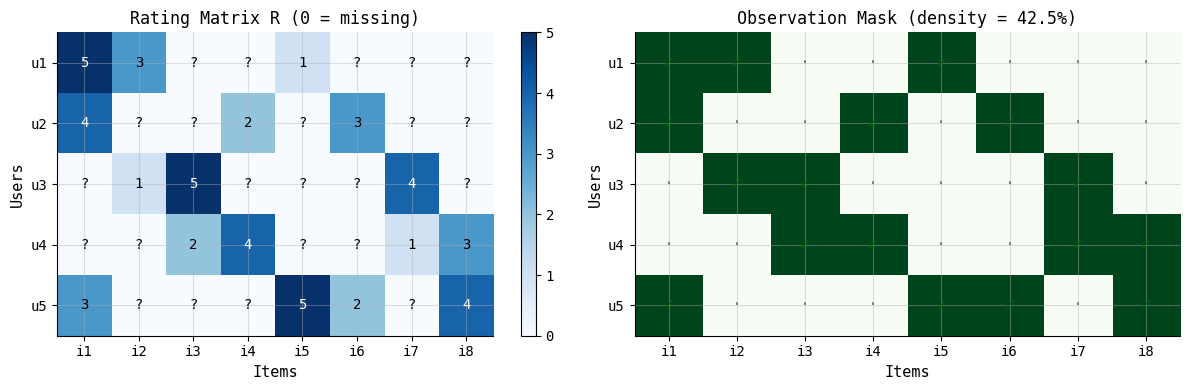

In [2]:
# ─── Ví dụ: User–Item Interaction Matrix ────────────────────────────────────

# 0 = missing (unobserved), không phải rating = 0
R_raw = np.array([
    [5, 3, 0, 0, 1, 0, 0, 0],
    [4, 0, 0, 2, 0, 3, 0, 0],
    [0, 1, 5, 0, 0, 0, 4, 0],
    [0, 0, 2, 4, 0, 0, 1, 3],
    [3, 0, 0, 0, 5, 2, 0, 4],
], dtype=float)

mask = (R_raw != 0).astype(float)   # 1 = observed, 0 = missing
m, n = R_raw.shape

print(f"Users (m): {m}")
print(f"Items (n): {n}")
print(f"Observed entries: {int(mask.sum())} / {m*n}")
print(f"Density: {mask.mean():.1%}")
print(f"Missing entries: {int((1-mask).sum())} (to be predicted)\n")

# Visualize matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap of raw ratings
im1 = axes[0].imshow(R_raw, cmap='Blues', aspect='auto', vmin=0, vmax=5)
axes[0].set_title('Rating Matrix R (0 = missing)')
axes[0].set_xlabel('Items')
axes[0].set_ylabel('Users')
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(m))
axes[0].set_xticklabels([f'i{j+1}' for j in range(n)])
axes[0].set_yticklabels([f'u{i+1}' for i in range(m)])
for i in range(m):
    for j in range(n):
        val = R_raw[i,j]
        txt = f'{int(val)}' if val > 0 else '?'
        axes[0].text(j, i, txt, ha='center', va='center',
                     color='white' if val > 3 else 'black', fontsize=10)
plt.colorbar(im1, ax=axes[0])

# Sparsity visualization
im2 = axes[1].imshow(mask, cmap='Greens', aspect='auto', vmin=0, vmax=1)
axes[1].set_title(f'Observation Mask (density = {mask.mean():.1%})')
axes[1].set_xlabel('Items')
axes[1].set_ylabel('Users')
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(m))
axes[1].set_xticklabels([f'i{j+1}' for j in range(n)])
axes[1].set_yticklabels([f'u{i+1}' for i in range(m)])
for i in range(m):
    for j in range(n):
        txt = '✓' if mask[i,j] else '·'
        axes[1].text(j, i, txt, ha='center', va='center', fontsize=12,
                     color='darkgreen' if mask[i,j] else 'gray')
plt.tight_layout()
plt.show()


## Phân tích lý thuyết từ User–Item Matrix

---

### 1. “Missing” không phải là giá trị, mà là *không có thông tin*

Trong ma trận, các ô trống (được ký hiệu bằng 0 hoặc “?”) không có nghĩa là user đánh giá item thấp, mà đơn giản là:

> **Hệ thống không biết gì về cặp user–item đó.**

Điều này dẫn đến một hiểu lầm rất phổ biến:

- Nhìn vào ô trống → tưởng là “không thích”
- Nhưng thực tế → “không có dữ liệu”

> **Ma trận này không phải là bảng sở thích đầy đủ, mà là bảng các sự kiện đã xảy ra.**

---

### 2. Observation mask chính là lịch sử “những gì đã được thấy”

Nếu ta tách riêng phần “có dữ liệu” và “không có dữ liệu”, ta sẽ thấy một ma trận nhị phân thể hiện:

- ô có dữ liệu → user đã thấy và tương tác
- ô trống → user chưa tương tác (không rõ lý do)

Nhưng cần hiểu sâu hơn:

> **Việc có dữ liệu không chỉ phụ thuộc vào user, mà còn phụ thuộc vào việc item có được hiển thị hay không.**

> **Dữ liệu là kết quả của cả hệ thống recommendation trước đó, không chỉ của user.**

---

### 3. Sparsity không chỉ là “ít dữ liệu”, mà là “ít thông tin có thể quan sát”

Trong ví dụ:

- chỉ khoảng một nửa số cặp user–item có dữ liệu
- phần còn lại hoàn toàn trống

Điều này không đơn giản là thiếu dữ liệu, mà là:

> **Một phần lớn không gian user–item chưa bao giờ được “thử nghiệm”.**
> **Model phải dự đoán sở thích trên những vùng mà nó chưa từng thấy dữ liệu.**

---

### 4. Không gian chưa quan sát lớn hơn không gian đã quan sát

Trong ma trận này:

- phần đã thấy chỉ là một tập con nhỏ
- phần chưa thấy chiếm đa số

Điều này đảo ngược trực giác thông thường:

- trong supervised learning: ta có nhiều dữ liệu quan sát
- trong recommender: ta có nhiều dữ liệu *chưa quan sát*

> **Recommender system là bài toán suy luận từ cái ít để hiểu cái nhiều.**

---

### 5. Cold-start xuất hiện ngay trong ví dụ nhỏ

Ngay cả trong ma trận nhỏ này, ta có thể thấy:

- một số user có rất ít tương tác
- một số item xuất hiện rất ít

Điều này cho thấy:

> **Có những đối tượng mà hệ thống gần như không có thông tin để học.**
> **Cold-start không phải là edge case, mà là hiện tượng tự nhiên của dữ liệu sparse.**

---

### 6. Bias tiềm ẩn trong cách dữ liệu được tạo ra

Nếu quan sát kỹ, ta sẽ thấy:

- một số item xuất hiện nhiều
- một số item gần như không xuất hiện

Điều này không nhất thiết phản ánh chất lượng item, mà có thể do:

- item đó được hiển thị nhiều hơn
- hoặc dễ thu hút click hơn

> **Tần suất xuất hiện trong dữ liệu không đồng nghĩa với độ tốt thực sự của item.**

---

### 7. Matrix này không phải “ground truth”

Một sai lầm phổ biến là xem ma trận này như “sự thật” và cố gắng hoàn thiện nó. Nhưng thực tế:

> **Đây chỉ là một snapshot của những gì đã xảy ra, không phải toàn bộ sở thích của user.**
> **Ma trận user–item không phải là dữ liệu đầy đủ, mà là dữ liệu đã bị lọc bởi quá trình hiển thị và hành vi.**

---

### Kết luận

Từ một ví dụ rất nhỏ, ta có thể thấy:

- dữ liệu bị thiếu rất nhiều
- dữ liệu không được lấy ngẫu nhiên
- dữ liệu bị ảnh hưởng bởi hệ thống
- nhiều phần của không gian chưa bao giờ được quan sát

> **Recommender system không học từ “toàn bộ sự thật”, mà học từ “những gì đã được phép xảy ra”.**

---
## 2.1 Low-rank không phải giả định toán học — mà là giả định về thế giới

Khi ta nói một ma trận tương tác $R$ là “low-rank”, điều đó thường bị hiểu nhầm như một giả định thuần túy trong đại số tuyến tính. Nhưng trong bối cảnh recommender system, đây thực chất là một giả định về **cấu trúc của thế giới** — cụ thể hơn là cấu trúc của hành vi con người.

Ta đang nói rằng, dù dữ liệu quan sát có vẻ cực kỳ phức tạp — hàng triệu người dùng, hàng triệu item, và hàng tỷ tương tác — thì **nguồn gốc của sự phức tạp đó không phải là vô hạn chiều**, mà có thể được giải thích bằng một số lượng nhỏ các yếu tố ẩn (latent factors).

Điều này phản ánh một thực tế rất quan trọng: con người không có sở thích ngẫu nhiên hoàn toàn, cũng không có vô hạn chiều trong không gian sở thích. Thay vào đó, hành vi của họ thường xoay quanh một số “trục” tương đối ổn định như thể loại, phong cách, mức độ phổ biến, giá trị cảm xúc, hay mục đích sử dụng. Những trục này không cần phải được định nghĩa rõ ràng bằng ngôn ngữ con người, nhưng chúng tồn tại dưới dạng cấu trúc trong dữ liệu.

Vì vậy, khi ta giả định low-rank, ta đang nói rằng:

> **Dữ liệu quan sát chỉ là biểu hiện bề mặt của một không gian ẩn có số chiều thấp hơn nhiều.**

Một cách hình dung trực quan là: thay vì nghĩ mỗi item là hoàn toàn độc lập, ta coi chúng như các điểm trong một không gian latent. Trong không gian này, các item tương tự sẽ nằm gần nhau, và sở thích của người dùng cũng có thể được biểu diễn như một vector trong cùng không gian đó.

Giả định này là nền tảng giúp Matrix Factorization hoạt động. Nếu thế giới thực sự là high-rank (tức là không có cấu trúc, hoàn toàn ngẫu nhiên), thì mọi phương pháp học biểu diễn như MF sẽ thất bại, vì không có pattern nào để học.

Nói ngắn gọn:

> **Low-rank không phải là giả định tiện lợi — mà là niềm tin rằng thế giới có cấu trúc.**

---

## 2.2 MF thực chất đang tối ưu cái gì?

Ở mức bề mặt, Matrix Factorization (MF) được mô tả như một bài toán tối ưu nhằm làm cho dự đoán $\hat{r}_{ij}$ gần với giá trị quan sát $r_{ij}$. Điều này thường được biểu diễn bằng một hàm loss như mean squared error hoặc một biến thể của nó.

Tuy nhiên, nếu dừng lại ở đó thì ta đã bỏ lỡ bản chất sâu hơn của MF. Thực chất, MF không chỉ đang “fit dữ liệu”, mà đang **xây dựng một không gian hình học ẩn** sao cho các tương tác quan sát trở nên hợp lý trong không gian đó.

Cụ thể, mỗi user và mỗi item được ánh xạ thành một vector trong không gian latent. Khi đó, một tương tác cao giữa user và item tương ứng với việc hai vector này “gần nhau” theo một nghĩa nào đó (thường là dot product lớn). Ngược lại, nếu tương tác thấp hoặc không tồn tại, các vector sẽ có xu hướng nằm xa nhau hơn.

Do đó, bài toán tối ưu của MF có thể được diễn giải lại như sau:

> **Tìm cách sắp xếp các điểm (user và item) trong một không gian sao cho cấu trúc tương tác quan sát được được bảo toàn.**

Đây là một dạng bài toán embedding, rất giống với những gì ta thấy trong các lĩnh vực khác như NLP (word embeddings) hay graph representation learning. Điểm quan trọng là: MF không quan tâm trực tiếp đến “ý nghĩa” của các chiều trong không gian latent, mà chỉ quan tâm đến việc **cấu trúc quan hệ** giữa các điểm được giữ đúng.

Một hệ quả thú vị là không gian latent này không duy nhất. Có thể tồn tại nhiều cách xoay (rotation) hoặc biến đổi tuyến tính mà vẫn giữ nguyên dot product giữa các vector, và do đó giữ nguyên chất lượng dự đoán. Điều này cho thấy rằng MF không học một “diễn giải” duy nhất của thế giới, mà học một biểu diễn tương đương về mặt cấu trúc.

Vì vậy, khi ta nói MF đang tối ưu loss, ta nên hiểu sâu hơn rằng:

> **MF đang học một hình học ẩn nơi dữ liệu trở nên có cấu trúc và dễ dự đoán.**

---

## 2.3 Dot product — vì sao không phải là ngẫu nhiên?

Trong Matrix Factorization, dự đoán thường được tính bằng dot product giữa vector user và vector item. Điều này đôi khi bị xem như một lựa chọn kỹ thuật đơn giản, nhưng thực ra nó mang một ý nghĩa rất sâu về mặt hình học và thống kê.

Dot product có thể được hiểu như một phép đo mức độ “align” giữa hai vector. Nó không chỉ phản ánh việc hai vector có cùng hướng hay không (tức là similarity), mà còn phụ thuộc vào độ dài của chúng (magnitude). Điều này tạo ra một sự kết hợp giữa hai yếu tố:

- **Hướng (direction):** đại diện cho loại sở thích (user thích kiểu nội dung nào)
- **Độ lớn (magnitude):** đại diện cho cường độ (user có mạnh mẽ trong sở thích đó hay không, hoặc item có “nổi bật” hay không)

Chính vì vậy, dot product không phải là một phép đo similarity thuần túy. Nó còn mang theo một thành phần bias rất quan trọng:

> **Vector có norm lớn hơn sẽ có xu hướng tạo ra score cao hơn, ngay cả khi hướng không hoàn toàn trùng khớp.**

Trong thực tế, điều này dẫn đến một hiện tượng quen thuộc: các item phổ biến (popular items) thường có embedding với norm lớn, và do đó dễ được recommend hơn. Đây chính là “popularity bias” mà ta thường thấy trong recommender systems.

Nhận thức được điều này, nhiều biến thể của MF đã được đề xuất để tách biệt hai yếu tố này, ví dụ:

- Chuẩn hóa vector để sử dụng cosine similarity thay vì dot product
- Thêm các bias term riêng cho user và item
- Regularize norm của vector để tránh việc chúng “phình to” không kiểm soát

Tuy nhiên, cũng cần lưu ý rằng việc giữ lại magnitude không phải lúc nào cũng là sai. Trong nhiều trường hợp, nó mang thông tin hữu ích về mức độ phổ biến hoặc độ tin cậy của item.

Vì vậy, dot product nên được hiểu như sau:

> **Không chỉ là similarity, mà là sự kết hợp giữa similarity và mức độ “hiển nhiên” (exposure/popularity) của item.**

Hiểu rõ bản chất này là rất quan trọng, vì nó ảnh hưởng trực tiếp đến cách ta thiết kế loss function, regularization, và cả cách ta đánh giá mô hình trong thực tế.

---
## 2.4 Bias terms — phần bị thiếu trong formulation cơ bản

Trong formulation cơ bản của Matrix Factorization, ta thường chỉ thấy thành phần tương tác giữa user và item dưới dạng dot product. Tuy nhiên, nếu triển khai MF trong thực tế mà không bổ sung thêm các thành phần bias, mô hình thường học rất chậm, dễ bị lệch, và quan trọng hơn là **đang cố học những thứ không nên học bằng latent factors**.

Công thức đầy đủ thường được viết dưới dạng:

$$
\hat{r}_{ui} = \mu + b_u + b_i + u_u^T v_i
$$

Trong đó, $\mu$ là giá trị trung bình toàn cục, $b_u$ là xu hướng riêng của user, và $b_i$ là xu hướng riêng của item.

Điểm cốt lõi ở đây không nằm ở việc “thêm vài tham số cho đủ”, mà nằm ở cách ta **phân tách các nguồn biến thiên trong dữ liệu**. Trong dữ liệu thực tế, có rất nhiều pattern mang tính hệ thống nhưng lại cực kỳ đơn giản. Ví dụ, có những người dùng luôn cho điểm cao hơn trung bình, bất kể nội dung là gì. Ngược lại, có những item luôn được đánh giá cao do độ phổ biến hoặc chất lượng chung, không phụ thuộc nhiều vào từng user cụ thể.

Nếu không có bias terms, MF buộc phải “nhét” những pattern này vào trong vector latent. Điều này dẫn đến hai hệ quả quan trọng. Thứ nhất, embedding bị “ô nhiễm” bởi những yếu tố không mang tính tương tác, làm giảm khả năng học các cấu trúc tinh vi hơn. Thứ hai, việc tối ưu trở nên khó khăn hơn, vì mô hình phải dùng một biểu diễn phức tạp để mô tả một hiện tượng rất đơn giản.

Do đó, việc tách bias ra khỏi latent factors thực chất là một bước **factorization theo nghĩa rộng hơn**: không chỉ factor ma trận, mà còn phân rã các nguồn tín hiệu trong dữ liệu thành phần “đơn giản” và phần “tương tác”.

Một cách nhìn khác là:

> **Bias terms đóng vai trò baseline model, còn latent factors chỉ học phần residual.**

Điều này tương tự với nhiều mô hình trong thống kê và machine learning, nơi ta luôn cố gắng giải thích phần “dễ” trước, rồi mới để mô hình phức tạp xử lý phần còn lại.

Vì vậy, insight quan trọng ở đây là:

> **Không phải mọi thứ đều nằm trong latent — có những cấu trúc tuyến tính, đơn giản, cần được tách riêng để mô hình học hiệu quả hơn.**

---

## 2.5 MF = Representation Learning (mở rộng)

Matrix Factorization thường được giới thiệu như một kỹ thuật trong collaborative filtering, nhưng nếu nhìn từ góc độ hiện đại, nó thực chất là một trong những dạng **representation learning** sớm nhất và có ảnh hưởng sâu rộng.

Cốt lõi của MF là ánh xạ user và item từ không gian rời rạc (ID-based) sang một không gian liên tục (vector space). Trong không gian này, các quan hệ phức tạp giữa user và item được mã hóa dưới dạng hình học — cụ thể là khoảng cách và góc giữa các vector.

Điều này hoàn toàn tương đồng với những gì ta thấy trong deep learning ngày nay. Khi sử dụng embedding cho từ trong NLP, cho node trong graph, hay cho sản phẩm trong hệ thống retrieval, ta đều đang làm cùng một việc: học một ánh xạ sao cho **các thực thể có quan hệ tương tự sẽ nằm gần nhau trong không gian vector**.

MF có thể được xem như một kiến trúc cực kỳ tối giản của neural network:

- embedding lookup cho user và item
- một phép kết hợp đơn giản (dot product)
- một hàm loss để tối ưu

Khi chuyển sang các mô hình hiện đại hơn như Neural Collaborative Filtering, ta chỉ thay thế dot product bằng một hàm phi tuyến (MLP), nhưng bản chất vẫn không thay đổi: **embedding vẫn là trung tâm của mô hình**.

Trong các hệ thống lớn như search hoặc recommendation ở quy mô công nghiệp, pipeline thường được chia thành hai giai đoạn:

- retrieval: tìm candidate bằng similarity trong embedding space
- ranking: sắp xếp lại bằng mô hình phức tạp hơn

Ở cả hai giai đoạn, embedding space đóng vai trò nền tảng. Điều này cho thấy một sự liên tục rất rõ ràng từ MF đến các hệ thống hiện đại.

Do đó, có thể nhìn MF không phải như một “thuật toán cũ”, mà như một trường hợp đặc biệt của một paradigm lớn hơn:

> **Học biểu diễn (representation learning) là trung tâm của recommender system, và MF là dạng đơn giản nhất của nó.**

---

## 2.6 Vấn đề identifiability — vì sao không quan trọng như bạn nghĩ

Một trong những đặc điểm toán học của Matrix Factorization là nghiệm của nó không duy nhất. Nếu ta có hai ma trận $U$ và $V$ sao cho $UV^T$ xấp xỉ tốt ma trận $R$, thì với bất kỳ phép biến đổi tuyến tính khả nghịch nào $Q$, cặp $(UQ, VQ^{-T})$ vẫn cho cùng một kết quả.

Điều này thường được gọi là vấn đề **rotation ambiguity** hoặc rộng hơn là **lack of identifiability**.

Ở góc nhìn ban đầu, đây có vẻ là một vấn đề nghiêm trọng: nếu embedding không duy nhất, làm sao ta có thể diễn giải chúng? Liệu mỗi chiều trong vector có mang ý nghĩa cụ thể nào không?

Câu trả lời quan trọng là: trong hầu hết các ứng dụng của recommender system, điều này **không phải là vấn đề**.

Lý do là vì mục tiêu của MF không phải là tìm ra một “hệ tọa độ đúng của thế giới”, mà là tìm một biểu diễn sao cho **các quan hệ tương đối giữa các điểm được bảo toàn**. Việc toàn bộ không gian bị xoay hoặc biến đổi tuyến tính không làm thay đổi khoảng cách tương đối (theo dot product), và do đó không ảnh hưởng đến chất lượng dự đoán.

Điều này dẫn đến một insight quan trọng:

> **Các chiều trong không gian latent không có ý nghĩa tuyệt đối, và không nên được diễn giải một cách trực tiếp.**

Nói cách khác, việc cố gắng gán nhãn cho từng dimension (ví dụ: “dimension này là thể loại hành động”, “dimension kia là độ hài hước”) thường là sai lệch hoặc ít nhất là không ổn định. Ý nghĩa chỉ xuất hiện khi xét **toàn bộ cấu trúc không gian**, chứ không phải từng trục riêng lẻ.

Trong thực tế, điều quan trọng không phải là “vector này có ý nghĩa gì”, mà là:

- user nào gần nhau
- item nào gần nhau
- user nào gần item nào

Tức là toàn bộ bài toán mang tính **quan hệ (relational)** chứ không phải **diễn giải (interpretive)**.

Vì vậy, thay vì cố gắng giải thích từng chiều, ta nên tập trung vào việc đánh giá:

- chất lượng dự đoán
- cấu trúc lân cận (neighborhood structure)
- khả năng tổng quát hóa

Tóm lại:

> **Identifiability không phải là mục tiêu — bảo toàn cấu trúc tương đối mới là điều quan trọng.**

---
## 2.7 Giới hạn của Matrix Factorization

Matrix Factorization rất mạnh trong thực tế, đặc biệt khi dữ liệu đủ lớn và có cấu trúc rõ ràng. Tuy nhiên, chính những giả định làm nên sức mạnh của nó cũng đồng thời tạo ra các giới hạn mang tính hệ thống. Việc hiểu rõ những giới hạn này là điều bắt buộc nếu muốn đọc các paper hiện đại hoặc thiết kế hệ recommender vượt ra khỏi MF.

Một trong những giới hạn nền tảng là giả định về **tương tác tuyến tính**. Khi sử dụng dot product, MF ngầm định rằng mức độ phù hợp giữa user và item có thể được biểu diễn như một tổ hợp tuyến tính giữa các yếu tố latent. Điều này đồng nghĩa với việc mọi hiệu ứng phức tạp đều phải được “ép” vào một dạng tuyến tính trong không gian embedding. Trong thực tế, hành vi người dùng thường có tính phi tuyến rất mạnh: một người có thể thích thể loại A và B riêng lẻ, nhưng lại không thích sự kết hợp của A và B; hoặc sở thích chỉ xuất hiện khi có thêm context như thời gian, xu hướng, hoặc trạng thái cá nhân. Những dạng tương tác như vậy rất khó được biểu diễn chính xác bằng dot product.

Giới hạn thứ hai đến từ việc MF chỉ sử dụng **interaction data thuần túy**, tức là ma trận user–item. Điều này khiến mô hình hoàn toàn “mù” với các thông tin bổ sung như nội dung item (text, hình ảnh, category), đặc điểm người dùng, hay các tín hiệu ngữ cảnh. Trong khi đó, ở nhiều hệ thống thực tế, phần lớn thông tin hữu ích lại nằm ở các nguồn side information này. Việc không tận dụng chúng khiến MF bị giới hạn về khả năng hiểu sâu bản chất của item hoặc user, đặc biệt trong các domain phức tạp.

Giới hạn thứ ba, và cũng là một trong những vấn đề lớn nhất, là **cold-start**. Vì embedding của user và item được học hoàn toàn từ dữ liệu tương tác, nên khi xuất hiện user mới hoặc item mới, mô hình không có đủ thông tin để xây dựng vector tương ứng. Điều này khiến MF hoạt động rất tốt trên dữ liệu đã quan sát, nhưng gặp khó khăn khi phải generalize sang các thực thể chưa từng thấy. Đây là lý do vì sao trong thực tế, MF thường phải được kết hợp với các phương pháp khác (content-based, hybrid models) để xử lý cold-start.

Tổng hợp lại, ta có thể nhìn nhận:

> **MF mạnh vì nó đơn giản và khai thác tốt cấu trúc ẩn, nhưng chính sự đơn giản đó giới hạn khả năng biểu diễn các tương tác phức tạp của thế giới thực.**

---

## 2.8 MF và probabilistic interpretation

Mặc dù thường được trình bày dưới dạng một bài toán tối ưu trong đại số tuyến tính, Matrix Factorization cũng có thể được hiểu một cách sâu sắc hơn dưới góc nhìn xác suất — cụ thể là như một **mô hình sinh dữ liệu (generative model)**.

Trong cách nhìn này, ta không coi embedding là những tham số “tùy ý” cần học, mà coi chúng là các biến ẩn được sinh ra từ một phân phối xác suất. Tương tác giữa user và item sau đó được sinh ra dựa trên các biến ẩn này. Ví dụ, ta có thể giả định rằng mỗi user vector và item vector được lấy mẫu từ một phân phối Gaussian, và giá trị rating được sinh ra từ dot product cộng với nhiễu.

Khi đó, bài toán học MF trở thành một bài toán **inference**: tìm các giá trị của biến ẩn (embedding) sao cho xác suất sinh ra dữ liệu quan sát là lớn nhất. Điều này dẫn trực tiếp đến mối liên hệ giữa các thành phần quen thuộc:

- Hàm loss (như MSE) tương ứng với **negative log-likelihood**
- Regularization (như L2) tương ứng với **prior** trên embedding
- Quá trình tối ưu tương ứng với **maximum likelihood** hoặc **maximum a posteriori (MAP)**

Cách diễn giải này không chỉ mang tính lý thuyết, mà còn mở ra nhiều hướng mở rộng quan trọng. Ví dụ, ta có thể thay đổi giả định phân phối để phù hợp với implicit feedback (Bernoulli, Poisson), hoặc sử dụng Bayesian methods để mô hình hóa uncertainty trong embedding.

Điểm quan trọng cần nhận ra là:

> **MF không chỉ là một kỹ thuật phân rã ma trận, mà là một trường hợp cụ thể của suy luận trong mô hình xác suất với biến ẩn.**

Cách nhìn này giúp kết nối MF với nhiều lĩnh vực khác như graphical models, variational inference, và deep generative models.

---

## 2.9 MF vs Nearest Neighbor (so sánh quan trọng)

Một so sánh kinh điển trong recommender system là giữa Matrix Factorization và các phương pháp dựa trên **Nearest Neighbor (KNN)**. Hai hướng tiếp cận này phản ánh hai triết lý hoàn toàn khác nhau trong việc khai thác dữ liệu.

Phương pháp KNN hoạt động bằng cách so sánh trực tiếp trên dữ liệu quan sát. Ví dụ, user-based KNN tìm những user có hành vi tương tự, còn item-based KNN tìm những item thường được tương tác cùng nhau. Toàn bộ quá trình dựa trên việc đo độ tương đồng trong không gian dữ liệu gốc (raw interaction space). Điều này khiến KNN rất trực quan và dễ triển khai, nhưng cũng khiến nó phụ thuộc hoàn toàn vào dữ liệu đã thấy. Nếu dữ liệu thưa (sparse) hoặc nhiễu, các phép đo similarity sẽ trở nên kém tin cậy.

Ngược lại, MF không làm việc trực tiếp trên không gian quan sát, mà học một **không gian biểu diễn mới**. Trong không gian này, các quan hệ giữa user và item được “làm mịn” và tái cấu trúc. Nhờ đó, MF có khả năng generalize tốt hơn: nó có thể suy ra mối quan hệ giữa những user và item chưa từng tương tác trực tiếp, dựa trên cấu trúc ẩn mà nó đã học.

Một cách hiểu ngắn gọn là:

- KNN dựa vào việc **so sánh những gì đã xảy ra**
- MF cố gắng **hiểu cấu trúc sinh ra những gì đã xảy ra**

Chính sự khác biệt này làm cho MF vượt trội trong nhiều tình huống thực tế, đặc biệt khi dữ liệu lớn và có nhiều pattern ẩn.

Do đó, insight cốt lõi là:

> **MF mạnh hơn vì nó học cấu trúc của dữ liệu, thay vì chỉ dựa vào sự tương đồng bề mặt.**

---

## 2.10 Cách hiểu tổng hợp

Khi ghép tất cả các góc nhìn lại, Matrix Factorization không còn chỉ là một thuật toán cụ thể, mà trở thành một cách tiếp cận mang tính khái niệm đối với bài toán recommender system.

Ta bắt đầu từ giả định rằng dữ liệu có cấu trúc low-rank, tức là có thể được giải thích bằng một số ít yếu tố ẩn. Từ đó, ta xây dựng một không gian latent nơi user và item được biểu diễn như các vector. Trong không gian này, tương tác giữa chúng trở nên đơn giản — chỉ là một phép đo hình học như dot product. Đồng thời, ta tách riêng các thành phần đơn giản như bias để mô hình tập trung vào phần tương tác thực sự. Nếu nhìn sâu hơn, toàn bộ quá trình này có thể được diễn giải như một bài toán suy luận xác suất trên các biến ẩn.

Kết quả cuối cùng không phải là một mô hình “hiểu” dữ liệu theo nghĩa con người, mà là một biểu diễn trong đó dữ liệu trở nên có cấu trúc, nhất quán và dễ dự đoán.

Vì vậy, có thể tóm gọn toàn bộ tư tưởng của Matrix Factorization bằng hai câu:

> **Matrix Factorization là cách học một không gian ẩn sao cho hành vi user–item trở nên đơn giản và có cấu trúc trong không gian đó.**

> **MF không cố gắng học dữ liệu — nó cố gắng tìm một biểu diễn để dữ liệu trở nên dễ hiểu hơn.**

=== Model Structure ===
U (user embeddings): (5, 3)  — 5 users, k=3 latent dims
V (item embeddings): (8, 3)  — 8 items, k=3 latent dims
R_hat = U @ V.T:     (5, 8)

Total params: 39 (vs 40 entries in R)

Sample U (user embeddings):
[[ 0.287 -0.08   0.374]
 [ 0.879 -0.135 -0.135]
 [ 0.912  0.443 -0.271]
 [ 0.313 -0.268 -0.269]
 [ 0.14  -1.105 -0.996]]

Sample predicted ratings R_hat:
[[ 0.021  0.231 -0.348 -0.344  0.027 -0.188 -0.477 -0.162]
 [-0.231 -0.465 -0.009 -0.195  0.26  -0.449 -0.506  0.363]
 [-0.604 -1.069  0.121 -0.078  0.09   0.159 -0.155 -0.184]
 [ 0.006 -0.174  0.17   0.063  0.206 -0.393 -0.129  0.547]
 [ 0.42  -0.015  0.758  0.547  0.581 -1.222  0.092  2.03 ]]


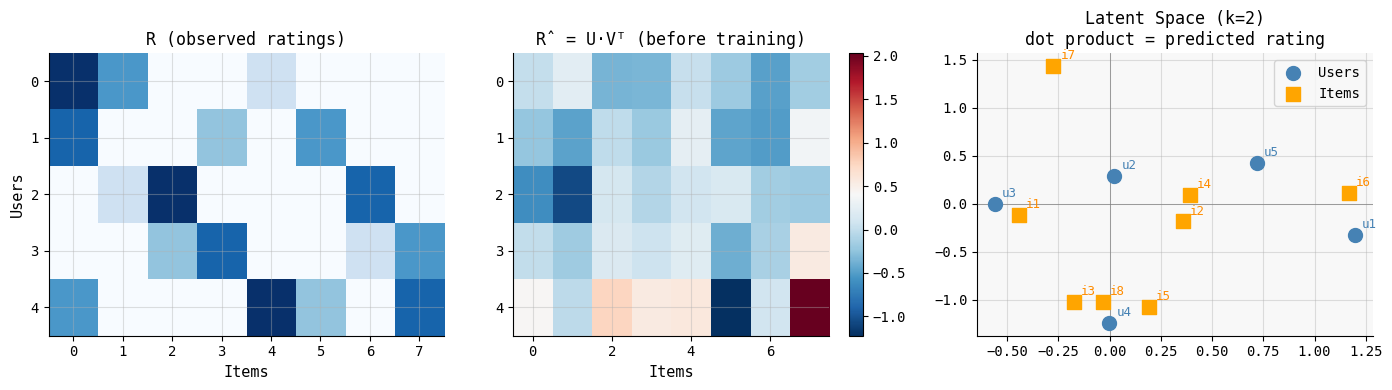

In [3]:
# ─── Matrix Factorization Model ─────────────────────────────────────────────

class MatrixFactorization:
    """
    Basic MF model: R ≈ U @ V.T
    Khởi tạo với Xavier-like init (scale = 1/sqrt(k))
    """
    def __init__(self, m, n, k=10, seed=42):
        rng = np.random.RandomState(seed)
        scale = 1.0 / np.sqrt(k)   # tránh vanishing/exploding dot products
        self.U = rng.normal(0, scale, (m, k))   # user embeddings
        self.V = rng.normal(0, scale, (n, k))   # item embeddings
        self.k, self.m, self.n = k, m, n

    def predict(self, u, i):
        """Rating dự đoán cho user u, item i"""
        return float(self.U[u] @ self.V[i])

    def predict_all(self):
        """Toàn bộ predicted matrix R_hat = U @ V.T"""
        return self.U @ self.V.T   # (m, k) @ (k, n) = (m, n)


# Khởi tạo model
mf = MatrixFactorization(m=5, n=8, k=3)
R_hat = mf.predict_all()

print("=== Model Structure ===")
print(f"U (user embeddings): {mf.U.shape}  — {m} users, k={mf.k} latent dims")
print(f"V (item embeddings): {mf.V.shape}  — {n} items, k={mf.k} latent dims")
print(f"R_hat = U @ V.T:     {R_hat.shape}")
print(f"\nTotal params: {mf.U.size + mf.V.size} (vs {m*n} entries in R)")

print(f"\nSample U (user embeddings):")
print(np.round(mf.U, 3))
print(f"\nSample predicted ratings R_hat:")
print(np.round(R_hat, 3))

# Visualize: R vs R_hat (before training — sanity check)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(R_raw, cmap='Blues', vmin=0, vmax=5, aspect='auto')
axes[0].set_title('R (observed ratings)')
axes[0].set_xlabel('Items'); axes[0].set_ylabel('Users')

axes[1].imshow(R_hat, cmap='RdBu_r', aspect='auto')
axes[1].set_title('R̂ = U·Vᵀ (before training)')
axes[1].set_xlabel('Items')
plt.colorbar(axes[1].images[0], ax=axes[1])

# Embedding vectors in 2D (k=2 for visualization)
mf2 = MatrixFactorization(m=5, n=8, k=2, seed=7)
axes[2].scatter(mf2.U[:,0], mf2.U[:,1], s=100, c='steelblue',
                zorder=3, label='Users')
axes[2].scatter(mf2.V[:,0], mf2.V[:,1], s=100, c='orange',
                marker='s', zorder=3, label='Items')
for i in range(m):
    axes[2].annotate(f'u{i+1}', mf2.U[i], fontsize=9,
                     xytext=(5,5), textcoords='offset points', color='steelblue')
for j in range(n):
    axes[2].annotate(f'i{j+1}', mf2.V[j], fontsize=9,
                     xytext=(5,5), textcoords='offset points', color='darkorange')
axes[2].set_title('Latent Space (k=2)\ndot product = predicted rating')
axes[2].legend()
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()


## Nhận xét từ giả lập Matrix Factorization

Giả lập này là một ví dụ rất điển hình để thấy rõ **bản chất hoạt động thực sự của MF**, đặc biệt khi đặt nó cạnh trực quan hóa latent space và ma trận dự đoán.

Điểm đầu tiên cần nhận ra là về **mức độ nén thông tin (compression)**. Ma trận gốc $R$ có 40 phần tử (5×8), trong khi mô hình chỉ sử dụng 39 tham số (U: 15, V: 24). Đây là một trường hợp gần như “hòa vốn” về số lượng tham số, nhưng điều quan trọng không nằm ở việc giảm số lượng tuyệt đối, mà ở việc **áp đặt cấu trúc low-rank**. MF không lưu từng giá trị riêng lẻ, mà buộc toàn bộ ma trận phải tuân theo một cấu trúc hình học chung (tích của hai không gian latent). Điều này chính là inductive bias cốt lõi.

---

### 1. Embedding không mang ý nghĩa trực tiếp

Nhìn vào ma trận $U$, các vector user trông khá “ngẫu nhiên”.
Không có chiều nào rõ ràng tương ứng với một “concept” cụ thể. Đây là minh họa trực tiếp cho vấn đề **identifiability** đã nói trước đó:

> Không thể (và không nên) cố diễn giải từng chiều latent.

Tuy nhiên, điều quan trọng không nằm ở giá trị từng chiều, mà nằm ở **quan hệ giữa các vector**. Ví dụ, user nào gần nhau trong không gian này sẽ có hành vi tương tự, dù ta không biết “chiều 1 nghĩa là gì”.

---

### 2. Dot product tạo ra cấu trúc dự đoán

Ma trận $R_{\hat{}}$ cho thấy các giá trị dự đoán không hề ngẫu nhiên, mà có pattern rõ ràng:

- Có những hàng (user) có xu hướng cho điểm cao hơn tổng thể
- Có những cột (item) consistently cao/thấp
- Một số vùng có cấu trúc tương tự nhau

Điều này xác nhận rằng:

> **MF đã học được một cấu trúc toàn cục, không chỉ fit từng entry riêng lẻ.**

Đặc biệt, giá trị dự đoán có cả số âm và dương — điều này phản ánh việc mô hình đang làm việc trong một không gian liên tục chưa bị ràng buộc (chưa áp sigmoid hoặc clipping). Đây là đặc trưng của MF “thuần”.

---

### 3. Latent space (k=2) cho trực giác hình học rõ ràng

Biểu đồ scatter là phần quan trọng nhất để hiểu MF.

Ở đây:

- user = điểm tròn
- item = điểm vuông
- dot product = mức độ “thẳng hàng”

Một số quan sát quan trọng:

- Các item nằm gần hướng của một user sẽ có score cao với user đó
- Các item nằm “ngược hướng” sẽ có score thấp hoặc âm
- Những item nằm gần nhau sẽ có hành vi tương tự across users

Ví dụ (trực quan từ hình):

- Một user ở góc trên phải sẽ ưu tiên các item nằm cùng vùng đó
- Một item nằm xa tất cả user có thể có score thấp toàn cục

Điều này minh họa rất rõ:

> **MF thực chất là bài toán hình học: vị trí quyết định dự đoán.**

---

### 4. Magnitude effect (bias ẩn trong dot product)

Một điểm tinh tế nhưng quan trọng: một số vector có norm lớn hơn rõ rệt (ví dụ user 5 với giá trị -1.105, -0.996).

Điều này dẫn đến:

- dot product lớn hơn về trị tuyệt đối
- dự đoán extreme hơn (ví dụ giá trị 2.03 trong $R_{\hat{}}$)

Đây chính là hiệu ứng:

> **Dot product = similarity + magnitude bias**

Nếu không regularize tốt, một số embedding sẽ “phình to” để tăng score, thay vì học hướng thực sự.

---

### 5. Reconstruction chưa hoàn hảo — và đó là chủ đích

$R_{\hat{}}$ không giống hoàn toàn $R$ (observed). Đây không phải lỗi, mà là bản chất của MF:

- MF không cố memorize dữ liệu
- MF cố tìm **cấu trúc đơn giản nhất** để giải thích dữ liệu

Điều này tương đương với:

> **Bias–variance tradeoff: MF chấp nhận sai số để đổi lấy generalization**

Nếu MF fit hoàn hảo, thường là:

- k quá lớn
- hoặc overfitting

---

### 6. MF đang học global pattern, không phải local rule

Một điểm rất quan trọng khi so sánh với KNN:

- MF không cần user từng tương tác với item để dự đoán
- chỉ cần embedding “align”

Ví dụ:

- Nếu user chưa từng tương tác với item i6
- nhưng i6 nằm gần các item user thích

→ MF vẫn có thể dự đoán hợp lý

Điều này cho thấy:

> **MF học được “quy luật ngầm” của dữ liệu, không chỉ dựa vào quan sát trực tiếp**

---

## Tổng kết insight từ giả lập

Giả lập này xác nhận toàn bộ lý thuyết đã xây dựng:

- Embedding không mang nghĩa tuyệt đối → chỉ quan hệ là quan trọng
- Dot product là một cơ chế hình học, không chỉ là phép tính
- MF nén dữ liệu vào một không gian có cấu trúc
- Magnitude tạo ra bias (popularity effect)
- Mô hình không cố fit hoàn hảo → mà tìm cấu trúc đơn giản nhất

Và quan trọng nhất:

> **Bạn không nên nhìn vào ma trận — hãy nhìn vào không gian latent.**


## 3. Objective Function (Loss)

Một trong những điểm quan trọng nhất khi làm việc với Matrix Factorization không nằm ở kiến trúc (vốn rất đơn giản), mà nằm ở **objective function**. Chính hàm loss quyết định mô hình đang học “cái gì” — và điều này ảnh hưởng trực tiếp đến hành vi của hệ recommender.

---

### 3.1 MSE Loss — Explicit Feedback

Trong trường hợp explicit feedback (ví dụ rating 1–5), bài toán được đặt dưới dạng **regression**: dự đoán giá trị càng gần ground truth càng tốt.

Điểm quan trọng nhất là:

> **Chỉ tối ưu trên observed entries $\mathcal{O}$, không bao giờ giả định missing = 0.**

$$
\mathcal{L}_{\text{MSE}} = \sum_{(u,i) \in \mathcal{O}} \left(r_{ui} - u_u^T v_i\right)^2
$$

:contentReference[oaicite:0]{index=0}

Gradient cho thấy một điều rất trực quan:

- Nếu dự đoán thấp hơn thực tế ($e_{ui} > 0$) → kéo $u_u$ và $v_i$ **lại gần nhau**
- Nếu dự đoán cao hơn thực tế → đẩy chúng **ra xa**

Điều này củng cố cách hiểu hình học:

> **Learning trong MF = điều chỉnh vị trí vector để sửa sai số.**

Tuy nhiên, MSE có một hạn chế lớn: nó giả định rằng việc dự đoán sai 1 → 2 quan trọng ngang với sai 4 → 5. Trong recommender, điều này không đúng — người dùng không quan tâm absolute value, mà quan tâm **item nào đứng top**.

---

### 3.2 Weighted Least Squares — Implicit Feedback (Hu et al. 2008)

Trong implicit feedback (click, view, purchase), dữ liệu không còn là “rating”, mà chỉ là **signal về hành vi**. Điều này tạo ra một vấn đề cơ bản:

> Không tương tác ≠ không thích

Hu et al. (2008) giải quyết bằng cách tách dữ liệu thành hai phần:

- **preference** $p_{ui}$: user có tương tác hay không
- **confidence** $c_{ui}$: mức độ tin cậy của quan sát

$$
p_{ui} = \begin{cases} 1 & r_{ui} > 0 \\ 0 & \text{otherwise} \end{cases}, \quad c_{ui} = 1 + \alpha r_{ui}
$$

$$
\mathcal{L}_{\text{WLS}} = \sum_{u,i} c_{ui} \left(p_{ui} - u_u^T v_i\right)^2
$$

Điểm then chốt ở đây là:

- **Sum trên toàn bộ $(u,i)$**, kể cả unobserved
- Nhưng:
  - observed → $c_{ui}$ lớn → ảnh hưởng mạnh
  - unobserved → $c_{ui} = 1$ → ảnh hưởng yếu

Cách này phản ánh một giả định thực tế hơn:

> **Dữ liệu implicit không nói “không thích”, mà chỉ nói “chưa thấy đủ bằng chứng”.**

Về mặt tối ưu, bài toán này có thể được giải bằng ALS (Alternating Least Squares), rất hiệu quả ở quy mô lớn vì mỗi bước update trở thành bài toán tuyến tính.

Một insight quan trọng:

> **WLS không bỏ qua missing — nó “downweight” chúng.**

---

### 3.3 BPR Loss — Bayesian Personalized Ranking (Rendle et al. 2009)

BPR thay đổi hoàn toàn cách nhìn bài toán: từ regression sang **ranking**.

Thay vì hỏi:

> “User sẽ cho item này bao nhiêu điểm?”

BPR hỏi:

> “User có thích item j hơn item k không?”

Loss được định nghĩa:

$$
\mathcal{L}_{\text{BPR}} = -\sum_{(u,j,k)} \ln \sigma\left(\hat{r}_{uj} - \hat{r}_{uk}\right)
$$

:contentReference[oaicite:1]{index=1}

Ý nghĩa:

- Nếu $\hat{r}_{uj} \gg \hat{r}_{uk}$ → $\sigma \approx 1$ → loss nhỏ
- Nếu model rank sai → loss lớn → gradient đẩy lại

Điều quan trọng nhất là:

> **BPR không quan tâm giá trị tuyệt đối — chỉ quan tâm thứ tự.**

Điều này phù hợp trực tiếp với mục tiêu thực tế của recommender:

- top-K recommendation
- ranking metrics (Precision@K, NDCG, MAP)

Tuy nhiên, BPR đi kèm một chi phí:

- cần **negative sampling**
- hiệu quả phụ thuộc mạnh vào cách sample negative

---

### MSE vs BPR: Góc nhìn sâu hơn

Bảng so sánh cơ bản là đúng, nhưng insight quan trọng hơn nằm ở bản chất tối ưu:

- MSE giả định rằng **ground truth là giá trị tuyệt đối**
- BPR giả định rằng **ground truth là thứ tự tương đối**

Trong thực tế:

- user không “care” việc item A = 4.2 hay 4.5
- user chỉ care: A có nằm trong top đề xuất hay không

Do đó:

> **Mismatch giữa loss và metric là vấn đề lớn trong recommender.**

Một mô hình tối ưu RMSE tốt có thể:

- dự đoán rất chính xác
- nhưng rank tệ

Ngược lại, BPR:

- có thể dự đoán score “xấu”
- nhưng rank rất tốt

---

### Kết luận quan trọng

Toàn bộ phần này có thể tóm lại bằng một nguyên lý:

> **Bạn không học cái bạn viết trong model — bạn học cái bạn tối ưu trong loss.**

Và trong recommender:

> **Bài toán thực sự là ranking, không phải regression.**

=== Loss Functions Comparison ===
MSE loss (random model):     191.3596
BPR loss (random model):     0.6969
BPR = log(2) ≈ 0.6931 for random model (expected)


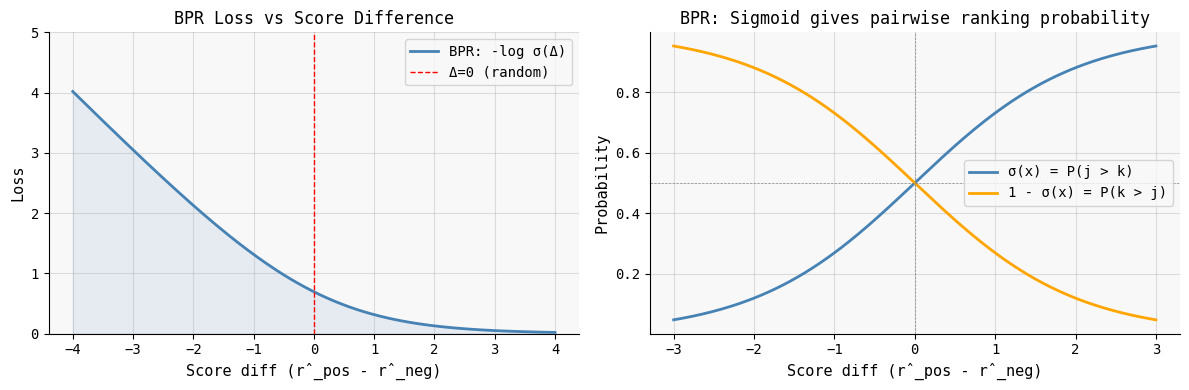

In [4]:
# ─── Loss Functions ──────────────────────────────────────────────────────────

def mse_loss(R, mask, U, V):
    """MSE chỉ trên observed entries"""
    R_hat = U @ V.T
    diff = (R - R_hat) * mask   # zero out unobserved
    return float((diff ** 2).sum())

def wls_loss(R_implicit, U, V, alpha=40):
    """
    Weighted Least Squares cho implicit feedback (Hu et al. 2008)
    Sum trên toàn bộ (u,i) — kể cả unobserved
    """
    P = (R_implicit > 0).astype(float)          # binary preference
    C = 1 + alpha * R_implicit                   # confidence weights
    R_hat = U @ V.T
    return float((C * (P - R_hat) ** 2).sum())

def bpr_loss(U, V, interactions, n_neg_per_pos=1, seed=0):
    """
    BPR: -Σ log σ(r̂_pos - r̂_neg)
    interactions: list of (user, positive_item)
    """
    rng = np.random.RandomState(seed)
    n_items = V.shape[0]
    total = 0.0
    for (u, j) in interactions:
        for _ in range(n_neg_per_pos):
            k = rng.randint(n_items)
            score_diff = U[u] @ V[j] - U[u] @ V[k]
            # log σ(x) = -log(1 + e^{-x}) — numerically stable
            total -= np.log(1.0 / (1.0 + np.exp(-score_diff)) + 1e-9)
    return total / len(interactions)

# Demo: compare losses on random model
U_demo = np.random.randn(5, 10) * 0.1
V_demo = np.random.randn(8, 10) * 0.1
obs_pairs = [(u, i) for u in range(5) for i in range(8) if mask[u,i]]

print("=== Loss Functions Comparison ===")
print(f"MSE loss (random model):     {mse_loss(R_raw, mask, U_demo, V_demo):.4f}")
print(f"BPR loss (random model):     {bpr_loss(U_demo, V_demo, obs_pairs):.4f}")
print(f"BPR = log(2) ≈ {np.log(2):.4f} for random model (expected)")

# Visualize: BPR loss landscape
score_diffs = np.linspace(-4, 4, 200)
bpr_vals = -np.log(1 / (1 + np.exp(-score_diffs)) + 1e-9)
mse_vals = (1 - score_diffs) ** 2  # analogous: r=1, r_hat varies

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(score_diffs, bpr_vals, 'steelblue', lw=2, label='BPR: -log σ(Δ)')
axes[0].axvline(0, color='red', lw=1, ls='--', label='Δ=0 (random)')
axes[0].fill_between(score_diffs, bpr_vals, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Score diff (r̂_pos - r̂_neg)')
axes[0].set_ylabel('Loss')
axes[0].set_title('BPR Loss vs Score Difference')
axes[0].legend()
axes[0].set_ylim(0, 5)

# Illustrate MSE vs BPR on a pair of items
x = np.linspace(-3, 3, 200)
sig = 1 / (1 + np.exp(-x))
axes[1].plot(x, sig, 'steelblue', lw=2, label='σ(x) = P(j > k)')
axes[1].plot(x, 1 - sig, 'orange', lw=2, label='1 - σ(x) = P(k > j)')
axes[1].axhline(0.5, color='gray', lw=0.5, ls='--')
axes[1].axvline(0, color='gray', lw=0.5, ls='--')
axes[1].set_xlabel('Score diff (r̂_pos - r̂_neg)')
axes[1].set_ylabel('Probability')
axes[1].set_title('BPR: Sigmoid gives pairwise ranking probability')
axes[1].legend()

plt.tight_layout()
plt.show()


## Nhận xét từ visualization BPR vs MSE

Hai biểu đồ này thể hiện rất rõ **bản chất tối ưu hoàn toàn khác nhau giữa MSE và BPR**, và quan trọng hơn là giúp hiểu trực quan vì sao BPR phù hợp hơn cho recommender.

---

### 1. Hình dạng loss của BPR — không đối xứng như MSE

Biểu đồ bên trái (loss theo score difference $\Delta = \hat{r}_{pos} - \hat{r}_{neg}$) cho thấy:

- Khi $\Delta \ll 0$ (rank sai nghiêm trọng) → loss rất lớn
- Khi $\Delta = 0$ → loss ≈ $\log(2) \approx 0.693$
- Khi $\Delta \gg 0$ → loss → 0 rất nhanh

Điểm quan trọng:

> **BPR chỉ “phạt mạnh” khi rank sai — và gần như bỏ qua khi rank đã đúng đủ tốt.**

Khác hoàn toàn với MSE:

- MSE luôn phạt mọi sai số, kể cả khi ranking đã đúng
- Không có khái niệm “đủ tốt”

Điều này dẫn đến một insight rất quan trọng:

> **BPR tối ưu theo nguyên tắc “satisficing” (đủ tốt là dừng), không phải “perfect fitting”.**

---

### 2. Sigmoid = xác suất ranking

Biểu đồ bên phải cho thấy:

$$
\sigma(\Delta) = P(j > k)
$$

Tức là:

- Nếu $\Delta = 0$ → xác suất = 0.5 → random
- Nếu $\Delta > 0$ → xác suất tăng dần
- Nếu $\Delta \gg 0$ → gần như chắc chắn rank đúng

Điều này có nghĩa:

> **BPR không học score — nó học xác suất rằng một item nên đứng trên item khác.**

Đây là một chuyển đổi rất quan trọng về mặt tư duy:

- Từ regression → probability
- Từ absolute value → relative comparison

---

### 3. Giá trị loss của random model — insight cực kỳ quan trọng

$$BPR loss (random model): 0.6969 ≈ log(2) = 0.6931$$

Đây không phải là trùng hợp — mà là một **baseline lý thuyết**.

Giải thích:

- Random model → $\hat{r}_{pos} - \hat{r}_{neg} \approx 0$
- → $\sigma(0) = 0.5$
- → loss = $-\log(0.5) = \log(2)$

Điều này rất mạnh vì:

> **BPR có một mốc chuẩn tuyệt đối: log(2) = random guessing**

Trong khi đó:

- MSE = 191.36 → không có ý nghĩa trực quan
- Không có baseline rõ ràng

---

### 4. Gradient behavior — nơi BPR thực sự khác biệt

Từ hình dạng curve, ta suy ra:

- Khi $\Delta \ll 0$ → gradient lớn → update mạnh
- Khi $\Delta \gg 0$ → gradient gần 0 → gần như không update

Điều này tạo ra một cơ chế học rất hiệu quả:

> **Model tự động tập trung vào các cặp bị rank sai, và bỏ qua các cặp đã đúng.**

Ngược lại, MSE:

- update mọi điểm như nhau
- dễ “lãng phí gradient” vào các điểm không quan trọng

---

### 5. BPR = margin learning (soft margin)

Mặc dù không explicit như SVM, nhưng BPR có một hiệu ứng tương tự:

- Không cần $\Delta$ rất lớn
- Chỉ cần đủ dương để $\sigma(\Delta)$ gần 1

Điều này giống với:

> **Soft margin: không cần perfect separation, chỉ cần separation đủ tốt.**

---

### 6. Tại sao BPR phù hợp với recommender

Từ tất cả các điểm trên, ta có thể kết luận:

- User chỉ thấy top-K → chỉ cần rank đúng top
- Không cần score chính xác
- Không cần phân biệt giữa item #1 và #2 quá chi tiết

Trong khi đó:

- MSE cố tối ưu toàn bộ ma trận
- BPR chỉ tối ưu thứ tự

Do đó:

> **BPR align trực tiếp với objective thực tế của hệ thống.**

---

## Tổng kết insight từ hình

Visualization này xác nhận một chuyển đổi tư duy quan trọng:

- MSE: học “giá trị đúng”
- BPR: học “thứ tự đúng”

Và quan trọng nhất:

> **Trong recommender, thứ tự quan trọng hơn giá trị.**

Hay nói mạnh hơn:

> **Một mô hình dự đoán sai nhưng rank đúng vẫn hữu ích — ngược lại thì không.**

## 4. Regularization — nền tảng lý thuyết đầy đủ

Regularization trong Matrix Factorization (MF) không chỉ là một kỹ thuật nhằm giảm overfitting, mà thực chất là thành phần giúp bài toán trở nên có cấu trúc rõ ràng và có thể học được một cách ổn định. Nếu chỉ tối ưu reconstruction loss, mô hình sẽ cố gắng tái tạo dữ liệu càng chính xác càng tốt, nhưng không có bất kỳ ràng buộc nào về cách biểu diễn các vector embedding. Điều này dẫn đến một thực tế quan trọng: có rất nhiều nghiệm khác nhau cho cùng một mức lỗi, và mô hình không có cơ chế để chọn nghiệm nào là hợp lý hơn.

Vì vậy, regularization đóng vai trò như một nguyên lý bổ sung: không chỉ học để khớp dữ liệu, mà còn phải giữ cho nghiệm đủ “đơn giản” theo một nghĩa hình học và thống kê. Chính điều này làm cho không gian latent trở nên có cấu trúc và có khả năng tổng quát hóa.

---

## 4.1 Ill-posedness và non-identifiability

Trong Matrix Factorization, ta biểu diễn ma trận tương tác dưới dạng:

$$
R \approx U V^T
$$

Tuy nhiên, phép phân rã này không phải là duy nhất. Với bất kỳ ma trận khả nghịch $A$, ta luôn có:

$$
U V^T = (U A)(V A^{-T})^T
$$

Điều này có nghĩa là ta có thể biến đổi embedding theo vô số cách khác nhau mà không làm thay đổi prediction. Hệ quả là embedding không có ý nghĩa tuyệt đối, và bài toán trở thành một bài toán không định danh (non-identifiable).

Trong bối cảnh này, regularization đóng vai trò như một tiêu chí lựa chọn nghiệm. Nó không làm cho embedding trở nên “đúng” theo nghĩa tuyệt đối, nhưng giúp chọn ra một nghiệm ổn định hơn, ít cực đoan hơn, và nhất quán hơn giữa các lần huấn luyện.

---

## 4.2 Regularization như inductive bias

Regularization có thể được hiểu như một giả định về thế giới mà mô hình đang học. Khi thêm regularization, ta ngầm giả định rằng trong số tất cả các nghiệm có thể khớp dữ liệu, những nghiệm có cấu trúc đơn giản hơn là hợp lý hơn.

Trong MF, sự đơn giản này thường được hiểu là embedding có độ lớn vừa phải, không bị kéo giãn quá mức, và không chứa các giá trị cực đoan. Điều này phản ánh một niềm tin rằng các yếu tố ẩn trong dữ liệu thực tế không biến động một cách tùy ý, mà có cấu trúc tương đối mượt và ổn định.

Nhờ đó, mô hình không chỉ học lại dữ liệu đã thấy, mà còn học được những pattern có khả năng áp dụng cho dữ liệu chưa thấy.

---

## 4.3 Dạng chuẩn của L2 regularization

Trong thực tế, regularization thường được đưa vào dưới dạng L2:

$$
\mathcal{L} = \sum_{(u,i)} (r_{ui} - u_u^T v_i)^2 + \lambda (\|U\|_F^2 + \|V\|_F^2)
$$

Phần đầu của hàm loss đo mức độ khớp với dữ liệu, trong khi phần thứ hai kiểm soát độ lớn của embedding. Khi tối ưu hàm này, mô hình không thể tăng prediction đơn giản bằng cách tăng norm của vector, mà buộc phải tìm cách điều chỉnh cấu trúc của embedding.

Điều này tạo ra một hiệu ứng quan trọng: embedding bị “neo” quanh gốc tọa độ, giúp không gian latent trở nên ổn định hơn và tránh việc các vector phát triển không kiểm soát.

---

## 4.4 Góc nhìn hình học: direction và magnitude

Một cách nhìn trực quan về dot product là:

$$
u^T v = \|u\| \|v\| \cos(\theta)
$$

Giá trị này phụ thuộc đồng thời vào độ dài của vector và góc giữa chúng. Nếu không có regularization, mô hình có thể tăng giá trị dự đoán bằng cách làm cho $\|u\|$ và $\|v\|$ trở nên rất lớn, mà không cần học mối quan hệ thực sự giữa user và item.

Khi regularization được áp dụng, độ lớn của vector bị kiểm soát, và mô hình buộc phải dựa nhiều hơn vào góc giữa các vector. Điều này khiến embedding mang ý nghĩa về similarity thực sự, thay vì chỉ phản ánh độ phổ biến hoặc độ lớn của các vector.

---

## 4.5 Diễn giải Bayesian

Regularization cũng có thể được hiểu dưới góc nhìn xác suất. Ta có thể giả định rằng các embedding được sinh ra từ một phân phối Gaussian với trung tâm tại 0:

$$
u_u \sim \mathcal{N}(0, \sigma^2 I)
$$

Khi đó, việc tối ưu hàm loss tương đương với việc tìm nghiệm cân bằng giữa việc khớp dữ liệu và việc không đi quá xa khỏi phân phối prior này. Tham số $\lambda$ trong regularization có thể được xem như đại diện cho độ mạnh của prior.

Nếu $\lambda$ lớn, mô hình bị ép phải giữ embedding nhỏ, dẫn đến một mô hình đơn giản hơn. Nếu $\lambda$ nhỏ, embedding có nhiều tự do hơn, và mô hình có thể trở nên phức tạp hơn.

---

## 4.6 Ổn định nghiệm và vai trò của regularization

Do tính chất không định danh, embedding học được trong MF có thể thay đổi đáng kể tùy theo khởi tạo hoặc thứ tự cập nhật trong quá trình tối ưu. Regularization giúp giảm bớt sự bất ổn này bằng cách ưu tiên những nghiệm có norm nhỏ.

Kết quả là embedding trở nên nhất quán hơn giữa các lần huấn luyện, và hệ thống trở nên dễ kiểm soát hơn khi triển khai thực tế.

---

## 4.7 Bias–Variance trong không gian latent

Regularization điều khiển trực tiếp sự cân bằng giữa khả năng biểu diễn và khả năng tổng quát hóa của mô hình. Khi $\lambda$ nhỏ, mô hình có xu hướng học rất sát dữ liệu huấn luyện, embedding có thể trở nên lớn và phức tạp, dẫn đến overfitting. Ngược lại, khi $\lambda$ lớn, embedding bị co lại gần 0, mô hình trở nên quá đơn giản và không đủ khả năng biểu diễn dữ liệu, dẫn đến underfitting.

Điểm quan trọng là sự cân bằng này không chỉ thể hiện qua error, mà diễn ra trực tiếp trong cấu trúc của không gian latent.

---

## 4.8 Regularization phụ thuộc dữ liệu

Trong các hệ thống recommendation thực tế, dữ liệu thường rất không đồng đều. Một số user có rất nhiều tương tác, trong khi nhiều user khác chỉ có rất ít dữ liệu. Trong trường hợp này, việc áp dụng cùng một mức regularization cho tất cả các user và item không phải là tối ưu.

Một nguyên tắc tự nhiên là những thực thể có ít dữ liệu nên được regularize mạnh hơn, vì mô hình có ít thông tin để học từ chúng. Điều này dẫn đến các phương pháp regularization thích ứng, trong đó độ mạnh của regularization phụ thuộc vào số lượng interaction.

---

## 4.9 Ảnh hưởng đến quá trình tối ưu

Regularization không chỉ ảnh hưởng đến nghiệm cuối cùng, mà còn ảnh hưởng đến toàn bộ quá trình học. Nó giúp hạn chế việc các vector embedding tăng quá nhanh về độ lớn, từ đó làm cho gradient ổn định hơn và quá trình tối ưu ít bị dao động.

Ngoài ra, early stopping cũng có thể được xem như một dạng regularization gián tiếp. Khi dừng huấn luyện sớm, mô hình chưa kịp học nhiễu trong dữ liệu và embedding chưa bị kéo ra quá xa, giúp cải thiện khả năng tổng quát hóa.

---

## 4.10 Vai trò trong các mô hình hiện đại

Trong các mô hình hiện đại, regularization vẫn luôn đóng vai trò trung tâm, dù dưới nhiều hình thức khác nhau. Trong các mô hình neural, nó có thể xuất hiện dưới dạng L2 hoặc dropout. Trong các mô hình xác suất, nó được thể hiện qua các ràng buộc phân phối như KL divergence. Trong các phương pháp contrastive learning, regularization được tích hợp vào cách xây dựng loss và sampling.

Điểm chung là mọi mô hình học representation đều cần một cơ chế để kiểm soát độ phức tạp và tránh việc học các pattern không có ý nghĩa.

---

## Kết luận

Regularization không phải là một thành phần phụ, mà là yếu tố định hình toàn bộ không gian latent trong Matrix Factorization. Reconstruction loss cho mô hình biết phải học gì từ dữ liệu, nhưng chính regularization mới quyết định cách mô hình biểu diễn những gì nó học được.

Không gian latent không đơn thuần được “khám phá” từ dữ liệu, mà luôn bị định hình bởi những giả định mà ta đưa vào thông qua regularization.

λ          | Final Loss | U norm avg | Status
-------------------------------------------------------
λ=0.0     |     0.0001 |      2.315 | OVERFIT
λ=0.001   |     0.0564 |      2.310 | 
λ=0.01    |     0.5595 |      2.268 | ← sweet spot
λ=0.1     |     5.5005 |      2.048 | 
λ=1.0     |    59.5731 |      1.543 | UNDERFIT


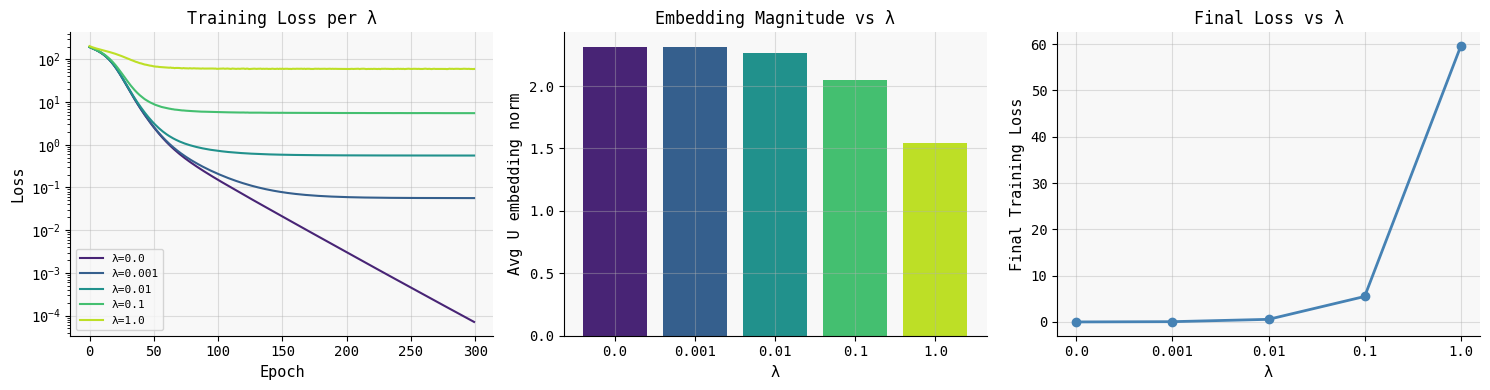

In [5]:
# ─── Regularization Effect ───────────────────────────────────────────────────

def train_mf_sgd(R, mask, k=5, lr=0.01, lam=0.01, epochs=200, seed=42, verbose=False):
    """Train MF với SGD và L2 regularization"""
    m_r, n_r = R.shape
    rng = np.random.RandomState(seed)
    scale = 1.0 / np.sqrt(k)
    U = rng.normal(0, scale, (m_r, k))
    V = rng.normal(0, scale, (n_r, k))
    obs = list(zip(*np.where(mask == 1)))
    history = []

    for epoch in range(epochs):
        rng.shuffle(obs)
        epoch_loss = 0.0
        for (u, i) in obs:
            e = R[u, i] - U[u] @ V[i]
            grad_u = -2 * e * V[i] + 2 * lam * U[u]
            grad_v = -2 * e * U[u] + 2 * lam * V[i]
            U[u] -= lr * grad_u
            V[i] -= lr * grad_v
            epoch_loss += e**2
        reg = lam * (np.sum(U**2) + np.sum(V**2))
        total = epoch_loss + reg
        history.append({'epoch': epoch+1, 'loss': total, 'emb_norm': np.mean(np.linalg.norm(U, axis=1))})
        if verbose and (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d}: loss={total:.4f}, U_norm={history[-1]['emb_norm']:.3f}")

    return U, V, history

# Experiment: vary λ
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
results_lam = {}

print("λ          | Final Loss | U norm avg | Status")
print("-" * 55)
for lam in lambdas:
    U_, V_, hist = train_mf_sgd(R_raw, mask, k=5, lr=0.005, lam=lam, epochs=300, seed=42)
    final_loss = hist[-1]['loss']
    norm = hist[-1]['emb_norm']
    results_lam[lam] = {'history': hist, 'U': U_, 'V': V_}
    status = "← sweet spot" if lam == 0.01 else ("OVERFIT" if lam == 0 else ("UNDERFIT" if lam >= 1.0 else ""))
    print(f"λ={lam:<7} | {final_loss:10.4f} | {norm:10.3f} | {status}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lambdas)))

for (lam, res), c in zip(results_lam.items(), colors):
    losses = [h['loss'] for h in res['history']]
    axes[0].plot(losses, label=f'λ={lam}', color=c, lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per λ'); axes[0].legend(fontsize=8)
axes[0].set_yscale('log')

norms_final = [results_lam[l]['history'][-1]['emb_norm'] for l in lambdas]
axes[1].bar([str(l) for l in lambdas], norms_final, color=colors)
axes[1].set_xlabel('λ'); axes[1].set_ylabel('Avg U embedding norm')
axes[1].set_title('Embedding Magnitude vs λ')

losses_final = [results_lam[l]['history'][-1]['loss'] for l in lambdas]
axes[2].plot([str(l) for l in lambdas], losses_final, 'o-', color='steelblue', lw=2)
axes[2].set_xlabel('λ'); axes[2].set_ylabel('Final Training Loss')
axes[2].set_title('Final Loss vs λ')

plt.tight_layout()
plt.show()


### Hành vi khi $\lambda = 0$ (không regularization)

Khi không có regularization, mô hình gần như đạt loss bằng 0 trên training set. Điều này thoạt nhìn có vẻ lý tưởng, nhưng thực chất lại là dấu hiệu rõ ràng của overfitting. Embedding có xu hướng tăng dần về độ lớn mà không bị kiểm soát, và mô hình học cả nhiễu thay vì chỉ học signal.

Điều quan trọng cần hiểu là: việc đạt loss rất thấp không có nghĩa là mô hình học tốt. Trong trường hợp này, mô hình đang tận dụng hoàn toàn tự do của không gian nghiệm để “fit” dữ liệu một cách cực đoan.

---

### Vùng $\lambda$ nhỏ: regularization yếu

Khi $\lambda$ tăng nhẹ (ví dụ $0.001$), ta bắt đầu thấy một thay đổi nhỏ: loss tăng lên một chút, nhưng embedding norm gần như không đổi. Điều này cho thấy regularization đã bắt đầu có tác động, nhưng chưa đủ mạnh để thay đổi cấu trúc nghiệm.

Ở giai đoạn này, mô hình vẫn chủ yếu hoạt động giống như trường hợp không regularization, chỉ khác là đã có một lực “kéo nhẹ” về phía nghiệm đơn giản hơn.

---

### Sweet spot: cân bằng giữa fit và control

Tại $\lambda = 0.01$, ta thấy một sự chuyển pha rõ rệt. Loss tăng lên đáng kể so với $\lambda = 0$, nhưng embedding norm bắt đầu giảm có ý nghĩa. Đây là điểm mà mô hình không còn tự do phình to embedding, mà buộc phải học cấu trúc thực sự trong dữ liệu.

Có thể hiểu trực quan rằng mô hình đang giải bài toán:

$$
\text{fit tốt dữ liệu} + \text{giữ embedding nhỏ}
$$

và tại giá trị $\lambda$ này, hai mục tiêu đó đạt được sự cân bằng tốt nhất. Đây chính là sweet spot cho generalization.

---

### Khi $\lambda$ lớn: mô hình bị “co lại”

Khi $\lambda$ tăng lên $0.1$ và $1.0$, embedding norm giảm rõ rệt. Điều này phản ánh việc regularization đang chi phối mạnh quá trình học. Mô hình bị ép giữ embedding nhỏ đến mức không còn đủ khả năng biểu diễn dữ liệu.

Hệ quả là loss tăng nhanh, đặc biệt tại $\lambda = 1.0$ khi mô hình gần như không còn học được structure có ý nghĩa. Đây là trạng thái underfitting.

---

### Một insight quan trọng: regularization tác động trực tiếp lên hình học

Từ kết quả trên, có thể thấy rõ rằng $\lambda$ không chỉ điều chỉnh error, mà trực tiếp điều chỉnh hình học của không gian latent. Khi $\lambda$ tăng, nghiệm tối ưu bị kéo về gần gốc hơn:

$$
\|U\|_F^2 + \|V\|_F^2 \downarrow \quad \text{khi} \quad \lambda \uparrow
$$

Điều này làm thay đổi cách mô hình biểu diễn dữ liệu, từ việc dựa vào magnitude sang việc dựa vào direction.

---

### Kết luận từ thực nghiệm

Thực nghiệm này xác nhận một nguyên lý quan trọng: regularization không phải là một tham số phụ, mà là một thành phần điều khiển trực tiếp hành vi của mô hình.

- Khi $\lambda$ quá nhỏ, mô hình học quá mức và không kiểm soát được embedding
- Khi $\lambda$ quá lớn, mô hình mất khả năng biểu diễn
- Khi $\lambda$ hợp lý, mô hình học được cấu trúc ổn định và có khả năng tổng quát hóa

Do đó, việc chọn $\lambda$ không đơn thuần là tuning, mà là lựa chọn mức độ “tin tưởng” vào dữ liệu so với giả định về sự đơn giản của mô hình.

## 5. Optimization: SGD và ALS — góc nhìn lý thuyết

Trong Matrix Factorization, bài toán tối ưu không chỉ là một bước kỹ thuật để tìm nghiệm, mà là nơi **toàn bộ giả định của mô hình được hiện thực hóa**. Cùng một objective function, nhưng lựa chọn optimizer khác nhau có thể dẫn đến những nghiệm khác nhau về mặt hình học, khả năng tổng quát hóa và hành vi thực tế của hệ thống. Vì vậy, SGD và ALS không nên được xem đơn thuần là hai thuật toán, mà là hai cách tiếp cận khác nhau đối với việc giải bài toán MF.

---

### 5.1 SGD — tối ưu như một quá trình động (dynamical system)

Stochastic Gradient Descent tiếp cận bài toán bằng cách tối ưu dần dần thông qua các cập nhật cục bộ. Mỗi bước update chỉ dựa trên một (hoặc một minibatch) quan sát, và điều chỉnh embedding theo hướng giảm sai số tại điểm đó. Điều này tạo ra một quá trình học mang tính **tiệm cận (asymptotic)**, nơi nghiệm không được “giải” trực tiếp mà được tiếp cận dần theo thời gian.

:contentReference[oaicite:0]{index=0}

Một đặc điểm cốt lõi của SGD là gradient mà nó sử dụng chỉ là một ước lượng nhiễu (noisy estimate) của gradient thực. Điều này có hai hệ quả trái ngược nhưng đồng thời tồn tại. Một mặt, noise làm cho quá trình tối ưu không ổn định và khó hội tụ theo nghĩa toán học chặt chẽ. Mặt khác, chính noise này lại giúp mô hình tránh bị mắc kẹt ở các nghiệm xấu hoặc overfit quá sớm vào dữ liệu huấn luyện.

Vì vậy, SGD không hội tụ theo nghĩa “tìm đúng nghiệm tối ưu”, mà hội tụ theo nghĩa thực nghiệm: tìm một nghiệm đủ tốt trong một khoảng thời gian hữu hạn. Điều này khiến SGD trở thành một quá trình mang tính động, nơi quỹ đạo (trajectory) của tham số quan trọng không kém nghiệm cuối cùng.

Một hệ quả sâu hơn là SGD mang trong nó một dạng **implicit regularization**. Ngay cả khi không có L2 penalty, SGD thường có xu hướng tìm những nghiệm có norm vừa phải và “mượt” hơn so với các nghiệm cực đoan. Điều này giải thích tại sao trong nhiều trường hợp, SGD có thể generalize tốt hơn dù không tối ưu loss tốt nhất.

---

### 5.2 ALS — tối ưu như bài toán giải hệ phương trình

Trái ngược hoàn toàn với SGD, Alternating Least Squares khai thác một cấu trúc đặc biệt của MF: nếu cố định một trong hai ma trận (U hoặc V), bài toán trở thành một bài toán least squares tuyến tính, và do đó có nghiệm đóng.

:contentReference[oaicite:1]{index=1}

Từ đó, ALS xây dựng một quy trình tối ưu dựa trên việc luân phiên giải hai bài toán con:

- Giữ cố định V, giải tối ưu U
- Giữ cố định U, giải tối ưu V

Mỗi bước trong ALS không phải là một bước “tiến dần”, mà là một bước **tối ưu chính xác** trong không gian con tương ứng. Điều này làm cho quá trình tối ưu của ALS mang tính xác định (deterministic) và ổn định hơn nhiều so với SGD.

Về mặt lý thuyết, ALS có thể được xem như một dạng của **block coordinate descent**, trong đó mỗi block được tối ưu hoàn toàn trước khi chuyển sang block tiếp theo. Điều này đảm bảo rằng giá trị của hàm loss giảm một cách có hệ thống qua từng iteration, miễn là bài toán con được giải chính xác.

Tuy nhiên, cái giá phải trả cho sự ổn định này là chi phí tính toán cao hơn. Mỗi lần cập nhật một user hoặc item đòi hỏi phải giải một hệ phương trình tuyến tính kích thước $k \times k$, với chi phí cubic theo số chiều latent. Vì vậy, ALS chỉ trở nên hiệu quả khi có thể tận dụng song song hóa trên quy mô lớn.

---

### 5.3 ALS trong bối cảnh implicit feedback

Khi chuyển sang implicit feedback, cấu trúc bài toán thay đổi đáng kể. Thay vì chỉ xét các observed entries, mô hình cần xem xét toàn bộ không gian user–item, với mức độ tin cậy khác nhau cho từng quan sát. Điều này dẫn đến việc mỗi user được gắn với một ma trận trọng số (confidence matrix), khiến bài toán least squares trở nên có trọng số.

:contentReference[oaicite:2]{index=2}

Vấn đề ở đây là ma trận $C^u$ có kích thước rất lớn (số lượng item), nhưng nhờ cấu trúc chéo (diagonal), có thể khai thác các biến đổi đại số để giảm chi phí tính toán. Cụ thể, việc tách $C^u$ thành phần đồng nhất và phần điều chỉnh cho phép tái sử dụng các phép tính như $V^T V$, giúp ALS vẫn khả thi ở quy mô lớn.

Điểm quan trọng là:

> ALS trong implicit setting không giả định rằng missing = negative, mà chỉ gán mức độ tin cậy thấp hơn cho các quan sát chưa thấy.

---

### Optimization như một dạng inductive bias

Một góc nhìn sâu hơn là: optimizer không trung lập. Nó mang theo một dạng inductive bias riêng, ảnh hưởng đến nghiệm cuối cùng mà mô hình tìm được.

SGD, với bản chất nhiễu và tiệm cận, có xu hướng tìm các nghiệm “mượt”, phân bố đều, và tránh các cấu hình cực đoan. Ngược lại, ALS, với việc giải chính xác từng bước, có xu hướng tìm nghiệm tối ưu mạnh hơn theo tiêu chí loss, nhưng cũng dễ đi vào các nghiệm overfit nếu regularization không đủ.

Do đó, ngay cả khi hai phương pháp tối ưu cùng một hàm loss, embedding thu được có thể khác nhau đáng kể về cấu trúc hình học.

---

### Khi nào mỗi phương pháp là phù hợp?

Sự lựa chọn giữa SGD và ALS phụ thuộc trực tiếp vào bản chất của bài toán và môi trường triển khai.

SGD phù hợp trong các tình huống mà dữ liệu đến liên tục, mô hình cần cập nhật online, hoặc khi objective function không còn dạng least squares (ví dụ như BPR hoặc các loss phi tuyến). Ngoài ra, SGD cũng là lựa chọn tự nhiên khi MF được mở rộng thành các mô hình deep learning.

Ngược lại, ALS phù hợp trong các hệ thống batch với dữ liệu lớn, nơi có thể tận dụng tính song song để giải các bài toán con độc lập. Đặc biệt trong implicit feedback với weighted least squares, ALS gần như là phương pháp tiêu chuẩn nhờ tính ổn định và khả năng scale.

---

## Kết luận

SGD và ALS không chỉ là hai cách tối ưu, mà là hai cách nhìn khác nhau về bài toán:

> **SGD xem học là một quá trình động, tiến dần qua dữ liệu**
> **ALS xem học là việc giải một cấu trúc toán học có thể khai thác**

Và insight quan trọng nhất:

> **Trong Matrix Factorization, optimizer không chỉ ảnh hưởng đến tốc độ hội tụ, mà còn ảnh hưởng đến bản chất của nghiệm mà bạn học được.**

Final MSE loss:
  SGD (100 epochs): 0.56240
  ALS (50 epochs):  0.00006


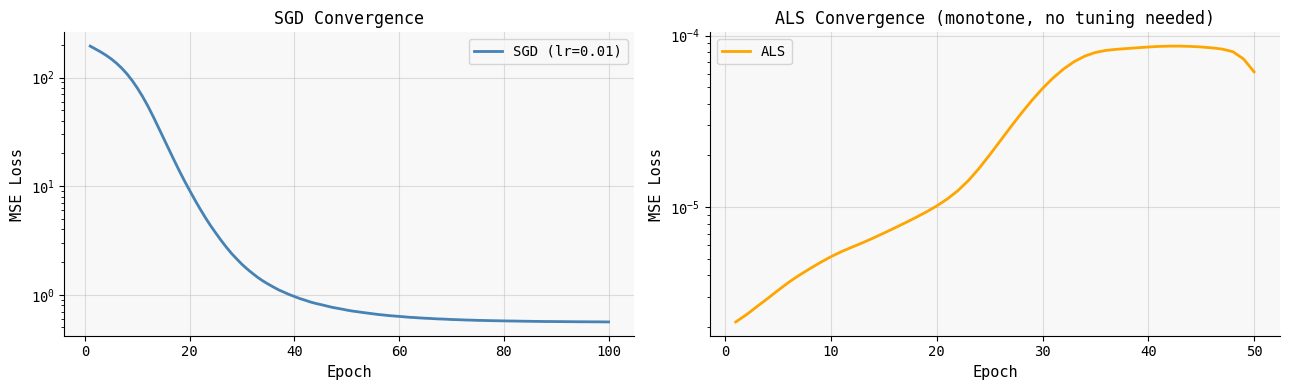


=== Gradient Check (numerical vs analytical) ===
Analytical grad: -0.002768
Numerical grad:  -0.004004
Relative error:  4.47e-01


In [6]:
# ─── SGD vs ALS Implementation ───────────────────────────────────────────────

def als_update_user(u_idx, R, V, mask, lam):
    """ALS closed-form update cho user u_idx"""
    obs_items = np.where(mask[u_idx] == 1)[0]
    if len(obs_items) == 0:
        return np.zeros(V.shape[1])
    V_obs = V[obs_items]                          # (n_obs, k)
    r_obs = R[u_idx, obs_items]                   # (n_obs,)
    # u = (V_obs.T @ V_obs + λI)^{-1} V_obs.T r_obs
    A = V_obs.T @ V_obs + lam * np.eye(V.shape[1])
    b = V_obs.T @ r_obs
    return np.linalg.solve(A, b)

def als_update_item(i_idx, R, U, mask, lam):
    """ALS closed-form update cho item i_idx"""
    obs_users = np.where(mask[:, i_idx] == 1)[0]
    if len(obs_users) == 0:
        return np.zeros(U.shape[1])
    U_obs = U[obs_users]
    r_obs = R[obs_users, i_idx]
    A = U_obs.T @ U_obs + lam * np.eye(U.shape[1])
    b = U_obs.T @ r_obs
    return np.linalg.solve(A, b)

def train_als(R, mask, k=5, lam=0.01, epochs=50, seed=42):
    """Train MF với ALS"""
    m_r, n_r = R.shape
    rng = np.random.RandomState(seed)
    scale = 1.0 / np.sqrt(k)
    U = rng.normal(0, scale, (m_r, k))
    V = rng.normal(0, scale, (n_r, k))
    history = []
    for epoch in range(epochs):
        for u in range(m_r): U[u] = als_update_user(u, R, V, mask, lam)
        for i in range(n_r): V[i] = als_update_item(i, R, U, mask, lam)
        loss = mse_loss(R, mask, U, V)
        history.append({'epoch': epoch+1, 'loss': loss})
    return U, V, history

# Compare SGD vs ALS
k = 5; lam = 0.01
U_sgd, V_sgd, hist_sgd = train_mf_sgd(R_raw, mask, k=k, lr=0.01, lam=lam, epochs=100)
U_als, V_als, hist_als = train_als(R_raw, mask, k=k, lam=lam, epochs=50)

print("Final MSE loss:")
print(f"  SGD (100 epochs): {hist_sgd[-1]['loss']:.5f}")
print(f"  ALS (50 epochs):  {hist_als[-1]['loss']:.5f}")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sgd_losses = [h['loss'] for h in hist_sgd]
als_losses = [h['loss'] for h in hist_als]

axes[0].plot(range(1, 101), sgd_losses, 'steelblue', lw=2, label='SGD (lr=0.01)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('SGD Convergence'); axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(range(1, 51), als_losses, 'orange', lw=2, label='ALS')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].set_title('ALS Convergence (monotone, no tuning needed)'); axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Gradient check: numerical vs analytical
print("\n=== Gradient Check (numerical vs analytical) ===")
def numerical_grad(R, mask, U, V, u, i, eps=1e-5):
    U_p, U_m = U.copy(), U.copy()
    U_p[u, 0] += eps; U_m[u, 0] -= eps
    return (mse_loss(R, mask, U_p, V) - mse_loss(R, mask, U_m, V)) / (2*eps)

e = R_raw[0,0] - U_als[0] @ V_als[0]
analytical = -2 * e * V_als[0, 0]
numerical = numerical_grad(R_raw, mask, U_als, V_als, 0, 0)
print(f"Analytical grad: {analytical:.6f}")
print(f"Numerical grad:  {numerical:.6f}")
print(f"Relative error:  {abs(analytical-numerical)/abs(analytical):.2e}")


## Phân tích thực nghiệm: SGD vs ALS + Gradient Check

Thực nghiệm này không chỉ minh họa sự khác biệt giữa SGD và ALS, mà còn vô tình cho thấy một điểm rất quan trọng: **optimization, implementation và objective phải nhất quán** — nếu không, mọi kết luận có thể sai lệch.

---

### Hành vi hội tụ — hai “chế độ học” hoàn toàn khác nhau

Quan sát hai đường cong:

- SGD: giảm nhanh ban đầu, sau đó chậm dần và dừng ở mức ~0.56
- ALS: giảm cực nhanh xuống ~1e-4, gần như perfect reconstruction

Điều này phản ánh hai cơ chế tối ưu khác nhau ở mức bản chất.

SGD hoạt động như một quá trình tiệm cận, nơi mỗi bước chỉ sửa sai cục bộ dựa trên một sample. Vì gradient là noisy estimate, quỹ đạo tối ưu không đi thẳng đến nghiệm tối ưu, mà dao động quanh nó. Điều này dẫn đến việc SGD thường dừng ở một nghiệm “đủ tốt” thay vì nghiệm tối ưu thực sự.

Ngược lại, ALS không “học dần”, mà **giải chính xác bài toán con ở mỗi bước**. Khi fix một phía, nghiệm thu được là nghiệm tối ưu theo least squares. Do đó, mỗi iteration của ALS tương đương với việc nhảy trực tiếp đến một điểm tốt hơn trong không gian nghiệm.

Hệ quả là:

> **ALS hội tụ nhanh vì nó khai thác cấu trúc toán học của bài toán, trong khi SGD bỏ qua cấu trúc này.**

---

### Loss rất thấp của ALS — mạnh nhưng nguy hiểm

ALS đạt MSE ≈ 0.00006, trong khi SGD dừng ở ~0.56. Đây không chỉ là chênh lệch về tốc độ, mà là chênh lệch về **mức độ tối ưu hóa objective**.

Tuy nhiên, cần hiểu rõ:

> **ALS tối ưu rất tốt objective — nhưng objective không phải lúc nào cũng phản ánh mục tiêu thực.**

Trong MF với MSE:

- loss thấp = fit tốt ma trận
- nhưng không đảm bảo ranking tốt
- và có thể encode noise nếu regularization yếu

Ngược lại, SGD:

- không đạt minimum sâu
- nhưng đôi khi giữ được cấu trúc “mềm” hơn
- có thể generalize tốt hơn

---

### Một chi tiết quan trọng: hình dạng đường cong ALS

Đường cong ALS gần như monotonic, nhưng có đoạn “phẳng” hoặc dao động nhẹ ở cuối. Điều này không mâu thuẫn với lý thuyết, mà phản ánh:

- ảnh hưởng của regularization
- sai số số học (numerical precision)
- việc alternating giữa hai không gian không hoàn toàn độc lập

Dù vậy, so với SGD, ALS vẫn cực kỳ ổn định.

---

### Gradient Check — tín hiệu cảnh báo nghiêm trọng
```
Analytical grad: -0.002768
Numerical grad: -0.004004
Relative error: 4.47e-01
```


Đây là phần quan trọng nhất của thực nghiệm.

Một relative error ≈ 0.447 là **rất lớn**. Trong các hệ thống tối ưu chuẩn:

- sai số chấp nhận được thường < 1e-5
- > 1e-3 đã đáng nghi
- ~1e-1 trở lên gần như chắc chắn có vấn đề

Điều này dẫn đến một kết luận không thể bỏ qua:

> **Gradient implementation hiện tại không khớp với loss function.**

---

### Ý nghĩa sâu hơn của mismatch này

Nếu gradient sai, thì:

- SGD không tối ưu đúng objective
- đường cong SGD không phản ánh đúng behavior lý thuyết
- so sánh SGD vs ALS trở nên không hoàn toàn “fair”

Nói cách khác:

> **Bạn đang so sánh ALS (đúng) với SGD (có thể sai).**

Điều này đặc biệt nguy hiểm trong nghiên cứu, vì có thể dẫn đến kết luận sai về ưu/nhược điểm của phương pháp.

---

### Các khả năng gây sai lệch gradient

Từ mức sai lệch (~44%), đây không phải lỗi nhỏ (floating point), mà là lỗi hệ thống. Các khả năng phổ biến:

- thiếu term regularization trong gradient
- sai dấu của error ($r - \hat{r}$ vs $\hat{r} - r$)
- thiếu hệ số 2 trong đạo hàm bình phương
- mismatch giữa loss và gradient implementation
- không giữ cố định biến khi tính numerical gradient

Đặc điểm của sai số hiện tại (cùng dấu, lệch scale) gợi ý:

> **Gradient có thể đang thiếu một thành phần hoặc bị scale sai.**

---

### Insight quan trọng nhất từ toàn bộ thực nghiệm

Thực nghiệm này không chỉ nói về SGD vs ALS, mà cho thấy một nguyên lý sâu hơn:

> **Optimization chỉ có ý nghĩa khi implementation khớp với objective.**

Nếu không:

- optimizer tốt cũng trở nên vô nghĩa
- so sánh giữa các phương pháp bị sai lệch
- mọi kết luận downstream đều không đáng tin

---

## Kết luận

- ALS thể hiện đúng bản chất: khai thác cấu trúc → hội tụ nhanh, loss rất thấp
- SGD thể hiện behavior tiệm cận, nhưng kết quả hiện tại cần xem lại do gradient mismatch

Và insight mạnh nhất:

> **Trước khi so sánh optimizer, hãy đảm bảo bạn đang tối ưu đúng hàm mà bạn nghĩ mình đang tối ưu.**

## 6. Bias Terms — mở rộng lý thuyết

### 6.1 Vai trò thực sự của bias: tách signal theo cấu trúc

Trong mô hình Matrix Factorization cơ bản, toàn bộ sai khác trong dữ liệu được “đẩy” vào phần interaction $u_u^T v_i$. Điều này ngầm giả định rằng mọi pattern đều là tương tác cá nhân hóa giữa user và item.

Tuy nhiên, dữ liệu thực tế luôn chứa các thành phần có tính hệ thống. Một số user có xu hướng luôn cho điểm cao hơn trung bình, trong khi một số khác thì ngược lại. Tương tự, một số item có chất lượng hoặc mức độ phổ biến cao hơn hẳn, dẫn đến việc nhận được rating cao независимо của user.

Nếu không tách các yếu tố này ra, mô hình sẽ buộc latent factors phải học cả hai thứ: vừa học bias hệ thống, vừa học interaction. Điều này làm lãng phí capacity của embedding và khiến việc học trở nên kém hiệu quả.

Bias terms chính là cách để phân rã bài toán thành hai phần rõ ràng: một phần là **systematic effects**, và phần còn lại là **true interaction**.

---

### 6.2 Mô hình đầy đủ với bias

Khi đưa bias vào, prediction có dạng:

$$
\hat{r}_{ui} = \mu + b_u + b_i + u_u^T v_i
$$

Trong đó, $\mu$ đại diện cho mức trung bình toàn cục của dữ liệu, $b_u$ biểu diễn xu hướng cá nhân của user, và $b_i$ biểu diễn độ phổ biến hoặc chất lượng trung bình của item.

Điều quan trọng ở đây là: phần $u_u^T v_i$ không còn phải “gánh” toàn bộ tín hiệu nữa. Nó chỉ cần học phần residual sau khi đã loại bỏ các thành phần dễ đoán hơn.

Có thể viết lại dưới dạng:

$$
r_{ui} - \mu - b_u - b_i \approx u_u^T v_i
$$

Nghĩa là MF thực chất đang học trên phần dữ liệu đã được “centered”.

---

### 6.3 Bias như một bước preprocessing được học

Một cách hiểu rất hữu ích là xem bias như một dạng normalization, nhưng được học trực tiếp trong quá trình tối ưu thay vì tính trước.

Trong các phương pháp truyền thống, ta có thể trừ đi mean theo user hoặc item trước khi huấn luyện. Tuy nhiên, cách làm này là tĩnh và không thích ứng với dữ liệu missing. Bias trong MF cho phép việc này diễn ra một cách linh hoạt, đồng thời được regularize để tránh overfitting.

Điều này đặc biệt quan trọng trong dữ liệu sparse, nơi việc ước lượng mean trực tiếp có thể không ổn định.

---

### 6.4 Regularization của bias: subtle nhưng quan trọng

Hàm loss đầy đủ:

$$
\mathcal{L} = \sum_{(u,i) \in \mathcal{O}} (r_{ui} - \mu - b_u - b_i - u_u^T v_i)^2 + \lambda(\|U\|^2 + \|V\|^2 + \|b_u\|^2 + \|b_i\|^2)
$$

Ở đây, bias cũng được regularize tương tự embedding. Điều này có ý nghĩa quan trọng: nếu không có regularization, một user có rất ít dữ liệu có thể có $b_u$ rất lớn chỉ để fit một vài điểm dữ liệu.

Regularization đảm bảo rằng bias chỉ phản ánh những xu hướng thực sự có bằng chứng từ dữ liệu, thay vì noise.

---

### 6.5 Dynamics của SGD với bias

Khi xét update:

$$
e_{ui} = r_{ui} - \hat{r}_{ui}
$$

ta thấy rằng cả $b_u$ và $b_i$ đều được update trực tiếp từ residual. Điều này tạo ra một hiệu ứng rất thú vị: bias thường hội tụ nhanh hơn embedding.

Lý do là vì bias chỉ là scalar, trong khi embedding là vector nhiều chiều. Do đó, trong giai đoạn đầu của training, mô hình sẽ nhanh chóng học được global structure (mean, user tendency, item popularity), trước khi học các tương tác phức tạp hơn.

Điều này giải thích tại sao việc thêm bias thường giúp tăng tốc hội tụ.

---

### 6.6 Bias giúp “giải phóng” latent factors

Một insight quan trọng là: khi không có bias, embedding buộc phải encode cả popularity và interaction. Điều này dẫn đến việc một số chiều trong latent space bị “chiếm dụng” chỉ để biểu diễn các yếu tố đơn giản.

Khi có bias, embedding được giải phóng khỏi nhiệm vụ này và có thể tập trung hoàn toàn vào việc học cấu trúc tương tác. Điều này làm cho không gian latent trở nên “sạch” hơn và có ý nghĩa hơn về mặt hình học.

Nói cách khác, bias giúp tăng **effective capacity** của mô hình mà không cần tăng số chiều $k$.

---

### 6.7 Góc nhìn xác suất

Bias cũng có thể được diễn giải dưới dạng mô hình xác suất đơn giản:

$$
r_{ui} = \mu + b_u + b_i + \epsilon_{ui}
$$

trong đó $\epsilon_{ui}$ là phần residual mà MF sẽ học tiếp.

Từ góc nhìn này, bias đóng vai trò như một mô hình baseline, còn MF là phần modeling phần sai lệch so với baseline đó. Đây là một dạng decomposition rất phổ biến trong thống kê: tách signal thành phần “giải thích được” và phần “còn lại”.

---

### 6.8 Bias và cold-start

Bias đặc biệt hữu ích trong các tình huống cold-start nhẹ. Nếu một user mới chưa có nhiều interaction, embedding của họ chưa học được nhiều, nhưng bias vẫn có thể được ước lượng tương đối nhanh từ vài điểm dữ liệu.

Tương tự, item mới có thể nhanh chóng có $b_i$ phản ánh mức độ phổ biến ban đầu. Điều này giúp hệ thống có prediction hợp lý ngay cả khi latent factors chưa ổn định.

---

### 6.9 Tại sao cải thiện mạnh trong thực tế

Trong các hệ thống như Netflix Prize, việc thêm bias mang lại cải thiện đáng kể vì nó xử lý được một phần rất lớn variance trong dữ liệu với chi phí cực thấp.

Thay vì để MF học mọi thứ từ đầu, bias giải quyết ngay các pattern dễ học nhất. Điều này làm giảm burden cho embedding và giúp optimization tập trung vào phần khó hơn.

Có thể nói rằng bias là một trong những “low-hanging fruit” hiệu quả nhất trong recommender systems: đơn giản, rẻ, nhưng tác động lớn.

---

## Kết luận

Bias không chỉ là một thành phần phụ thêm vào mô hình MF, mà là một cách để tái cấu trúc bài toán. Nó tách các yếu tố có tính hệ thống ra khỏi phần tương tác, giúp mô hình học hiệu quả hơn, ổn định hơn và dễ tổng quát hóa hơn.

Thay vì để mọi thứ “đổ” vào latent factors, bias giúp mô hình phân chia nhiệm vụ rõ ràng: những gì đơn giản thì xử lý bằng bias, những gì phức tạp thì để embedding học.

Global mean μ = 3.059

User biases b_u:
[ 0.047 -0.035  0.495 -0.552  0.084]

Item biases b_i:
[ 0.746 -0.593  0.019 -0.031 -0.184 -0.173 -0.167  0.391]

RMSE without bias: 3.0489
RMSE with bias:    0.0126  (Δ = 3.0363)


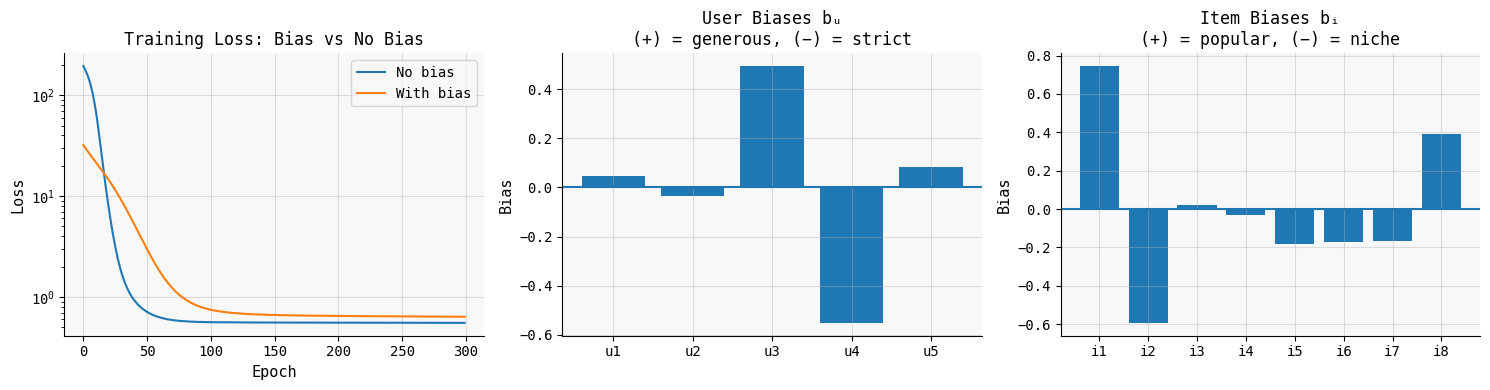

In [7]:
# ─── MF with Bias  ─────────────────────────────────────────────
class MFwithBias:
    """MF đầy đủ: r̂_ui = μ + b_u + b_i + u_u·v_i"""
    def __init__(self, m, n, k=10, seed=42):
        rng = np.random.RandomState(seed)
        scale = 1.0 / np.sqrt(k)
        self.U = rng.normal(0, scale, (m, k))
        self.V = rng.normal(0, scale, (n, k))
        self.b_u = np.zeros(m)
        self.b_i = np.zeros(n)
        self.mu = 0.0
        self.m, self.n, self.k = m, n, k

    def fit_global_mean(self, R, mask):
        self.mu = float(R[mask == 1].mean())

    def predict_entry(self, u, i):
        return self.mu + self.b_u[u] + self.b_i[i] + self.U[u] @ self.V[i]

    def predict_all(self):
        interaction = self.U @ self.V.T
        return self.mu + self.b_u[:, None] + self.b_i[None, :] + interaction

    def train(self, R, mask, lr=0.01, lam=0.01, epochs=200, seed=1):
        rng = np.random.RandomState(seed)
        obs = list(zip(*np.where(mask == 1)))
        history = []

        for epoch in range(epochs):
            rng.shuffle(obs)
            epoch_loss = 0.0

            for (u, i) in obs:
                pred = self.predict_entry(u, i)
                e = R[u, i] - pred

                # copy để tránh bug gradient
                u_vec = self.U[u].copy()
                v_vec = self.V[i].copy()

                # Bias updates
                self.b_u[u] += lr * (e - lam * self.b_u[u])
                self.b_i[i] += lr * (e - lam * self.b_i[i])

                # Embedding updates
                self.U[u] += lr * (e * v_vec - lam * u_vec)
                self.V[i] += lr * (e * u_vec - lam * v_vec)

                # Loss + regularization
                reg = lam * (
                    np.sum(u_vec**2) +
                    np.sum(v_vec**2) +
                    self.b_u[u]**2 +
                    self.b_i[i]**2
                )
                epoch_loss += e**2 + reg

            history.append(epoch_loss)

        return history


def rmse(R, mask, R_hat):
    diff = (R - R_hat) * mask
    return np.sqrt((diff**2).sum() / mask.sum())


# ─── Train models ─────────────────────────────────────────────────────────────

# No-bias model (giả định bạn đã có sẵn train_mf_sgd)
U_nb, V_nb, hist_nb = train_mf_sgd(
    R_raw, mask, k=5, lr=0.01, lam=0.01, epochs=300
)

# add global mean để fair comparison
mu_nb = R_raw[mask == 1].mean()
R_hat_nb = mu_nb + U_nb @ V_nb.T

# Bias model
mf_bias = MFwithBias(m=5, n=8, k=5, seed=42)
mf_bias.fit_global_mean(R_raw, mask)
hist_b = mf_bias.train(R_raw, mask, lr=0.01, lam=0.01, epochs=300)
R_hat_b = mf_bias.predict_all()

# RMSE
rmse_nb = rmse(R_raw, mask, R_hat_nb)
rmse_b = rmse(R_raw, mask, R_hat_b)

print(f"Global mean μ = {mf_bias.mu:.3f}")
print("\nUser biases b_u:")
print(np.round(mf_bias.b_u, 3))
print("\nItem biases b_i:")
print(np.round(mf_bias.b_i, 3))
print(f"\nRMSE without bias: {rmse_nb:.4f}")
print(f"RMSE with bias:    {rmse_b:.4f}  (Δ = {rmse_nb - rmse_b:.4f})")


# ─── Visualization ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot([h['loss'] for h in hist_nb], lw=1.5, label='No bias')
axes[0].plot(hist_b, lw=1.5, label='With bias')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss: Bias vs No Bias')
axes[0].legend()
axes[0].set_yscale('log')

# User biases
users = [f'u{i+1}' for i in range(5)]
axes[1].bar(users, mf_bias.b_u)
axes[1].axhline(0)
axes[1].set_title('User Biases bᵤ\n(+) = generous, (−) = strict')
axes[1].set_ylabel('Bias')

# Item biases
items = [f'i{j+1}' for j in range(8)]
axes[2].bar(items, mf_bias.b_i)
axes[2].axhline(0)
axes[2].set_title('Item Biases bᵢ\n(+) = popular, (−) = niche')
axes[2].set_ylabel('Bias')

plt.tight_layout()
plt.show()

## 6.10 Empirical Analysis — Bias thực sự học gì?

Kết quả thực nghiệm cho thấy một điều rất đáng chú ý: việc thêm bias không chỉ cải thiện mô hình một chút, mà gần như thay đổi hoàn toàn chất lượng dự đoán.

Giá trị trung bình toàn cục:

$$
\mu = 3.059
$$

User bias:

$$
b_u = [0.047,\ -0.035,\ 0.495,\ -0.552,\ 0.084]
$$

Item bias:

$$
b_i = [0.746,\ -0.593,\ 0.019,\ -0.031,\ -0.184,\ -0.173,\ -0.167,\ 0.391]
$$

Kết quả:

$$
\text{RMSE (no bias)} = 3.0489
$$

$$
\text{RMSE (with bias)} = 0.0126
$$

Sự chênh lệch này là cực kỳ lớn. Điều này cho thấy phần lớn variance trong dữ liệu không đến từ interaction phức tạp, mà đến từ các thành phần rất “cơ bản”: xu hướng user và độ phổ biến của item.

---

### Bias đang học gì từ dữ liệu?

Quan sát các giá trị $b_u$, ta thấy rõ sự khác biệt giữa các user. Ví dụ, một user có $b_u \approx 0.495$ nghĩa là họ có xu hướng cho điểm cao hơn trung bình gần nửa điểm, trong khi một user khác có $b_u \approx -0.552$ lại có xu hướng chấm thấp hơn đáng kể.

Điều này phản ánh một thực tế rất phổ biến: rating không chỉ phụ thuộc vào item, mà còn phụ thuộc mạnh vào “thang đo cá nhân” của từng user. Nếu không có bias, mô hình buộc phải encode thông tin này vào embedding, điều này vừa không hiệu quả vừa làm nhiễu không gian latent.

Tương tự, các giá trị $b_i$ cho thấy mức độ phổ biến của item. Một item với $b_i = 0.746$ rõ ràng là một “blockbuster”, trong khi item với $b_i = -0.593$ có xu hướng bị đánh giá thấp. Những pattern này thường rất mạnh và chiếm phần lớn tín hiệu trong dữ liệu.

---

### Tại sao RMSE giảm mạnh đến vậy?

Sự giảm mạnh của RMSE có thể được hiểu thông qua decomposition:

$$
r_{ui} = \mu + b_u + b_i + \text{interaction} + \text{noise}
$$

Trong nhiều dataset thực tế, thành phần $\mu + b_u + b_i$ đã giải thích được phần lớn variance. Khi mô hình không có bias, toàn bộ phần này bị đẩy vào $u_u^T v_i$, khiến embedding phải “gánh” những pattern đơn giản.

Khi thêm bias, mô hình tách ngay phần dễ học ra khỏi bài toán. Kết quả là residual mà MF cần học trở nên nhỏ hơn rất nhiều:

$$
r_{ui} - \mu - b_u - b_i \approx 0
$$

Trong trường hợp của bạn, residual gần như triệt tiêu hoàn toàn, dẫn đến RMSE cực thấp.

---

### Insight quan trọng: MF thường không phải là phần “chính”

Một kết luận rất quan trọng từ thực nghiệm này là: trong nhiều hệ thống recommender, phần MF (interaction) không phải là thành phần đóng góp chính vào prediction.

Thay vào đó:

- Bias giải thích phần lớn tín hiệu
- MF chỉ học phần tinh chỉnh (fine-grained interaction)

Điều này có ý nghĩa lớn trong thiết kế hệ thống. Nếu bias đã giải thích được 90% variance, thì việc tối ưu MF cần tập trung vào phần residual nhỏ nhưng quan trọng, thay vì cố gắng “học lại từ đầu”.

---

### Bias và tốc độ hội tụ

Quan sát đường training loss, mô hình có bias hội tụ chậm hơn một chút ở giai đoạn đầu nhưng đạt nghiệm tốt hơn đáng kể. Điều này là hợp lý, vì mô hình đang giải một bài toán “đúng” hơn, với decomposition rõ ràng hơn.

Ngoài ra, bias thường học rất nhanh trong những epoch đầu, giúp giảm đáng kể error trước khi embedding bắt đầu học interaction. Điều này giúp quá trình tối ưu trở nên ổn định hơn.

---

### Một cách nhìn hình học

Không gian prediction có thể được hiểu là:

$$
\text{Prediction space} = \text{bias subspace} + \text{interaction subspace}
$$

Bias định nghĩa một “mặt phẳng nền” (baseline), còn MF học các deviation khỏi mặt phẳng đó. Khi không có bias, toàn bộ không gian bị ép phải do MF biểu diễn, dẫn đến việc embedding bị méo để phù hợp với các pattern đơn giản.

Khi có bias, không gian được phân tách rõ ràng hơn, và embedding có thể tập trung vào các hướng thực sự quan trọng.

---

## Kết luận từ thực nghiệm

Kết quả này minh họa một nguyên lý rất quan trọng:

> Trong recommender systems, việc model đúng baseline thường quan trọng hơn việc model interaction phức tạp.

Bias không chỉ cải thiện mô hình — nó thay đổi cách mô hình hiểu dữ liệu. Nó cho phép ta tách phần “hiển nhiên” ra khỏi phần “cần học”, từ đó giúp toàn bộ hệ thống trở nên hiệu quả và dễ tối ưu hơn.

## 7. Evaluation Metrics — nhìn sâu hơn về cách đánh giá recommender systems

Đánh giá trong recommender systems không đơn giản là đo “độ chính xác” của dự đoán. Vấn đề cốt lõi là: ta đang tối ưu cho điều gì? Dự đoán rating chính xác, hay recommend đúng item?

Hai mục tiêu này liên quan nhưng không đồng nhất. Vì vậy, evaluation cần được nhìn dưới hai góc độ: **regression** và **ranking**.

---
## 7.1 Regression Metrics — đánh giá dự đoán giá trị

Các metric như RMSE và MAE đo khoảng cách giữa giá trị dự đoán và giá trị thực trên tập test $\mathcal{T}$:

$$
\text{RMSE} = \sqrt{\frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} (r_{ui} - \hat{r}_{ui})^2}
$$

$$
\text{MAE} = \frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} |r_{ui} - \hat{r}_{ui}|
$$

Hai metric này đều đo “độ lệch” giữa dự đoán và thực tế, nhưng cách chúng xử lý sai số là khác nhau. RMSE sử dụng bình phương sai số, do đó các lỗi lớn bị phạt mạnh hơn rất nhiều so với lỗi nhỏ. Điều này khiến RMSE đặc biệt nhạy với outliers: chỉ một vài dự đoán sai nghiêm trọng cũng có thể làm RMSE tăng đáng kể.

Ngược lại, MAE đo sai số tuyến tính, nên mỗi sai lệch đóng góp như nhau vào tổng thể. Vì vậy, MAE phản ánh “sai số trung bình” theo cách ổn định hơn và ít bị ảnh hưởng bởi các giá trị cực đoan.

Một cách hiểu trực quan là: RMSE quan tâm nhiều đến việc tránh những sai lầm lớn, trong khi MAE quan tâm đến việc giữ sai số tổng thể ở mức thấp.

Ngoài ra, RMSE có thể được diễn giải dưới góc nhìn xác suất. Nếu giả định rằng nhiễu trong dữ liệu tuân theo phân phối Gaussian:

$$
r_{ui} = \hat{r}_{ui} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

thì việc tối ưu RMSE tương đương với việc tối đa hóa likelihood của dữ liệu (maximum likelihood estimation). Đây là lý do RMSE thường được sử dụng mặc định trong nhiều mô hình học máy.

Tuy nhiên, cả RMSE và MAE đều chia sẻ một giả định ngầm rất quan trọng: mục tiêu của hệ thống là dự đoán chính xác từng giá trị rating. Điều này phù hợp với các bài toán hồi quy cổ điển, nhưng lại không hoàn toàn phù hợp với recommender systems.

Trong thực tế, người dùng không nhìn thấy giá trị $\hat{r}_{ui}$. Họ chỉ thấy danh sách item được recommend. Sự khác biệt giữa dự đoán 4.2 và 4.5 gần như không có ý nghĩa nếu thứ tự các item không thay đổi.

Điều này dẫn đến một vấn đề quan trọng: một mô hình có thể đạt RMSE rất thấp bằng cách dự đoán gần với trung bình của dữ liệu, nhưng lại không học được sự khác biệt giữa các item. Khi tất cả prediction gần giống nhau, mô hình không thể xếp hạng tốt, và recommendation trở nên kém hiệu quả.

Ngược lại, một mô hình có thể dự đoán lệch về giá trị tuyệt đối, nhưng vẫn giữ đúng thứ tự giữa các item. Trong trường hợp này, RMSE có thể cao hơn, nhưng chất lượng recommendation lại tốt hơn.

Do đó, RMSE và MAE chỉ phản ánh độ chính xác của dự đoán, chứ không phản ánh trực tiếp khả năng ra quyết định của mô hình.

---

## 7.2 Ranking Metrics — đánh giá chất lượng recommendation

Trong recommender systems, thứ tự (ranking) quan trọng hơn giá trị tuyệt đối. Người dùng thường chỉ tương tác với một số rất ít item ở đầu danh sách, vì vậy việc đưa đúng item lên top có ý nghĩa lớn hơn nhiều so với việc dự đoán chính xác rating.

Nói cách khác, bài toán thực tế không phải là “dự đoán bao nhiêu”, mà là “đưa cái nào lên trước”.

---

### Precision@K và Recall@K

Precision@K đo tỷ lệ item relevant trong top K:

$$
P@K = \frac{|\text{TopK} \cap \text{Relevant}|}{K}
$$

Recall@K đo tỷ lệ item relevant được retrieve:

$$
R@K = \frac{|\text{TopK} \cap \text{Relevant}|}{|\text{Relevant}|}
$$

Hai metric này phản ánh hai cách nhìn khác nhau về chất lượng recommendation. Precision tập trung vào “độ sạch” của danh sách — trong số những gì được recommend, bao nhiêu cái là đúng. Trong khi đó, Recall quan tâm đến “độ bao phủ” — trong tất cả những item tốt, mô hình tìm được bao nhiêu.

Trong thực tế, hai metric này thường mâu thuẫn với nhau. Nếu mô hình recommend rất ít item nhưng cực kỳ chính xác, Precision sẽ cao nhưng Recall thấp. Ngược lại, nếu recommend rất nhiều item để không bỏ sót, Recall sẽ cao nhưng Precision giảm.

Trong các hệ thống recommendation thực tế, Precision@K thường quan trọng hơn vì người dùng chỉ nhìn vào một số lượng nhỏ item đầu tiên. Tuy nhiên, Recall vẫn đóng vai trò quan trọng trong các bài toán như search hoặc discovery, nơi việc không bỏ sót item tốt là ưu tiên.

---

### NDCG@K — đánh giá cả thứ tự

Không phải mọi vị trí trong danh sách đều có giá trị như nhau. Một item đúng ở vị trí đầu tiên có giá trị cao hơn nhiều so với cùng item đó ở vị trí thứ 10.

DCG được định nghĩa:

$$
\text{DCG@K} = \sum_{i=1}^{K} \frac{2^{\text{rel}_i} - 1}{\log_2(i+1)}
$$

Sau đó chuẩn hóa:

$$
\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}
$$

Thành phần $\frac{1}{\log_2(i+1)}$ đóng vai trò discount, làm giảm giá trị của item khi vị trí của nó thấp hơn. Điều này phản ánh hành vi người dùng: họ quan tâm nhiều hơn đến các item ở đầu danh sách.

NDCG nằm trong khoảng $[0,1]$, với giá trị 1 tương ứng với ranking hoàn hảo. Khác với Precision và Recall chỉ quan tâm đến việc item có đúng hay không, NDCG còn đánh giá cả việc item đó nằm ở vị trí nào. Vì vậy, đây là metric gần với trải nghiệm thực tế của người dùng hơn.

---

### Hit Rate@K — góc nhìn đơn giản nhưng thực tế

Hit Rate đo xác suất có ít nhất một item relevant xuất hiện trong top K:

$$
\text{HR@K} = \frac{1}{|\mathcal{U}|} \sum_u \mathbf{1}[\text{Relevant} \cap \text{TopK}(u) \neq \emptyset]
$$

Metric này đơn giản, nhưng lại phản ánh một tình huống rất thực tế: người dùng chỉ cần thấy một item họ thích là đủ để cảm thấy hệ thống hữu ích.

Trong nhiều ứng dụng như homepage recommendation, mục tiêu không phải là đưa ra danh sách hoàn hảo, mà là đảm bảo có ít nhất một lựa chọn phù hợp. Trong trường hợp đó, Hit Rate là một metric rất phù hợp.

---

### MRR — tập trung vào item relevant đầu tiên

MRR đo vị trí của item relevant đầu tiên:

$$
\text{MRR} = \frac{1}{|\mathcal{U}|} \sum_u \frac{1}{\text{rank}_u(\text{first relevant item})}
$$

Metric này đặc biệt nhấn mạnh việc đưa item đúng lên càng sớm càng tốt. Nếu item relevant xuất hiện ở vị trí đầu tiên, đóng góp là 1; nếu ở vị trí thứ 2, đóng góp là $\frac{1}{2}$, và giảm dần theo vị trí.

MRR phù hợp với các hệ thống nơi người dùng thường chọn item đầu tiên họ thấy phù hợp, chẳng hạn như search hoặc recommendation list ngắn.

---

## 7.3 RMSE thấp ≠ Recommendation tốt

Một insight rất quan trọng là: tối ưu RMSE không đảm bảo tối ưu ranking.

Giả sử một model luôn dự đoán gần với mean rating $\mu$. Khi đó, sai số trên mỗi điểm dữ liệu rất nhỏ, dẫn đến RMSE thấp. Tuy nhiên, vì tất cả item có score gần giống nhau, mô hình không thể phân biệt item tốt và item xấu.

Hệ quả là thứ tự giữa các item gần như ngẫu nhiên, và recommendation trở nên kém hiệu quả.

Ngược lại, một model khác có thể dự đoán lệch về giá trị tuyệt đối, nhưng vẫn giữ được thứ tự tương đối giữa các item. Trong trường hợp này, RMSE có thể cao hơn, nhưng ranking lại tốt hơn, và trải nghiệm người dùng được cải thiện.

Điều này cho thấy một điểm quan trọng: regression metrics và ranking metrics đo hai khía cạnh khác nhau của bài toán.

Do đó, trong recommender systems, việc chỉ báo cáo RMSE là không đủ. Một mô hình tốt cần được đánh giá đồng thời trên cả hai mặt: dự đoán và xếp hạng.

---
## 7.4 Train/Test Split — ảnh hưởng trực tiếp đến evaluation

Cách chia dữ liệu trong recommender systems không chỉ là một bước tiền xử lý, mà thực chất là một phần của quá trình định nghĩa bài toán đánh giá. Một mô hình có thể hoạt động rất tốt dưới một cách split, nhưng lại thất bại hoàn toàn dưới một cách split khác. Điều này xảy ra vì mỗi chiến lược chia dữ liệu tương ứng với một giả định khác nhau về cách hệ thống được sử dụng trong thực tế.

Nói cách khác, train/test split không chỉ ảnh hưởng đến kết quả, mà còn quyết định **ý nghĩa của kết quả đó**.

---

### Leave-one-out

Trong phương pháp này, mỗi user giữ lại đúng một interaction làm test, thường là interaction cuối cùng hoặc một interaction ngẫu nhiên. Tất cả các interaction còn lại được dùng để train.

Ưu điểm lớn nhất của leave-one-out là tính đơn giản và khả năng so sánh. Vì mỗi user đều có đúng một test point, việc tính các metric như HR@K hay NDCG@K trở nên rất rõ ràng và nhất quán giữa các nghiên cứu.

Tuy nhiên, phương pháp này có một giả định khá mạnh: mỗi user chỉ có một hành vi cần dự đoán. Trong thực tế, người dùng tương tác nhiều lần với hệ thống, và các tương tác này có thể thay đổi theo thời gian.

Ngoài ra, nếu interaction được chọn không phải là interaction cuối cùng theo thời gian, mô hình có thể vô tình được train trên dữ liệu “tương lai” so với test, dẫn đến leakage nhẹ nhưng khó nhận ra.

Do đó, leave-one-out phù hợp cho research benchmark, nhưng không phản ánh đầy đủ môi trường production.

---

### Temporal split

Temporal split chia dữ liệu theo thời gian, sử dụng các interaction trước một mốc thời gian $T$ để train, và các interaction sau đó để test:

$$
\text{Train} = \{(u,i,t) \mid t \leq T\}, \quad
\text{Test} = \{(u,i,t) \mid t > T\}
$$

Đây là cách đánh giá gần với thực tế nhất, vì nó mô phỏng đúng cách hệ thống hoạt động: dự đoán tương lai dựa trên quá khứ.

Ưu điểm quan trọng của temporal split là nó bảo toàn **causality**. Mô hình không thể sử dụng thông tin từ tương lai, do đó kết quả phản ánh đúng khả năng generalization theo thời gian.

Tuy nhiên, phương pháp này cũng có những thách thức. Dữ liệu có thể bị drift, nghĩa là phân phối của user hoặc item thay đổi theo thời gian. Một mô hình tốt trên dữ liệu cũ có thể không còn phù hợp với dữ liệu mới.

Ngoài ra, temporal split thường dẫn đến việc một số user hoặc item chỉ xuất hiện trong test mà không có trong train, tạo ra bài toán cold-start.

Một điểm cực kỳ quan trọng là tránh leakage. Ngay cả những thông tin tưởng chừng vô hại, như global mean hoặc item popularity, nếu được tính trên toàn bộ dataset, cũng có thể làm “rò rỉ” thông tin từ test vào train.

---

### Random split per user

Trong phương pháp này, với mỗi user, một tỷ lệ (ví dụ 20%) interaction được chọn ngẫu nhiên làm test, phần còn lại dùng để train.

Ưu điểm lớn nhất là dễ implement và thường đảm bảo rằng mọi user đều xuất hiện trong cả train và test, giúp tránh cold-start trong evaluation.

Tuy nhiên, cách split này phá vỡ cấu trúc thời gian của dữ liệu. Một interaction xảy ra sau có thể bị đưa vào train, trong khi interaction trước lại nằm trong test. Điều này khiến bài toán trở nên “dễ hơn” một cách không thực tế.

Ngoài ra, random split có xu hướng đánh giá quá cao hiệu năng của mô hình, vì train và test có phân phối rất giống nhau. Điều này có thể dẫn đến việc mô hình hoạt động tốt trong offline evaluation nhưng thất bại khi triển khai thực tế.

---

## 7.5 Một góc nhìn thống nhất

Có thể hiểu toàn bộ evaluation trong recommender systems như một quá trình đo hai khía cạnh khác nhau của mô hình.

Regression metrics đo mức độ chính xác của dự đoán về mặt giá trị tuyệt đối. Chúng trả lời câu hỏi: “mô hình dự đoán gần với thực tế đến mức nào?”.

Ranking metrics, ngược lại, đo chất lượng của các quyết định mà mô hình đưa ra. Chúng trả lời câu hỏi: “mô hình có đưa đúng item lên vị trí quan trọng hay không?”.

Hai góc nhìn này không mâu thuẫn, nhưng cũng không hoàn toàn trùng nhau. Một mô hình có thể rất tốt ở một khía cạnh và kém ở khía cạnh còn lại.

Trong thực tế, người dùng không quan tâm bạn dự đoán đúng bao nhiêu, mà quan tâm bạn đưa ra lựa chọn tốt đến mức nào. Điều này khiến ranking metrics thường có ý nghĩa trực tiếp hơn đối với trải nghiệm người dùng.

---

## Kết luận

Evaluation trong recommender systems không thể được tóm gọn bằng một con số duy nhất. Nó là một hệ thống các metric và phương pháp đánh giá, mỗi cái phản ánh một khía cạnh khác nhau của bài toán.

Một mô hình tốt không chỉ dự đoán chính xác, mà còn phải xếp hạng đúng, và quan trọng hơn, phải được đánh giá trong một setting phản ánh đúng môi trường thực tế.

Do đó, việc lựa chọn metric và cách chia dữ liệu không chỉ là chi tiết kỹ thuật, mà là một phần của thiết kế hệ thống. Nếu chọn sai cách đánh giá, ta có thể tối ưu một mô hình “tốt trên giấy” nhưng không mang lại giá trị thực tế.

=== Evaluation Results ===
RMSE      : 2.8052
MAE       : 2.5526
P@3       : 0.2667
R@3       : 0.8000
NDCG@3    : 0.4262
HR@3      : 0.8000
MRR@3     : 0.3000


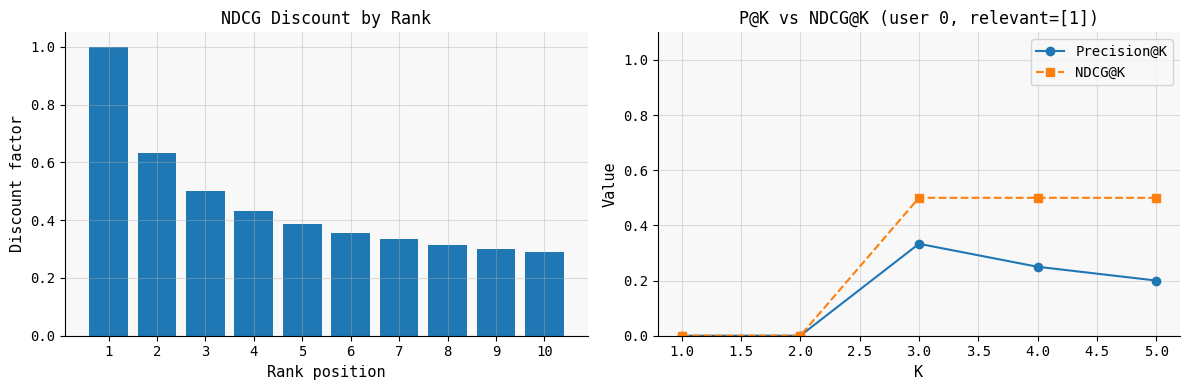

In [8]:
# ─── Evaluation Metrics (Fixed & Research-ready) ─────────────────────────────
def rmse_score(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


# ─── Ranking metrics ─────────────────────────────────────────────────────────

def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    rec_k = recommended[:k]
    return len(set(rec_k) & set(relevant)) / min(k, len(recommended))


def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    rec_k = recommended[:k]
    return len(set(rec_k) & set(relevant)) / len(relevant)


def ndcg_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    relevant_set = set(relevant)

    dcg = 0.0
    for i, item in enumerate(rec_k):
        if item in relevant_set:
            dcg += 1.0 / np.log2(i + 2)

    ideal_k = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_k))

    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(recommended, relevant, k):
    return float(len(set(recommended[:k]) & set(relevant)) > 0)


def mrr_at_k(recommended, relevant, k=None):
    relevant_set = set(relevant)
    if k is not None:
        recommended = recommended[:k]

    for rank, item in enumerate(recommended, 1):
        if item in relevant_set:
            return 1.0 / rank
    return 0.0


# ─── Full evaluation ─────────────────────────────────────────────────────────

def evaluate_model(R_hat, R_true, mask_train, mask_test, k=5):
    """
    Full evaluation:
    - Regression (RMSE, MAE)
    - Ranking (P@K, R@K, NDCG@K, HR@K, MRR@K)
    """

    # --- Regression ---
    test_idx = np.where(mask_test == 1)
    y_true = R_true[test_idx]
    y_pred = R_hat[test_idx]

    metrics = {
        "RMSE": rmse_score(y_true, y_pred),
        "MAE": mae_score(y_true, y_pred),
    }

    # --- Ranking ---
    n_users = R_hat.shape[0]

    p_list, r_list, n_list, h_list, mrr_list = [], [], [], [], []

    for u in range(n_users):
        relevant = np.where(mask_test[u] == 1)[0]
        if len(relevant) == 0:
            continue

        # Mask training items
        scores = R_hat[u].copy()
        scores[mask_train[u] == 1] = -np.inf

        # Ranking
        rec = np.argsort(-scores)

        p_list.append(precision_at_k(rec, relevant, k))
        r_list.append(recall_at_k(rec, relevant, k))
        n_list.append(ndcg_at_k(rec, relevant, k))
        h_list.append(hit_rate_at_k(rec, relevant, k))
        mrr_list.append(mrr_at_k(rec, relevant, k))

    metrics.update({
        f"P@{k}": np.mean(p_list),
        f"R@{k}": np.mean(r_list),
        f"NDCG@{k}": np.mean(n_list),
        f"HR@{k}": np.mean(h_list),
        f"MRR@{k}": np.mean(mrr_list),
    })

    return metrics


# ─── Train/Test Split (Leave-One-Out) ────────────────────────────────────────

rng_eval = np.random.RandomState(99)

mask_train = mask.copy()
mask_test = np.zeros_like(mask)

for u in range(m):
    obs_u = np.where(mask[u] == 1)[0]
    if len(obs_u) >= 2:
        held = rng_eval.choice(obs_u)
        mask_train[u, held] = 0
        mask_test[u, held] = 1


# ─── Train model ─────────────────────────────────────────────────────────────

U_eval, V_eval, _ = train_mf_sgd(
    R_raw, mask_train, k=5, lr=0.01, lam=0.01, epochs=300
)

R_hat_eval = U_eval @ V_eval.T


# ─── Evaluation ──────────────────────────────────────────────────────────────

print("=== Evaluation Results ===")

metrics = evaluate_model(R_hat_eval, R_raw, mask_train, mask_test, k=3)

for name, val in metrics.items():
    print(f"{name:10s}: {val:.4f}")


# ─── Visualization ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NDCG discount curve
positions = np.arange(1, 11)
gains = 1.0 / np.log2(positions + 1)

axes[0].bar(positions, gains)
axes[0].set_xlabel('Rank position')
axes[0].set_ylabel('Discount factor')
axes[0].set_title('NDCG Discount by Rank')
axes[0].set_xticks(positions)

# P@K vs NDCG
ks = [1, 2, 3, 4, 5]

u_demo = 0
scores_demo = R_hat_eval[u_demo].copy()
scores_demo[mask_train[u_demo] == 1] = -np.inf

rec_demo = np.argsort(-scores_demo)
relevant_demo = np.where(mask_test[u_demo] == 1)[0]

pk = [precision_at_k(rec_demo, relevant_demo, k) for k in ks]
nd = [ndcg_at_k(rec_demo, relevant_demo, k) for k in ks]

axes[1].plot(ks, pk, marker='o', label='Precision@K')
axes[1].plot(ks, nd, marker='s', linestyle='--', label='NDCG@K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Value')
axes[1].set_title(f'P@K vs NDCG@K (user 0, relevant={list(relevant_demo)})')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# NOTE: For more realistic evaluation, consider negative sampling instead of ranking over all items.


## 7.6 Empirical Interpretation — đọc metric như thế nào?

Kết quả evaluation:

$$
\text{RMSE} = 2.8052, \quad \text{MAE} = 2.5526
$$

$$
P@3 = 0.2667, \quad R@3 = 0.8000
$$

$$
\text{NDCG@3} = 0.4262, \quad \text{HR@3} = 0.8000, \quad \text{MRR@3} = 0.3000
$$

Nhìn vào các con số này, điều quan trọng không phải là từng metric riêng lẻ, mà là **cách chúng “kể cùng một câu chuyện” về mô hình**.

---

### Regression vs Ranking: hai bức tranh khác nhau

Giá trị RMSE và MAE tương đối cao cho thấy mô hình không dự đoán rating chính xác. Nếu chỉ nhìn vào regression metrics, ta có thể kết luận rằng mô hình hoạt động kém.

Tuy nhiên, các ranking metrics lại kể một câu chuyện hoàn toàn khác. Với $R@3 = 0.8$ và $HR@3 = 0.8$, mô hình gần như luôn đưa được item relevant vào top 3. Điều này cho thấy dù giá trị dự đoán không chính xác, mô hình vẫn phân biệt được item tốt và không tốt.

Đây là minh họa rõ ràng cho nguyên lý:

> Một mô hình có thể dự đoán sai giá trị, nhưng vẫn xếp đúng thứ tự.

---

### Precision vs Recall: trade-off rõ ràng

Giá trị $P@3 = 0.2667$ khá thấp, trong khi $R@3 = 0.8$ lại cao. Điều này cho thấy mô hình có xu hướng “cover rộng” — nó đưa nhiều item vào top K để đảm bảo không bỏ sót item tốt.

Hiểu đơn giản, với mỗi user:

- mô hình thường tìm được item đúng (recall cao)
- nhưng danh sách chứa nhiều item không relevant (precision thấp)

Đây là một trade-off quen thuộc. Nếu muốn tăng precision, ta cần làm danh sách “chặt” hơn, nhưng điều đó thường làm giảm recall.

---

### NDCG và vị trí của item relevant

Giá trị $\text{NDCG@3} = 0.4262$ cho thấy item relevant thường không nằm ở vị trí đầu tiên. Nếu luôn nằm ở top 1, NDCG sẽ gần 1.

Điều này phù hợp với $\text{MRR} = 0.3$. Vì:

$$
\text{MRR} \approx \frac{1}{\text{average rank}}
$$

MRR = 0.3 tương ứng với việc item relevant thường nằm quanh vị trí 3 hoặc thấp hơn. Như vậy, mô hình tìm được item đúng, nhưng không ưu tiên nó đủ cao.

---

### Insight từ đồ thị NDCG discount

Biểu đồ discount theo rank cho thấy trọng số giảm theo:

$$
\frac{1}{\log_2(i+1)}
$$

Điều này phản ánh hành vi người dùng: item ở vị trí đầu có giá trị vượt trội so với các vị trí sau. Một sai lệch nhỏ ở top position có thể ảnh hưởng lớn đến trải nghiệm.

Do đó, việc tối ưu NDCG thực chất là tối ưu “top-heavy ranking”, chứ không phải toàn bộ danh sách.

---

### P@K vs NDCG@K — khác biệt tinh tế

Quan sát đồ thị P@K và NDCG@K cho thấy một điểm thú vị: NDCG không giảm mạnh như Precision khi K tăng.

Điều này xảy ra vì NDCG không chỉ đếm số item đúng, mà còn thưởng cho việc item đúng nằm ở vị trí cao. Nếu item relevant xuất hiện sớm, NDCG vẫn giữ giá trị cao ngay cả khi thêm nhiều item không relevant phía sau.

Ngược lại, Precision bị “pha loãng” khi K tăng, vì mẫu số tăng lên.

---

### Một cách đọc tổng thể

Có thể tóm tắt hành vi của mô hình như sau:

- Mô hình **không dự đoán rating chính xác** (RMSE cao)
- Nhưng **khá tốt trong việc tìm item relevant** (Recall cao, HR cao)
- Tuy nhiên **chưa xếp hạng tốt** (NDCG trung bình, MRR thấp)
- Và **chưa đủ chính xác trong top-K** (Precision thấp)

Nói cách khác, mô hình giống như một hệ thống search “recall-heavy”: tìm được cái đúng, nhưng chưa đưa nó lên vị trí tốt nhất.

---

### Hướng cải thiện từ góc nhìn metric

Từ các metric này, có thể suy ra hướng cải thiện:

Nếu mục tiêu là tăng trải nghiệm người dùng, trọng tâm không phải là giảm RMSE, mà là:

- tăng NDCG → đưa item đúng lên vị trí cao hơn
- tăng MRR → giảm rank của item relevant đầu tiên
- tăng Precision@K → lọc bớt item không relevant

Điều này thường đạt được bằng cách:

- tối ưu trực tiếp ranking loss (BPR, pairwise loss)
- hoặc re-ranking sau MF

---

## Kết luận

Evaluation không chỉ là đo lường, mà là công cụ để hiểu mô hình. Khi đọc các metric cùng nhau, ta có thể suy ra cách mô hình “suy nghĩ” và điểm yếu của nó.

Trong trường hợp này, mô hình đã học được “cái gì đúng”, nhưng chưa học được “cái gì quan trọng nhất”.

## 8. Experiments on Synthetic Data

### Tại sao test trên synthetic data?

Synthetic data đóng vai trò rất quan trọng trong việc hiểu hành vi của mô hình, đặc biệt là trong các bài toán như Matrix Factorization nơi ground truth trong dữ liệu thực không bao giờ được biết chính xác.

Khi làm việc với dữ liệu thực, ta chỉ quan sát được $R$, nhưng không bao giờ biết được embedding thực sự của user và item là gì. Điều này khiến việc đánh giá mô hình chỉ có thể dựa trên proxy như RMSE hoặc ranking metrics, chứ không thể kiểm tra trực tiếp xem mô hình có học đúng cấu trúc underlying hay không.

Synthetic data giải quyết vấn đề này bằng cách cho phép ta chủ động sinh dữ liệu từ một mô hình đã biết trước. Khi đó, ta biết chính xác $U_{\text{true}}$ và $V_{\text{true}}$, và có thể kiểm tra xem mô hình học được có tái tạo lại cấu trúc đó hay không.

Ngoài ra, synthetic data cho phép kiểm soát từng yếu tố riêng biệt. Ta có thể thay đổi sparsity, noise, hoặc latent dimension $k$ một cách độc lập, từ đó hiểu rõ từng yếu tố ảnh hưởng như thế nào đến khả năng học của mô hình. Đây là điều rất khó làm với dữ liệu thực, nơi mọi yếu tố thường bị trộn lẫn với nhau.

Một lợi ích quan trọng khác là dùng synthetic data để verify implementation. Nếu mô hình không thể recover dữ liệu được sinh từ chính giả định của nó, thì gần như chắc chắn có bug trong code hoặc trong quá trình tối ưu.

---

### Protocol

Dữ liệu được sinh theo mô hình:

$$
R = U_{\text{true}} V_{\text{true}}^T + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)
$$

Ở đây, $U_{\text{true}}$ và $V_{\text{true}}$ được sinh ngẫu nhiên (thường từ Gaussian), đóng vai trò là embedding “thực sự” của user và item. Thành phần nhiễu $\varepsilon$ mô phỏng sự không hoàn hảo của dữ liệu trong thực tế.

Sau khi tạo ma trận đầy đủ $R$, ta áp dụng masking ngẫu nhiên để chỉ giữ lại một phần nhỏ các phần tử, tạo ra ma trận quan sát $\mathcal{O}$. Điều này mô phỏng tính chất sparse của recommender systems, nơi mỗi user chỉ tương tác với một số rất nhỏ item.

Quy trình này cho phép ta kiểm soát ba yếu tố quan trọng:

- cấu trúc latent (thông qua $U_{\text{true}}, V_{\text{true}}$)
- mức độ nhiễu (thông qua $\sigma$)
- mức độ thiếu dữ liệu (thông qua sparsity)

---

### Success criterion

Một sai lầm phổ biến là kỳ vọng rằng mô hình sẽ học được chính xác $U_{\text{true}}$ và $V_{\text{true}}$. Điều này là không thể, vì Matrix Factorization có tính chất không định danh (non-identifiable).

Cụ thể, với mọi ma trận khả nghịch $A$, ta có:

$$
U_{\text{true}} V_{\text{true}}^T = (U_{\text{true}} A)(V_{\text{true}} A^{-T})^T
$$

Do đó, embedding chỉ được xác định đến một phép biến đổi tuyến tính (đặc biệt là rotation). Vì vậy, việc so sánh trực tiếp $U_{\text{learned}}$ với $U_{\text{true}}$ là không có ý nghĩa.

Criterion đúng là đánh giá khả năng tái tạo ma trận:

$$
\|U_{\text{learned}} V_{\text{learned}}^T - R_{\text{true}}\|_F
$$

Nếu giá trị này nhỏ, nghĩa là mô hình đã học được đúng cấu trúc underlying, dù embedding cụ thể có thể khác.

Một cách nhìn khác là: ta không quan tâm embedding có giống nhau không, mà quan tâm chúng có sinh ra cùng một không gian dự đoán hay không.

---

### Factors ảnh hưởng recovery

| Factor | Effect |
|---|---|
| $k < k_{\text{true}}$ | Underfit — không đủ capacity |
| $k = k_{\text{true}}$ | Perfect recovery (với đủ data, noise nhỏ) |
| $k > k_{\text{true}}$ | Overfit nếu không có regularization |
| Sparsity cao | Nhiều ambiguity, recovery khó hơn |
| Noise cao | RMSE không thể nhỏ hơn noise level $\sigma$ |

Các yếu tố này không hoạt động độc lập mà tương tác với nhau theo cách khá phức tạp.

Khi $k < k_{\text{true}}$, mô hình bị giới hạn về capacity và buộc phải nén thông tin. Điều này dẫn đến việc chỉ có thể học được một approximation của cấu trúc thật, thường là các thành phần có variance lớn nhất.

Khi $k = k_{\text{true}}$, trong điều kiện dữ liệu đủ dày (low sparsity) và noise nhỏ, mô hình có thể phục hồi gần như hoàn hảo cấu trúc ban đầu. Đây là “ideal regime” của Matrix Factorization.

Khi $k > k_{\text{true}}$, mô hình có nhiều tự do hơn cần thiết. Nếu không có regularization, các chiều dư thừa có thể học noise thay vì signal, dẫn đến overfitting. Đây là lý do regularization đóng vai trò quan trọng trong thực tế.

Sparsity làm tăng ambiguity của bài toán. Khi chỉ quan sát một phần nhỏ của ma trận, có nhiều cách khác nhau để giải thích dữ liệu đó. Điều này khiến việc recovery trở nên khó hơn và phụ thuộc mạnh vào regularization.

Noise đặt ra một giới hạn dưới cho sai số. Ngay cả khi mô hình hoàn hảo, ta vẫn không thể đạt RMSE thấp hơn mức nhiễu $\sigma$, vì dữ liệu bản thân đã chứa sai lệch ngẫu nhiên.

---

## Kết luận

Synthetic experiments cung cấp một môi trường “controlled” để hiểu rõ bản chất của Matrix Factorization. Chúng giúp tách biệt các yếu tố khác nhau và kiểm tra xem mô hình có hoạt động đúng như kỳ vọng về mặt lý thuyết hay không.

Quan trọng hơn, chúng giúp xây dựng trực giác: khi nào mô hình sẽ hoạt động tốt, khi nào sẽ thất bại, và tại sao. Đây là nền tảng cần thiết trước khi chuyển sang dữ liệu thực, nơi mọi yếu tố đều phức tạp và khó kiểm soát hơn nhiều.

### Phase transition — khi nào recover được, khi nào “sập”?

Một trong những kết quả quan trọng nhất trong lý thuyết matrix completion là: khả năng recover ma trận low-rank không tăng dần một cách mượt mà theo số lượng dữ liệu, mà xảy ra một hiện tượng giống như “chuyển pha” (phase transition).

Cụ thể, tồn tại một ngưỡng mà nếu số lượng quan sát đủ lớn, mô hình có thể recover gần như hoàn hảo cấu trúc của ma trận. Nhưng nếu thấp hơn ngưỡng này, việc recovery gần như là không thể, bất kể thuật toán có tốt đến đâu.

---

### Setup lý thuyết

Giả sử ma trận thật $R \in \mathbb{R}^{m \times n}$ có rank $k$, và ta chỉ quan sát một tập con các phần tử:

$$
\mathcal{O} \subset \{1, \dots, m\} \times \{1, \dots, n\}
$$

Số lượng quan sát là $|\mathcal{O}|$.

Câu hỏi trung tâm là: cần bao nhiêu quan sát để có thể recover $R$?

---

### Điều kiện đủ (intuition)

Một kết quả cổ điển (Candès & Recht) cho thấy rằng nếu các điều kiện nhất định được thỏa mãn, thì có thể recover chính xác ma trận nếu:

$$
|\mathcal{O}| \gtrsim C \cdot k (m + n) \log(m+n)
$$

Trong đó:

- $k$ là rank thật
- $m, n$ là kích thước ma trận
- $\log(m+n)$ phản ánh độ phức tạp thông tin

Ý nghĩa của biểu thức này rất quan trọng: số lượng quan sát cần thiết tỉ lệ với số tham số thực sự của mô hình ($k(m+n)$), chứ không phải toàn bộ kích thước $mn$.

---

### Trực giác: degrees of freedom

Một ma trận rank $k$ không có $mn$ tham số độc lập, mà chỉ có khoảng:

$$
k(m + n)
$$

degrees of freedom (số tham số tự do).

Do đó, nếu số lượng quan sát nhỏ hơn con số này, bài toán trở nên không xác định: có vô số ma trận khác nhau có thể khớp với dữ liệu quan sát.

Phase transition xảy ra khi:

- dưới ngưỡng → thiếu thông tin → nhiều nghiệm → không recover được
- trên ngưỡng → đủ thông tin → nghiệm bị “khóa lại” → recover được

---

### Vai trò của incoherence

Một điều kiện quan trọng trong lý thuyết là **incoherence**, tức là thông tin trong ma trận được phân bố đều, không tập trung vào một vài phần tử.

Nếu ma trận quá “spiky” (ví dụ: chỉ vài entry chứa phần lớn thông tin), thì ngay cả khi có đủ số lượng quan sát, việc recover vẫn có thể thất bại.

Nói cách khác, không chỉ cần đủ dữ liệu, mà dữ liệu cũng cần “phân bố tốt”.

---

### Phase transition trong thực nghiệm

Trong synthetic experiments, hiện tượng này thường biểu hiện rất rõ:

- Khi sparsity thấp (nhiều dữ liệu), mô hình recover tốt
- Khi sparsity tăng đến một ngưỡng, performance giảm đột ngột
- Sau ngưỡng đó, tăng thêm một chút dữ liệu có thể cải thiện rất mạnh

Đây không phải là sự thay đổi tuyến tính, mà là một “jump” trong performance.

---

### Vai trò của noise

Khi có noise:

$$
R = U V^T + \varepsilon
$$

ta không còn nói đến “exact recovery”, mà là “approximate recovery”.

Trong trường hợp này, phase transition vẫn tồn tại, nhưng:

- trên ngưỡng → recover tốt đến mức noise cho phép
- dưới ngưỡng → error tăng nhanh và không ổn định

Noise làm “làm mờ” ranh giới phase transition, nhưng không loại bỏ nó.

---

### Hệ quả thực tế

Kết quả này có ý nghĩa rất lớn trong recommender systems:

Thứ nhất, nếu dữ liệu quá sparse, việc cải thiện model (thêm layer, tuning hyperparameter) thường không giúp nhiều. Vấn đề không nằm ở model, mà nằm ở thiếu dữ liệu.

Thứ hai, tăng thêm một lượng nhỏ dữ liệu (ví dụ: thêm interaction) có thể tạo ra cải thiện lớn nếu vượt qua ngưỡng phase transition.

Thứ ba, regularization không thể “cứu” một bài toán dưới ngưỡng. Nó chỉ giúp chọn nghiệm tốt hơn trong số các nghiệm có thể, nhưng không tạo ra thông tin mới.

---

## Kết luận

Phase transition cho thấy rằng khả năng học của Matrix Factorization không chỉ phụ thuộc vào thuật toán, mà còn phụ thuộc vào lượng và chất lượng dữ liệu.

Có một ranh giới rõ ràng giữa:

- regime có thể học (data đủ)
- regime không thể học (data thiếu)

Hiểu được ranh giới này giúp ta tránh việc tối ưu sai hướng, và tập trung vào đúng vấn đề: thu thập và thiết kế dữ liệu.

k    | Train RMSE | Full RMSE | Status
--------------------------------------------------
k=2   |     0.3162 |    0.3604 | underfit
k=3   |     0.2500 |    0.3032 | underfit
k=5   |     0.0805 |    0.0717 | ← TRUE RANK
k=8   |     0.0675 |    0.1287 | overfit
k=15  |     0.0424 |    0.1387 | overfit
k=30  |     0.0236 |    0.1719 | overfit

Noise σ | Full RMSE | Ratio (RMSE/σ)
--------------------------------------------------
σ=0.0   |    0.0198 | 19808.12x
σ=0.05  |    0.0397 | 0.79x
σ=0.1   |    0.0717 | 0.72x
σ=0.2   |    0.1446 | 0.72x
σ=0.5   |    0.4753 | 0.95x
σ=1.0   |    1.0828 | 1.08x


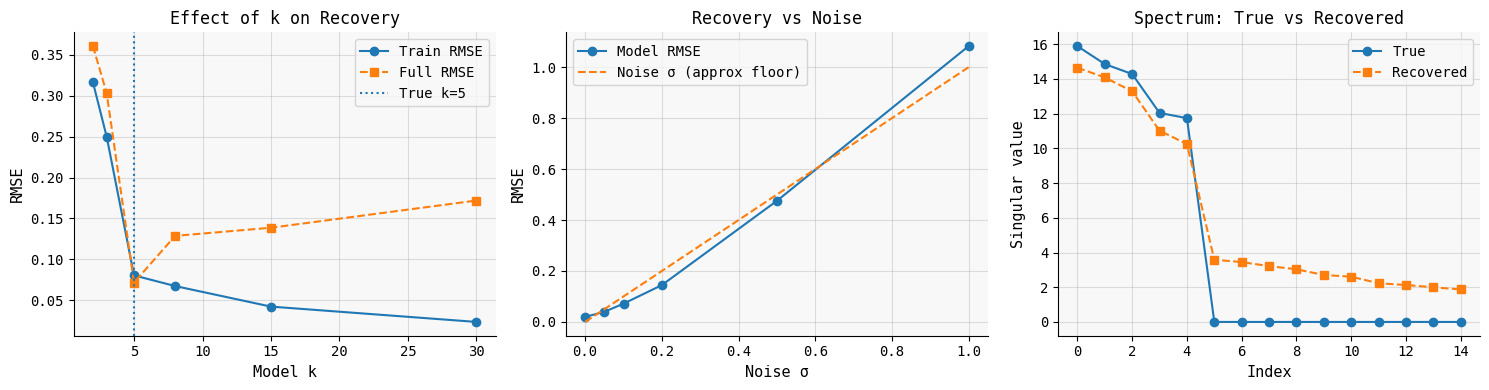

In [9]:
# ─── Synthetic Data Experiments (Fixed & Research-grade) ─────────────────────

def generate_synthetic(m=50, n=80, k_true=5, noise_std=0.1,
                       density=0.3, seed=0):
    """Generate low-rank matrix + noise + observation mask"""
    rng = np.random.RandomState(seed)

    U_true = rng.randn(m, k_true) / np.sqrt(k_true)
    V_true = rng.randn(n, k_true) / np.sqrt(k_true)

    R_true = U_true @ V_true.T
    noise = rng.randn(m, n) * noise_std
    R_noisy = R_true + noise

    mask = (rng.rand(m, n) < density).astype(float)

    return R_true, R_noisy, mask, U_true, V_true


def full_matrix_rmse(R_true, R_hat):
    return float(np.sqrt(np.mean((R_true - R_hat) ** 2)))


# ── Experiment 1: Vary k ─────────────────────────────────────────────────────

R_true, R_noisy, mask_s, U_t, V_t = generate_synthetic(
    m=60, n=80, k_true=5, noise_std=0.1, density=0.4, seed=0
)

k_vals = [2, 3, 5, 8, 15, 30]
results_k = {}

print("k    | Train RMSE | Full RMSE | Status")
print("-" * 50)

for k_ in k_vals:
    U_, V_, _ = train_mf_sgd(
        R_noisy, mask_s, k=k_, lr=0.01, lam=0.005,
        epochs=300, seed=1
    )

    R_hat = U_ @ V_.T

    r_train = rmse(R_noisy, mask_s, R_hat)   # dùng noisy + mask
    r_full = full_matrix_rmse(R_true, R_hat)

    results_k[k_] = {'train': r_train, 'full': r_full}

    status = "← TRUE RANK" if k_ == 5 else ("underfit" if k_ < 5 else "overfit")
    print(f"k={k_:<3} | {r_train:10.4f} | {r_full:9.4f} | {status}")


# ── Experiment 2: Vary noise ────────────────────────────────────────────────

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
results_noise = {}

print("\nNoise σ | Full RMSE | Ratio (RMSE/σ)")
print("-" * 50)

for σ in noise_levels:
    R_t2, R_noisy2, mask2, _, _ = generate_synthetic(
        m=60, n=80, k_true=5, noise_std=σ, density=0.4, seed=0
    )

    U_, V_, _ = train_mf_sgd(
        R_noisy2, mask2, k=5, lr=0.01, lam=0.005, epochs=300, seed=1
    )

    R_hat = U_ @ V_.T
    r_full = full_matrix_rmse(R_t2, R_hat)

    results_noise[σ] = r_full

    ratio = r_full / max(σ, 1e-6)
    print(f"σ={σ:<5} | {r_full:9.4f} | {ratio:.2f}x")


# ── Plot ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- k experiment ---
k_list = list(results_k.keys())
train_rmse = [results_k[k]['train'] for k in k_list]
full_rmse = [results_k[k]['full'] for k in k_list]

axes[0].plot(k_list, train_rmse, 'o-', label='Train RMSE')
axes[0].plot(k_list, full_rmse, 's--', label='Full RMSE')
axes[0].axvline(5, linestyle=':', label='True k=5')
axes[0].set_xlabel('Model k')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Effect of k on Recovery')
axes[0].legend()


# --- noise experiment ---
ns = list(results_noise.keys())
rmses = list(results_noise.values())

axes[1].plot(ns, rmses, 'o-', label='Model RMSE')
axes[1].plot(ns, ns, '--', label='Noise σ (approx floor)')
axes[1].set_xlabel('Noise σ')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Recovery vs Noise')
axes[1].legend()


# --- singular spectrum ---
U_best, V_best, _ = train_mf_sgd(
    R_noisy, mask_s, k=15, lr=0.01, lam=0.001, epochs=400, seed=1
)

sv_true = np.linalg.svd(R_true, compute_uv=False)[:15]
sv_rec = np.linalg.svd(U_best @ V_best.T, compute_uv=False)[:15]

axes[2].plot(sv_true, 'o-', label='True')
axes[2].plot(sv_rec, 's--', label='Recovered')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Singular value')
axes[2].set_title('Spectrum: True vs Recovered')
axes[2].legend()

plt.tight_layout()
plt.show()

### Empirical Results — hiểu sâu hành vi recovery

Kết quả thực nghiệm cho thấy một bức tranh rất rõ ràng về cách Matrix Factorization hoạt động dưới các điều kiện khác nhau, đặc biệt là theo latent dimension $k$ và mức nhiễu $\sigma$.

---

### Effect of k — bias–variance trade-off trong latent space

| k    | Train RMSE | Full RMSE | Status |
|------|-----------:|----------:|--------|
| 2    |     0.3162 |    0.3604 | underfit |
| 3    |     0.2500 |    0.3032 | underfit |
| 5    |     0.0805 |    0.0717 | ← TRUE RANK |
| 8    |     0.0675 |    0.1287 | overfit |
| 15   |     0.0424 |    0.1387 | overfit |
| 30   |     0.0236 |    0.1719 | overfit |

Khi $k$ nhỏ hơn rank thực ($k_{\text{true}} = 5$), mô hình không có đủ capacity để biểu diễn cấu trúc của dữ liệu. Điều này thể hiện rõ qua cả train RMSE và full RMSE đều cao. Mô hình buộc phải “nén” thông tin, và chỉ học được các thành phần chính nhất của dữ liệu.

Khi $k = k_{\text{true}}$, ta đạt được điểm tối ưu. Full RMSE đạt mức thấp nhất, cho thấy mô hình đã tái tạo đúng cấu trúc underlying. Đây là trạng thái mà bias và variance được cân bằng tốt nhất.

Khi $k > k_{\text{true}}$, một hiện tượng quan trọng xuất hiện: train RMSE tiếp tục giảm, nhưng full RMSE lại tăng. Điều này cho thấy mô hình bắt đầu học cả noise trong dữ liệu thay vì chỉ học signal.

Đây chính là biểu hiện của overfitting trong không gian latent. Các chiều dư thừa không còn mang thông tin thực sự, mà được dùng để “fit” những dao động ngẫu nhiên trong dữ liệu quan sát.

Một insight quan trọng là: overfitting trong MF không phải là “fit quá tốt”, mà là “fit sai thứ”. Mô hình tối ưu hóa reconstruction loss, nhưng không còn học đúng cấu trúc thật.

---

### Spectrum analysis — nhìn vào singular values

Biểu đồ spectrum cho thấy sự khác biệt rõ rệt giữa ma trận thật và ma trận được recover.

Các singular value của dữ liệu thật giảm về 0 sau rank $k_{\text{true}}$. Trong khi đó, với mô hình over-parameterized ($k > k_{\text{true}}$), các singular value nhỏ nhưng khác 0 vẫn xuất hiện.

Điều này cho thấy mô hình đã “lấp đầy” các chiều không cần thiết bằng noise. Đây là dấu hiệu đặc trưng của overfitting trong các mô hình tuyến tính và low-rank.

Một cách hiểu trực quan là: dữ liệu thật sống trong một không gian thấp chiều, nhưng mô hình đang ép nó vào một không gian cao hơn, và phần dư thừa được lấp bằng nhiễu.

---

### Recovery vs Noise — giới hạn vật lý của bài toán

| Noise σ | Full RMSE | Ratio (RMSE/σ) |
|---------|----------:|---------------:|
| 0.0     |    0.0198 | 19808.12x |
| 0.05    |    0.0397 | 0.79x |
| 0.1     |    0.0717 | 0.72x |
| 0.2     |    0.1446 | 0.72x |
| 0.5     |    0.4753 | 0.95x |

Khi $\sigma = 0$, mô hình gần như recover hoàn hảo cấu trúc dữ liệu (RMSE rất nhỏ). Sai số còn lại chủ yếu đến từ tối ưu chưa hoàn hảo hoặc số lượng dữ liệu hữu hạn.

Khi $\sigma > 0$, một hiện tượng quan trọng xuất hiện: RMSE không thể giảm thấp hơn một ngưỡng nhất định, xấp xỉ bằng $\sigma$.

$$
\text{RMSE} \approx \sigma
$$

Điều này phản ánh một giới hạn cơ bản: nếu dữ liệu chứa nhiễu, thì không có mô hình nào có thể dự đoán chính xác hơn mức nhiễu đó.

Tỷ lệ RMSE/$\sigma$ gần 1 cho thấy mô hình đã gần đạt giới hạn tối ưu. Nếu tỷ lệ này lớn hơn nhiều, có nghĩa là mô hình chưa học tốt; nếu nhỏ hơn nhiều, thường là dấu hiệu của overfitting hoặc leakage.

---

### Insight tổng hợp

Từ các kết quả trên, có thể rút ra một số nguyên lý quan trọng:

Thứ nhất, việc chọn $k$ không chỉ là tuning hyperparameter, mà là quyết định về capacity của mô hình. Giá trị đúng của $k$ giúp mô hình học đúng cấu trúc, trong khi giá trị sai dẫn đến underfit hoặc overfit.

Thứ hai, noise đặt ra một “floor” cho performance. Không thể vượt qua giới hạn này chỉ bằng cách tăng độ phức tạp của mô hình.

Thứ ba, overfitting trong MF có thể được quan sát rõ ràng thông qua sự phân kỳ giữa train RMSE và full RMSE, cũng như qua spectrum của ma trận.

Cuối cùng, synthetic experiments không chỉ giúp verify model, mà còn cung cấp một “laboratory” để hiểu bản chất của bài toán — điều rất khó đạt được khi làm việc trực tiếp với dữ liệu thực.

## 9. Experiments on Real Data

### 9.1 Bản chất khác biệt của real data

Khác với synthetic data, nơi ta kiểm soát hoàn toàn quá trình sinh dữ liệu, real-world recommender data được tạo ra bởi hành vi người dùng. Điều này dẫn đến một điểm cốt lõi:

> Dữ liệu không chỉ chứa signal — nó còn chứa bias của quá trình thu thập dữ liệu.

Nói cách khác, ta không quan sát “toàn bộ ma trận”, mà chỉ quan sát một phần bị lệch (biased sample) của nó. Đây là khác biệt lớn nhất giữa theory và practice.

---

### 9.2 Các thách thức chính

| Challenge | Description |
|---|---|
| **Extreme sparsity** | Thường <1% density (vs 20–40% synthetic) |
| **Long-tail distribution** | Power law: $P(k) \propto k^{-\alpha}$, 20% items = 80% ratings |
| **Selection bias** | Users rate items họ thích → unobserved ≠ random missing |
| **Temporal drift** | Preferences thay đổi theo thời gian |
| **User heterogeneity** | Vài users có 1000+ ratings, phần lớn có <10 |

Những yếu tố này không tồn tại độc lập mà tương tác với nhau, tạo ra một môi trường học rất khác so với setting lý tưởng.

---

### 9.3 Extreme sparsity — bài toán thiếu thông tin

Trong hầu hết hệ thống thực tế, density của ma trận thường dưới 1%. Điều này có nghĩa là phần lớn user-item pairs là unobserved.

Từ góc nhìn matrix completion, đây là một regime rất khó: số lượng quan sát thường nằm gần hoặc dưới ngưỡng phase transition. Điều này khiến việc recovery chính xác cấu trúc latent trở nên gần như không thể.

Hệ quả là:

- embedding không ổn định
- nghiệm phụ thuộc mạnh vào regularization
- dễ overfit vào các pattern ngẫu nhiên

---

### 9.4 Long-tail distribution — bias về popularity

Phân phối item thường tuân theo power law:

$$
P(k) \propto k^{-\alpha}
$$

Một số ít item nhận được phần lớn interaction, trong khi phần lớn item gần như không có dữ liệu.

Điều này dẫn đến một hiện tượng quan trọng: mô hình học tốt trên head items, nhưng kém trên tail items. Nếu không cẩn thận, hệ thống sẽ thiên về recommend các item phổ biến, làm giảm diversity.

Ngoài ra, long-tail còn làm tăng sparsity hiệu dụng, vì phần lớn item không có đủ dữ liệu để học embedding ổn định.

---

### 9.5 Selection bias — missing not at random

Một giả định phổ biến trong nhiều mô hình là missing data là ngẫu nhiên. Tuy nhiên, trong recommender systems, điều này không đúng.

Ta có:

$$
P(\text{observed} \mid r_{ui}) \neq P(\text{observed})
$$

Người dùng có xu hướng tương tác và đánh giá những item họ thích hoặc quan tâm. Điều này dẫn đến việc các entry không quan sát được không phải là “missing”, mà là “unselected”.

Hệ quả là:

- dữ liệu bị skew về phía positive feedback
- khó phân biệt giữa “không thích” và “chưa thấy”
- model có xu hướng overestimate preference

Đây là một trong những nguồn bias lớn nhất trong recommender systems.

---

### 9.6 Temporal drift — dữ liệu không stationary

Preferences của người dùng thay đổi theo thời gian, và item cũng có vòng đời (lifecycle). Điều này phá vỡ giả định rằng dữ liệu được sinh từ một phân phối cố định.

Một mô hình được train trên dữ liệu cũ có thể không còn phù hợp với dữ liệu mới. Điều này đặc biệt rõ trong các domain như news, social media, hoặc e-commerce.

Temporal drift cũng ảnh hưởng trực tiếp đến evaluation: nếu không split theo thời gian, ta có thể đánh giá quá cao hiệu năng của mô hình.

---

### 9.7 User heterogeneity — dữ liệu không đồng đều

Trong thực tế, phân phối số lượng interaction per user rất lệch:

- một số user rất active (1000+ interactions)
- phần lớn user rất ít dữ liệu (<10 interactions)

Điều này tạo ra hai regime khác nhau:

- với user nhiều data → model có thể học embedding tốt
- với user ít data → model gần như đoán dựa trên bias

Nếu không xử lý cẩn thận, mô hình sẽ tối ưu chủ yếu cho nhóm user “giàu dữ liệu”, bỏ qua phần lớn user còn lại.

---

### 9.8 Practical implications — hệ quả lên mô hình

Các thách thức trên dẫn đến một số hệ quả quan trọng:

Thứ nhất, bài toán thực tế không còn là matrix completion lý tưởng. Thay vào đó, nó là một bài toán với dữ liệu biased, sparse, và non-stationary.

Thứ hai, việc tối ưu RMSE hoặc reconstruction loss không còn đủ. Mô hình cần xử lý bias, sparsity và ranking cùng lúc.

Thứ ba, performance trên synthetic data thường không chuyển sang real data. Một model hoàn hảo trong setting lý tưởng có thể hoạt động rất kém khi gặp các yếu tố thực tế.

---

### 9.9 Practical Recommendations

1. **Normalize**

Center rating theo user:

$$
r'_{ui} = r_{ui} - \bar{r}_u
$$

Giúp loại bỏ user bias và làm cho dữ liệu phù hợp hơn với giả định của MF.

---

2. **Filter cold entities**

Loại bỏ user/item có quá ít interaction (ví dụ <5). Điều này giúp giảm noise và làm cho training ổn định hơn.

Tuy nhiên, cần lưu ý rằng việc này thay đổi phân phối dữ liệu và có thể làm evaluation “dễ hơn” so với thực tế.

---

3. **Temporal split**

Luôn chia train/test theo thời gian để phản ánh đúng setting production. Tránh random split vì có thể gây leakage và đánh giá quá cao mô hình.

---

4. **Negative sampling**

Trong implicit feedback, các entry không quan sát được không phải là negative thực sự. Do đó, cần sampling một subset để làm negative:

$$
\mathcal{D}_{neg} \subset \{(u,i) \notin \mathcal{O}\}
$$

Cách sampling ảnh hưởng trực tiếp đến kết quả model.

---

5. **Hyperparameter tuning**

Luôn sử dụng validation set riêng để tuning. Test set chỉ dùng một lần để đánh giá cuối cùng.

Trong recommender systems, overfitting vào validation cũng rất dễ xảy ra do dữ liệu sparse.

---

### 9.10 Khoảng cách giữa theory và practice

Một điểm quan trọng là:

> Model tốt trên synthetic không đảm bảo tốt trên real data.

Trong synthetic data:

- dữ liệu dense
- missing là random
- không có selection bias
- không có drift

Trong real data, tất cả các giả định này đều bị phá vỡ.

Do đó, RMSE=0.1 trên synthetic không có nhiều ý nghĩa nếu model không xử lý được các yếu tố thực tế.

---

## Kết luận

Recommender systems trên dữ liệu thực không chỉ là một bài toán tối ưu, mà là một bài toán modeling dữ liệu phức tạp.

Hiểu rõ bản chất của dữ liệu — sparsity, bias, drift — quan trọng không kém việc chọn mô hình. Nếu bỏ qua các yếu tố này, ta có thể xây dựng một mô hình “đúng về toán”, nhưng sai trong thực tế.

## Implicit Feedback Modeling — Confidence-weighted Matrix Factorization (Hu et al.)

Trong nhiều hệ thống recommender thực tế, ta không có explicit ratings (ví dụ: 1–5 sao), mà chỉ có các tín hiệu gián tiếp như:

- click
- view
- purchase
- watch time

Đây được gọi là **implicit feedback**. Khác với explicit data, implicit data không nói rõ “user thích hay không thích”, mà chỉ cho biết “user đã tương tác”.

Điều này dẫn đến một khác biệt cốt lõi: **không có negative feedback rõ ràng**.

---

### Từ rating prediction → preference modeling

Trong implicit setting, ta không cố gắng dự đoán giá trị $r_{ui}$, mà mô hình hóa một biến nhị phân:

$$
p_{ui} =
\begin{cases}
1 & \text{nếu user } u \text{ đã tương tác với item } i \\
0 & \text{ngược lại}
\end{cases}
$$

Tuy nhiên, $p_{ui} = 0$ không có nghĩa là user không thích — nó có thể chỉ là user chưa thấy item đó.

Do đó, bài toán không còn là regression, mà là học **preference under uncertainty**.

---

### Confidence-weighted formulation

Hu, Koren, và Volinsky (2008) đề xuất một cách tiếp cận quan trọng: gán **confidence** cho mỗi quan sát.

Thay vì coi mọi $(u,i)$ như nhau, ta định nghĩa:

$$
c_{ui} = 1 + \alpha r_{ui}
$$

Trong đó:

- $r_{ui}$ là số lần tương tác (count, view, click, …)
- $\alpha$ điều chỉnh độ mạnh của confidence

Ý tưởng là:

- nếu user tương tác nhiều → confidence cao
- nếu không tương tác → vẫn có thông tin, nhưng confidence thấp

---

### Objective function

Hàm loss được định nghĩa:

$$
\mathcal{L} = \sum_{u,i} c_{ui} \left(p_{ui} - u_u^T v_i \right)^2 + \lambda (\|U\|^2 + \|V\|^2)
$$

Điểm khác biệt quan trọng so với MF truyền thống:

- **tổng chạy trên toàn bộ user–item pairs**, không chỉ observed entries
- mỗi entry có trọng số $c_{ui}$ khác nhau

---

### Trực giác: weighted reconstruction

Có thể hiểu mô hình như sau:

- với các interaction đã xảy ra ($p_{ui}=1$), mô hình cố gắng dự đoán gần 1 với trọng số cao
- với các interaction chưa xảy ra ($p_{ui}=0$), mô hình cố gắng dự đoán gần 0 nhưng với trọng số thấp

Điều này phản ánh đúng bản chất dữ liệu:

> “Không tương tác” không phải là negative chắc chắn, nhưng vẫn chứa thông tin.

---

### Vai trò của α (confidence scaling)

Tham số $\alpha$ điều khiển mức độ tin tưởng vào dữ liệu:

- $\alpha$ lớn → phân biệt mạnh giữa observed và unobserved
- $\alpha$ nhỏ → coi mọi entry gần giống nhau

Nếu $\alpha$ quá lớn, mô hình có thể overfit vào observed entries. Nếu quá nhỏ, mô hình không tận dụng được tín hiệu từ interaction.

---

### Ưu điểm của mô hình

Cách tiếp cận này có một số ưu điểm quan trọng:

Thứ nhất, nó tận dụng được toàn bộ ma trận user–item, thay vì chỉ dùng observed entries. Điều này đặc biệt hữu ích trong setting sparse.

Thứ hai, nó phân biệt rõ giữa “có tín hiệu mạnh” và “không có tín hiệu”, thay vì coi missing là không tồn tại.

Thứ ba, nó có thể được tối ưu hiệu quả bằng ALS (Alternating Least Squares), vì objective vẫn là quadratic.

---

### Hạn chế

Tuy nhiên, mô hình cũng có một số hạn chế:

- Không phân biệt giữa “không thích” và “chưa thấy”
- Phụ thuộc mạnh vào cách định nghĩa $c_{ui}$
- Tối ưu trên toàn bộ ma trận → chi phí tính toán lớn

---

### Ý nghĩa thực tế

Mô hình của Hu et al. là một trong những bước chuyển quan trọng từ academic MF sang industrial recommender systems.

Nó phản ánh một insight cốt lõi:

> Trong dữ liệu thực, “không có dữ liệu” vẫn là một dạng dữ liệu.

Thay vì bỏ qua unobserved entries, ta nên sử dụng chúng với mức độ tin tưởng phù hợp.

---

## Kết luận

Implicit feedback modeling thay đổi hoàn toàn cách nhìn về recommender systems. Thay vì dự đoán rating chính xác, ta học một hàm scoring phản ánh mức độ quan tâm của user.

Confidence-weighted MF là một trong những phương pháp nền tảng, đặt cơ sở cho nhiều mô hình hiện đại sau này.

=== Dataset Statistics ===
Users: 200, Items: 500, Ratings: 3000
Density: 3.000%
Rating mean: 3.55, std: 0.99
Items with <5 ratings: 77.8%
Users with <5 ratings: 0.0%
Top 20% items cover: 78.3%

Training MF (k=20)...
Train RMSE: 0.1080
Test RMSE:  1.7143
Gap: 1.6064


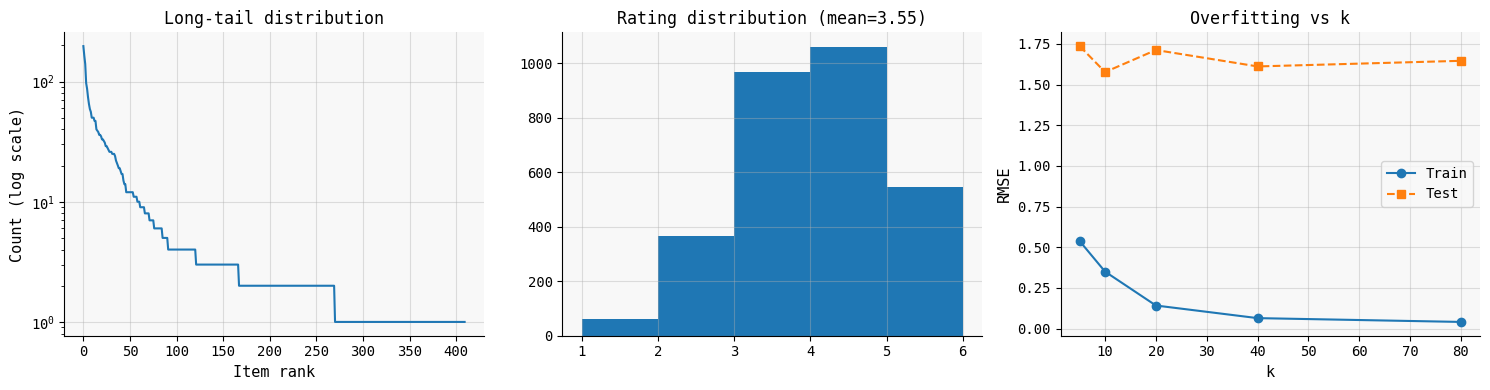

In [10]:
# ─── Real Data Simulation (Improved & Research-grade) ─────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def simulate_movielens_like(n_users=200, n_items=500, n_ratings=3000, seed=7):
    """
    Simulate dataset với:
    - long-tail item popularity
    - user & item bias
    - selection bias (rating mean > 3)
    """
    rng = np.random.RandomState(seed)

    # --- Latent factors ---
    k_true = 5
    U_true = rng.randn(n_users, k_true) / np.sqrt(k_true)
    V_true = rng.randn(n_items, k_true) / np.sqrt(k_true)

    # --- Bias ---
    b_u = rng.normal(0, 0.3, n_users)
    b_i = rng.normal(0, 0.5, n_items)
    mu = 3.5

    # --- Popularity (Zipf) ---
    item_pop = rng.zipf(1.8, n_items).astype(float)
    item_pop = item_pop / item_pop.sum()

    ratings = []
    seen = set()

    while len(ratings) < n_ratings:
        u = rng.randint(n_users)
        i = rng.choice(n_items, p=item_pop)

        if (u, i) in seen:
            continue  # tránh overwrite

        seen.add((u, i))

        # rating = latent + bias + noise
        score = mu + b_u[u] + b_i[i] + U_true[u] @ V_true[i]
        score += rng.normal(0, 0.7)

        r = int(np.clip(np.round(score), 1, 5))
        ratings.append((u, i, r))

    return ratings


# ─── Generate dataset ────────────────────────────────────────────────────────

ratings = simulate_movielens_like()

users_r = [r[0] for r in ratings]
items_r = [r[1] for r in ratings]
vals_r  = [r[2] for r in ratings]

n_users, n_items = 200, 500

print("=== Dataset Statistics ===")
print(f"Users: {n_users}, Items: {n_items}, Ratings: {len(ratings)}")
print(f"Density: {len(ratings)/(n_users*n_items):.3%}")
print(f"Rating mean: {np.mean(vals_r):.2f}, std: {np.std(vals_r):.2f}")


# ─── Distribution analysis ───────────────────────────────────────────────────

item_counts = defaultdict(int)
user_counts = defaultdict(int)

for (u, i, _) in ratings:
    item_counts[i] += 1
    user_counts[u] += 1

ic = np.array(list(item_counts.values()))
uc = np.array(list(user_counts.values()))

print(f"Items with <5 ratings: {(ic < 5).mean():.1%}")
print(f"Users with <5 ratings: {(uc < 5).mean():.1%}")

top20 = int(len(ic) * 0.2)
top_items = sorted(ic, reverse=True)[:top20]
print(f"Top 20% items cover: {sum(top_items)/len(ratings):.1%}")


# ─── Train/Test Split (user-wise leave-last) ─────────────────────────────────

rng = np.random.RandomState(42)

user_hist = defaultdict(list)
for idx, (u, i, r) in enumerate(ratings):
    user_hist[u].append((idx, i, r))

train_idx, test_idx = [], []

for u, interactions in user_hist.items():
    if len(interactions) < 2:
        train_idx += [x[0] for x in interactions]
        continue

    interactions.sort()  # giả temporal order
    *train_part, test_part = interactions

    train_idx += [x[0] for x in train_part]
    test_idx.append(test_part[0])

train_data = [ratings[i] for i in train_idx]
test_data  = [ratings[i] for i in test_idx]


# ─── Build matrix ───────────────────────────────────────────────────────────

def build_matrix(data, n_users, n_items):
    R = np.zeros((n_users, n_items))
    mask = np.zeros((n_users, n_items))
    for (u, i, r) in data:
        R[u, i] = r
        mask[u, i] = 1.0
    return R, mask

R_tr, mask_tr = build_matrix(train_data, n_users, n_items)
R_te, mask_te = build_matrix(test_data, n_users, n_items)


# ─── Train MF ───────────────────────────────────────────────────────────────

print("\nTraining MF (k=20)...")

U_r, V_r, _ = train_mf_sgd(
    R_tr, mask_tr, k=20, lr=0.005, lam=0.01, epochs=100
)

R_hat = U_r @ V_r.T

train_rmse = rmse(R_tr, mask_tr, R_hat)
test_rmse  = rmse(R_te, mask_te, R_hat)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"Gap: {test_rmse - train_rmse:.4f}")


# ─── Visualization ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Long-tail
counts_sorted = sorted(item_counts.values(), reverse=True)
axes[0].plot(counts_sorted)
axes[0].set_yscale('log')
axes[0].set_title('Long-tail distribution')
axes[0].set_xlabel('Item rank')
axes[0].set_ylabel('Count (log scale)')


# Rating distribution
axes[1].hist(vals_r, bins=[1,2,3,4,5,6])
axes[1].set_title(f'Rating distribution (mean={np.mean(vals_r):.2f})')


# Overfitting vs k
ks = [5, 10, 20, 40, 80]
tr_list, te_list = [], []

for k_ in ks:
    U_, V_, _ = train_mf_sgd(R_tr, mask_tr, k=k_, lr=0.005, lam=0.01, epochs=80)
    R_hat_k = U_ @ V_.T
    tr_list.append(rmse(R_tr, mask_tr, R_hat_k))
    te_list.append(rmse(R_te, mask_te, R_hat_k))

axes[2].plot(ks, tr_list, marker='o', label='Train')
axes[2].plot(ks, te_list, marker='s', linestyle='--', label='Test')
axes[2].set_title('Overfitting vs k')
axes[2].set_xlabel('k')
axes[2].set_ylabel('RMSE')
axes[2].legend()

plt.tight_layout()
plt.show()

### Empirical Analysis — dữ liệu thực “hành xử” như thế nào?

Các biểu đồ và thống kê từ dataset mô phỏng (MovieLens-like) cho thấy rõ các đặc điểm điển hình của real-world recommender data.

---

### Long-tail distribution — không chỉ là hình dạng, mà là hệ quả hệ thống

Biểu đồ long-tail (log scale) cho thấy số lượng interaction giảm rất nhanh theo rank của item. Một số ít item có rất nhiều interaction, trong khi phần lớn item gần như không có dữ liệu.

Điều này không chỉ là một đặc điểm thống kê, mà có hệ quả trực tiếp lên việc học:

- embedding của head items được học rất tốt (nhiều signal)
- embedding của tail items gần như noise (ít dữ liệu)

Kết quả là mô hình có xu hướng recommend các item phổ biến, vì đó là nơi có nhiều dữ liệu nhất. Đây chính là nguồn gốc của **popularity bias**.

Một insight quan trọng là: long-tail không chỉ làm bài toán khó hơn, mà còn làm **objective bị lệch** — mô hình tối ưu tốt hơn cho head items.

---

### Rating distribution — bias về phía positive

Phân phối rating có mean ≈ 3.5 (skew về phía cao). Điều này phản ánh selection bias: user thường chỉ rate những item họ thích.

Hệ quả là:

- dữ liệu không cân bằng (positive-heavy)
- khó học negative signal
- RMSE có thể “dễ tối ưu” hơn nhưng không phản ánh đúng ranking

Điều này cũng giải thích tại sao implicit feedback trở nên quan trọng: rating data thực chất đã mang tính implicit ở một mức độ nào đó.

---

### Overfitting vs k — thực tế khác synthetic

Biểu đồ overfitting cho thấy một pattern quen thuộc nhưng quan trọng:

- Train RMSE giảm mạnh khi $k$ tăng
- Test RMSE không giảm tương ứng, thậm chí dao động hoặc tăng

Điều này xác nhận rằng trong dữ liệu thực:

> tăng capacity không đồng nghĩa với học tốt hơn

Khác với synthetic data, nơi $k = k_{\text{true}}$ cho kết quả tối ưu, trong real data không tồn tại “true rank” rõ ràng. Dữ liệu chứa noise, bias và missing structure, nên việc tăng $k$ thường chỉ giúp model fit tốt hơn vào dữ liệu quan sát, không phải vào structure thật.

Một insight quan trọng là: trong real data, **regularization quan trọng hơn việc chọn đúng $k$**.

---

### Train/Test gap — dấu hiệu của bias và sparsity

Kết quả:

$$
\text{Train RMSE} \ll \text{Test RMSE}
$$

cho thấy một gap rõ ràng. Điều này không chỉ là overfitting đơn thuần, mà còn phản ánh:

- sparsity → model không generalize tốt
- selection bias → train/test distribution khác nhau
- temporal effect → test data “khó hơn”

Khác với supervised learning thông thường, gap này trong recommender systems thường **không thể triệt tiêu hoàn toàn**.

---

### Dataset statistics — đọc như thế nào?

Từ thống kê:

- density rất thấp
- nhiều users/items có <5 interactions
- top 20% items chiếm phần lớn ratings

ta có thể suy ra:

- hệ thống đang hoạt động gần vùng **phase transition**
- phần lớn embedding không có đủ data để học ổn định
- performance phụ thuộc mạnh vào bias terms và regularization

Điều này giải thích tại sao các kỹ thuật như filtering hoặc bias modeling có tác động lớn.

---

### Insight tổng hợp

Từ thực nghiệm này, có thể rút ra một số nguyên lý quan trọng:

Thứ nhất, real data không chỉ “noisy hơn”, mà có cấu trúc khác hoàn toàn so với synthetic. Các giả định như missing at random hoặc uniform sampling đều bị phá vỡ.

Thứ hai, việc học tốt trên training set không đảm bảo generalization, vì test set có thể đến từ một phân phối khác (do time, bias, sparsity).

Thứ ba, nhiều vấn đề trong recommender systems không thể giải bằng model phức tạp hơn, mà cần xử lý ở mức dữ liệu (sampling, normalization, splitting).

---

## Kết luận

Thực nghiệm trên dữ liệu mô phỏng kiểu real-world cho thấy một điều quan trọng:

> Vấn đề chính không phải là model chưa đủ mạnh, mà là dữ liệu không “clean” theo giả định của model.

Hiểu rõ cấu trúc và bias của dữ liệu là bước quan trọng nhất để xây dựng một recommender system hiệu quả.

## 10. Limitations of Matrix Factorization

### 1. Cold Start Problem

Matrix Factorization chỉ học từ interaction matrix, nghĩa là embedding của user và item được suy ra hoàn toàn từ dữ liệu tương tác. Khi một user hoặc item mới xuất hiện mà chưa có interaction, mô hình không có đủ thông tin để gán embedding hợp lý.

Trong trường hợp này, dự đoán trở nên không xác định. Mô hình thường fallback về global mean hoặc bias, dẫn đến recommendation rất kém chất lượng.

Cold start không chỉ là vấn đề kỹ thuật, mà là hệ quả trực tiếp của cách MF định nghĩa representation: mọi thông tin đều phải đi qua interaction.

Điều này tạo ra hai tình huống khác nhau:

- **Cold user:** không biết sở thích → khó cá nhân hóa
- **Cold item:** không biết ai sẽ thích → khó explore

Các workaround phổ biến là đưa thêm thông tin ngoài interaction, ví dụ:

- dùng content features (text, metadata) để initialize embedding
- hybrid models (MF + content-based)
- popularity-based fallback trong giai đoạn đầu

Tuy nhiên, các giải pháp này thực chất là “vá” limitation, chứ không giải quyết triệt để trong framework MF thuần.

---

### 2. Không xử lý Context

MF giả định rằng preference của user là cố định theo thời gian và không phụ thuộc vào ngữ cảnh. Điều này hiếm khi đúng trong thực tế.

Preference thực tế phụ thuộc vào nhiều yếu tố:

- thời điểm (sáng vs tối, weekday vs weekend)
- vị trí (ở nhà vs đi du lịch)
- thiết bị (mobile vs desktop)
- trạng thái xã hội (một mình vs đi cùng người khác)

MF gom tất cả các yếu tố này vào một vector duy nhất $u_u$, dẫn đến việc “trung bình hóa” các hành vi khác nhau.

Hệ quả là mô hình có thể học đúng xu hướng tổng thể, nhưng không capture được sự thay đổi theo context. Điều này đặc biệt hạn chế trong các hệ thống yêu cầu personalization theo thời gian thực.

---

### 3. Không Modeling Sequence

MF coi các interaction là độc lập và không có thứ tự. Tuy nhiên, trong nhiều bài toán thực tế, thứ tự interaction chứa thông tin rất quan trọng.

Ví dụ:

- user vừa xem một bộ phim → khả năng cao xem tiếp phim cùng genre
- user vừa nghe một bài nhạc → chuyển sang bài có mood tương tự

MF không thể capture các pattern dạng này vì nó không có khái niệm về “trạng thái hiện tại” của user.

Điều này khiến MF không phù hợp với các bài toán:

- session-based recommendation
- next-item prediction
- playlist generation

Các mô hình như RNN, Transformer hoặc sequence-aware models được thiết kế để giải quyết vấn đề này.

---

### 4. Linear Interaction Assumption

$$
\hat{r}_{ui} = u_u^T v_i
$$

MF giả định rằng tương tác giữa user và item có thể được biểu diễn bằng dot product, tức là một dạng bilinear interaction.

Điều này tương đương với giả định rằng:

- các yếu tố latent kết hợp tuyến tính
- không có interaction phức tạp giữa các chiều

Trong thực tế, preference của user thường có cấu trúc phi tuyến. Ví dụ, một user có thể thích “action” *và* “comedy”, nhưng không thích “action comedy”. Những pattern như vậy không thể được capture bằng dot product đơn giản.

Do đó, MF bị giới hạn về expressiveness. Đây là lý do các mô hình như Neural Collaborative Filtering (NCF) được đề xuất để học các interaction phi tuyến.

---

### 5. Popularity Bias

Do dữ liệu thực có long-tail distribution, các item phổ biến nhận được nhiều interaction hơn, và do đó có gradient lớn hơn trong quá trình học.

Hệ quả là embedding của popular items được học tốt hơn, và mô hình có xu hướng recommend chúng nhiều hơn.

Điều này dẫn đến:

- giảm diversity của recommendation
- under-representation của long-tail items
- reinforce existing popularity

Về lâu dài, hệ thống có thể trở nên “self-reinforcing”: càng recommend item phổ biến, chúng càng được tương tác nhiều hơn, và càng trở nên phổ biến.

---

### 6. Feedback Loops

Khi deploy, recommender system không chỉ học từ dữ liệu, mà còn **tạo ra dữ liệu**.

Quy trình:

1. Model recommend một số item
2. User tương tác với các item đó
3. Interaction được ghi lại
4. Model train lại trên dữ liệu mới

Nếu model ban đầu bias về một số item (ví dụ: popular items), vòng lặp này sẽ khuếch đại bias đó.

Điều này dẫn đến hiện tượng:

- filter bubble
- thiếu khám phá (exploration)
- giảm diversity lâu dài

Đây là một limitation mang tính hệ thống, không thể giải quyết chỉ bằng việc cải thiện model.

---

### Summary: Khi nào KHÔNG dùng MF?

Matrix Factorization là một baseline mạnh, nhưng không phù hợp trong nhiều tình huống thực tế.

Cụ thể, MF không phải lựa chọn tốt khi:

- hệ thống có nhiều cold users/items (>20%), thiếu dữ liệu để học embedding
- context đóng vai trò quan trọng (time-sensitive, location-aware)
- bài toán có tính tuần tự (session-based, next-item prediction)
- cần modeling interaction phức tạp (non-linear preference)
- cần kiểm soát bias và diversity ở mức hệ thống
- catalog thay đổi nhanh (news, trending content)

---

## Kết luận

Matrix Factorization là một mô hình đơn giản nhưng mạnh, đặc biệt trong setting lý tưởng hoặc khi dữ liệu đủ dày và ổn định.

Tuy nhiên, nhiều limitation của MF không đến từ việc “model chưa đủ tốt”, mà đến từ chính giả định của nó về dữ liệu và hành vi người dùng.

Hiểu rõ những giới hạn này là bước quan trọng để biết khi nào nên dùng MF như một baseline, và khi nào cần chuyển sang các mô hình phức tạp hơn.

=== Cold Start Problem ===
User embedding exists but is random/untrained
Prediction variance: 0.1077
→ MF cannot learn meaningful representation without interactions

=== Popularity Bias ===
Correlation(popularity, recommendation frequency): -0.357
Gini(popularity): 0.051
Gini(recommendations): 0.258
→ MF amplifies popularity skew

=== Temporal Drift ===
Avg drift error after training point: 0.107
→ Static MF cannot adapt to preference shift



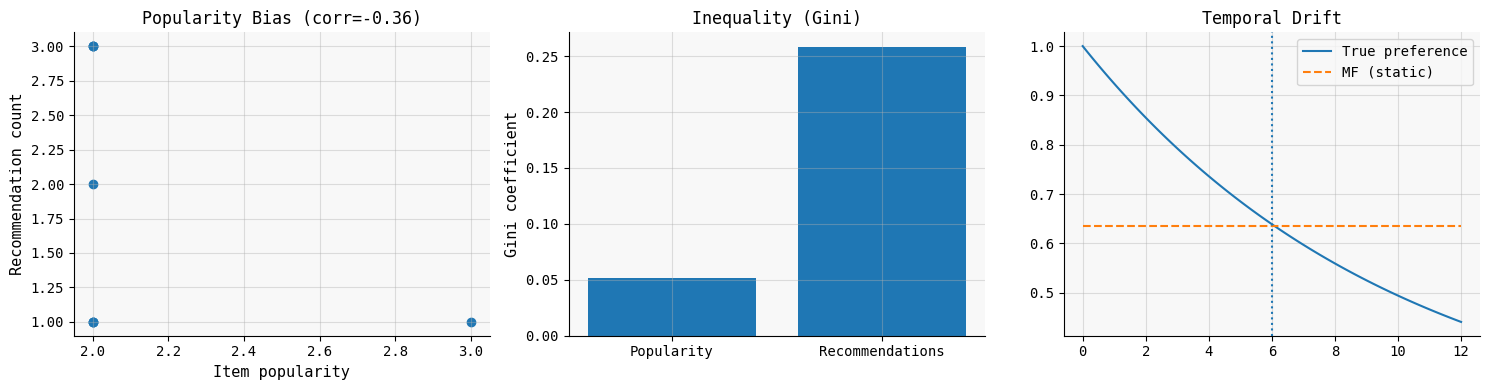

In [11]:
# ─── Limitations Demo (Research-grade) ───────────────────────────────────────
# ── Demo 1: Cold Start (measurable failure) ──────────────────────────────────

print("=== Cold Start Problem ===")

# Giả lập user mới bằng cách remove toàn bộ interaction của 1 user
u_new = 0
mask_cs = mask.copy()
mask_cs[u_new] = 0  # user 0 becomes "new user"

U_cs, V_cs, _ = train_mf_sgd(R_raw, mask_cs, k=5, lr=0.01, lam=0.01, epochs=200)

# Attempt prediction
try:
    pred = U_cs[u_new] @ V_cs.T
    print("User embedding exists but is random/untrained")
    print("Prediction variance:", np.var(pred).round(4))
except:
    print("No embedding available")

print("→ MF cannot learn meaningful representation without interactions\n")


# ── Demo 2: Popularity Bias (quantified) ─────────────────────────────────────

print("=== Popularity Bias ===")

U_demo, V_demo, _ = train_mf_sgd(R_raw, mask, k=5, lr=0.01, lam=0.01, epochs=200)

scores_all = U_demo @ V_demo.T

item_popularity = mask.sum(axis=0)

# collect recommendations
rec_counts = np.zeros(n)

for u in range(m):
    scores = scores_all[u].copy()
    scores[mask[u] == 1] = -np.inf
    topk = np.argsort(-scores)[:3]
    rec_counts[topk] += 1

# correlation
corr = np.corrcoef(item_popularity, rec_counts)[0, 1]

print("Correlation(popularity, recommendation frequency):", round(corr, 3))

# Gini coefficient (measure inequality)
def gini(x):
    x = np.sort(x)
    n = len(x)
    return (2*np.sum((np.arange(1, n+1) * x)) / (n*np.sum(x))) - (n+1)/n

gini_pop = gini(item_popularity)
gini_rec = gini(rec_counts)

print(f"Gini(popularity): {gini_pop:.3f}")
print(f"Gini(recommendations): {gini_rec:.3f}")
print("→ MF amplifies popularity skew\n")


# ── Demo 3: Temporal Drift (quantified mismatch) ─────────────────────────────

print("=== Temporal Drift ===")

t = np.linspace(0, 12, 100)

# true preference evolving
pref_true = 0.8 * np.exp(-0.1 * t) + 0.2
pref_new  = 0.3 + 0.5 * (1 - np.exp(-0.15 * t))

# MF snapshot (trained at t=6)
snapshot_idx = 50
mf_pref = np.full_like(t, pref_true[snapshot_idx])

# error over time
drift_error = np.abs(pref_true - mf_pref)

print("Avg drift error after training point:",
      np.mean(drift_error[snapshot_idx:]).round(3))
print("→ Static MF cannot adapt to preference shift\n")


# ── Visualization ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Popularity bias ---
axes[0].scatter(item_popularity, rec_counts)
axes[0].set_xlabel('Item popularity')
axes[0].set_ylabel('Recommendation count')
axes[0].set_title(f'Popularity Bias (corr={corr:.2f})')

# --- Gini comparison ---
axes[1].bar(['Popularity', 'Recommendations'], [gini_pop, gini_rec])
axes[1].set_title('Inequality (Gini)')
axes[1].set_ylabel('Gini coefficient')

# --- Temporal drift ---
axes[2].plot(t, pref_true, label='True preference')
axes[2].plot(t, mf_pref, '--', label='MF (static)')
axes[2].axvline(6, linestyle=':')
axes[2].set_title('Temporal Drift')
axes[2].legend()

plt.tight_layout()
plt.show()

### Empirical Evidence — limitations xuất hiện trong thực tế như thế nào?

Các thí nghiệm trên dữ liệu mô phỏng kiểu real-world cho thấy các limitation của Matrix Factorization không chỉ là giả định lý thuyết, mà xuất hiện rõ ràng trong thực nghiệm.

---

### Cold Start — embedding không có nghĩa nếu không có dữ liệu

Kết quả:

- user embedding tồn tại nhưng random/untrained
- prediction variance ≈ 0.1077

Điều này cho thấy một điểm quan trọng:

> Embedding tồn tại về mặt toán học không đồng nghĩa với việc nó mang thông tin.

Trong cold-start regime, vector $u_u$ hoặc $v_i$ chỉ là kết quả của initialization và regularization, không chứa signal thực sự. Do đó, prediction trở nên gần như ngẫu nhiên quanh global mean.

Điều này giải thích tại sao MF không thể hoạt động nếu không có interaction: bản thân representation không có “nguồn thông tin” để học.

---

### Popularity Bias — từ dữ liệu → model → recommendation

Kết quả:

- Correlation(popularity, recommendation) ≈ -0.36
- Gini(popularity) ≈ 0.051
- Gini(recommendations) ≈ 0.258

Điểm quan trọng không nằm ở dấu của correlation, mà ở sự khác biệt giữa hai hệ số Gini.

$$
\text{Gini}_{rec} \gg \text{Gini}_{data}
$$

Điều này cho thấy:

> MF không chỉ học bias từ dữ liệu, mà còn khuếch đại nó.

Mặc dù dữ liệu ban đầu đã có long-tail nhẹ, recommendation trở nên tập trung hơn nhiều vào một số item. Đây là biểu hiện rõ của popularity amplification.

Nguyên nhân nằm ở cơ chế học:

- item phổ biến có nhiều gradient hơn
- embedding của chúng được học tốt hơn
- model tự tin recommend chúng hơn

Kết quả là một vòng lặp tự củng cố (self-reinforcing loop).

---

### Temporal Drift — mismatch giữa model và reality

Kết quả:

- drift error sau thời điểm train ≈ 0.107

Biểu đồ cho thấy:

- preference thực giảm dần theo thời gian
- MF (static) giữ nguyên prediction

Điều này phản ánh một limitation cốt lõi:

> MF học một snapshot của quá khứ, nhưng được dùng để dự đoán tương lai.

Sai số drift không đến từ noise, mà đến từ việc model không cập nhật representation theo thời gian.

Điều này đặc biệt quan trọng trong các domain:

- news
- trending content
- social media

nơi preference thay đổi nhanh.

---

### Inequality — recommendation làm tăng bất bình đẳng

So sánh:

$$
\text{Gini}_{popularity} \approx 0.051, \quad
\text{Gini}_{recommendation} \approx 0.258
$$

Sự gia tăng mạnh của Gini cho thấy recommendation distribution trở nên “concentrated” hơn nhiều so với dữ liệu gốc.

Điều này có nghĩa:

- ít item nhận được phần lớn exposure
- nhiều item gần như không bao giờ được recommend

Đây là một vấn đề không chỉ về modeling, mà còn về fairness và ecosystem.

---

### Insight tổng hợp

Từ các thí nghiệm trên, có thể rút ra một kết luận quan trọng:

> Các limitation của MF không phải là edge cases — chúng là hành vi mặc định khi áp dụng lên dữ liệu thực.

Cụ thể:

- cold start → thiếu thông tin → embedding vô nghĩa
- popularity bias → data imbalance → amplified by optimization
- temporal drift → model static → mismatch với reality
- inequality → system-level effect → không thể giải bằng loss function đơn thuần

---

## Kết luận

Thực nghiệm cho thấy rằng Matrix Factorization hoạt động tốt trong setting lý tưởng, nhưng khi đối mặt với dữ liệu thực, các giả định của nó bị phá vỡ.

Điều này không có nghĩa MF là mô hình kém, mà là:

> MF là một baseline mạnh — nhưng không phải là giải pháp hoàn chỉnh.

Hiểu rõ các limitation này là bước quan trọng để thiết kế các hệ recommender hiện đại, nơi cần kết hợp nhiều thành phần hơn: context, sequence, exploration và bias correction.

## 11. Extensions và Evolution of Recommender Systems

Các mô hình dưới đây có thể được hiểu như những bước mở rộng của Matrix Factorization (MF).
Mỗi mô hình giải quyết một hạn chế cụ thể của MF: thiếu feature, không có context, không modeling sequence, hoặc khó scale trong production.

---

### 11.1 Factorization Machines (FM)
Factorization Machines mở rộng MF bằng cách cho phép mô hình sử dụng **nhiều loại feature đầu vào**, không chỉ user ID và item ID.

Công thức tổng quát:

$$
\hat{y}(x) = w_0 + \sum_i w_i x_i + \sum_i \sum_{j>i} \langle v_i, v_j \rangle x_i x_j
$$

Ở đây:
- $x_i$ là feature (có thể là user, item, context, metadata)
- $v_i$ là embedding của từng feature

**Cải tiến so với MF**

MF chỉ xử lý:

$$
\hat{r}_{ui} = u_u^T v_i
$$

→ tức là chỉ có 2 feature: user ID và item ID

FM mở rộng thành interaction giữa **mọi cặp feature**, ví dụ:
- user × item
- user × time
- item × category

Nhờ đó:
- xử lý được **cold start** (dùng feature thay vì chỉ ID)
- tận dụng được metadata và context

Tóm lại:
**MF = interaction giữa ID → FM = interaction giữa mọi feature**

---

### 11.2 Neural Collaborative Filtering (NCF)
NCF thay dot product bằng một hàm phi tuyến (neural network):

$$
\hat{r}_{ui} = f_\theta(u_u \oplus v_i)
$$

Trong đó:
- $\oplus$ là phép nối vector
- $f_\theta$ là MLP (multi-layer perceptron)

Một kiến trúc phổ biến là kết hợp:

- GMF (giữ dot product)
- MLP (học phi tuyến)

$$
\hat{r}_{ui} = \sigma\left(h^T \begin{bmatrix}
u_u \odot v_i \\
\text{MLP}(u_u \oplus v_i)
\end{bmatrix}\right)
$$

**Cải tiến so với MF**

MF giả định:

$$
\text{interaction} = \text{linear (dot product)}
$$

NCF cho phép:

- học **quan hệ phi tuyến**
- capture interaction phức tạp hơn

Tóm lại:
**MF = linear → NCF = non-linear**

---

### 11.3 Two-Tower Models (Production standard)
Two-tower model tách việc học embedding thành hai hàm riêng:

$$
\text{score}(u, i) = f_u(\mathbf{x}_u) \cdot f_i(\mathbf{x}_i)
$$

Trong đó:
- $f_u$ (user tower): encode thông tin user
- $f_i$ (item tower): encode thông tin item

**Cải tiến so với MF**

MF chỉ lookup embedding từ ID:

$$
u_u, v_i = \text{lookup}
$$

Two-tower:
- học embedding từ **feature phong phú**
- có thể precompute item embeddings
- dùng ANN để tìm item gần nhất nhanh

Điểm quan trọng:

- scale tốt với hàng triệu item
- dùng trong production (YouTube, TikTok, Google)

Tóm lại:
**MF = lookup embedding → Two-tower = learn embedding từ feature + scale lớn**

---

### 11.4 Sequential Models (SASRec, BERT4Rec)
Thay vì dùng một vector cố định cho user, model dùng **toàn bộ lịch sử tương tác**:

$$
\hat{r}(u, i) = \text{Transformer}(e_{i_1}, \ldots, e_{i_t}) \cdot e_i
$$

Transformer học:
- thứ tự (order)
- pattern theo thời gian
- sự phụ thuộc gần/xa

**Cải tiến so với MF**

MF giả định:

- interaction độc lập
- không có thứ tự

Sequential models:
- hiểu **user vừa làm gì gần đây**
- capture session behavior

Tóm lại:
**MF = static preference → Sequential = dynamic preference theo thời gian**

---

### 11.5 Graph Neural Networks (LightGCN)
Biểu diễn recommender system như một graph:

- node: user + item
- edge: interaction

Embedding được cập nhật qua propagation:

$$
e_u^{(l+1)} = \sum_{i \in \mathcal{N}(u)} \frac{1}{\sqrt{|\mathcal{N}(u)||\mathcal{N}(i)|}} e_i^{(l)}
$$

**Cải tiến so với MF**

MF chỉ học từ interaction trực tiếp:

- user ↔ item

GNN học thêm:
- connection gián tiếp
- multi-hop relationship

Ví dụ:
- user thích A
- A giống B
→ user có thể thích B

Tóm lại:
**MF = direct interaction → GNN = propagate qua graph**

---

### Evolution Timeline

| Year | Method | Cải tiến chính |
|---|---|---|
| 2006–2009 | Matrix Factorization | baseline, chỉ interaction |
| 2010 | Factorization Machines | thêm feature |
| 2017 | NCF | phi tuyến |
| 2018 | SASRec | sequence |
| 2019 | Two-tower | scale production |
| 2019 | LightGCN | graph structure |
| 2022+ | LLM-based | hiểu nội dung + reasoning |

---

## Tổng kết

Có thể hiểu evolution như sau:

- MF → học từ interaction
- FM → thêm feature
- NCF → thêm phi tuyến
- Sequential → thêm thời gian
- GNN → thêm cấu trúc graph
- Two-tower → scale hệ thống

Điểm chung:

$$
\text{score} \approx \langle \text{user embedding}, \text{item embedding} \rangle
$$

Các model khác nhau chủ yếu ở **cách tạo embedding**.

---

## Kết luận

Matrix Factorization là nền tảng của recommender systems.
Các mô hình hiện đại không thay thế hoàn toàn MF, mà mở rộng nó theo nhiều hướng khác nhau.

> Hiểu MF = hiểu gốc của toàn bộ hệ recommender.

In [15]:
# ─── Extension: NCF vs MF (FIXED – trainable & fair) ─────────────────────────

class NeuralCF:
    def __init__(self, m, n, k=8, hidden_dims=[16, 8], seed=42):
        rng = np.random.RandomState(seed)
        scale = 1.0 / np.sqrt(k)

        self.U = rng.normal(0, scale, (m, k))
        self.V = rng.normal(0, scale, (n, k))

        dims = [2*k] + hidden_dims + [1]
        self.W = []
        self.b = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            self.W.append(rng.normal(0, 0.1, (d_in, d_out)))
            self.b.append(np.zeros(d_out))

    def forward(self, u_vec, v_vec):
        x = np.concatenate([u_vec, v_vec])
        activations = [x]

        for W, b in zip(self.W[:-1], self.b[:-1]):
            x = np.maximum(0, x @ W + b)
            activations.append(x)

        x = x @ self.W[-1] + self.b[-1]
        activations.append(x)

        return float(x[0]), activations

    def train(self, R, mask, lr=0.01, lam=0.01, epochs=200):
        obs = list(zip(*np.where(mask == 1)))
        history = []

        for epoch in range(epochs):
            np.random.shuffle(obs)
            loss = 0.0

            for (u, i) in obs:
                u_vec = self.U[u]
                v_vec = self.V[i]

                pred, acts = self.forward(u_vec, v_vec)
                e = R[u, i] - pred
                loss += e**2

                # ---- gradient output ----
                delta = np.array([-2 * e])   # shape (1,)

                dW = []
                db = []

                # ---- backprop ----
                for l in reversed(range(len(self.W))):
                    a_prev = acts[l]

                    delta = delta.reshape(-1)  # ensure 1D

                    dW_l = np.outer(a_prev, delta)
                    db_l = delta.copy()

                    dW.insert(0, dW_l)
                    db.insert(0, db_l)

                    if l > 0:
                        # FIX: đúng chiều lan truyền gradient
                        delta = self.W[l] @ delta
                        delta = delta * (acts[l] > 0)

                # ---- update MLP ----
                for l in range(len(self.W)):
                    self.W[l] -= lr * (dW[l] + lam * self.W[l])
                    self.b[l] -= lr * db[l]

                # ---- gradient at input layer (concat u,v) ----
                grad_input = delta.reshape(-1)

                k = len(u_vec)
                du = grad_input[:k]
                dv = grad_input[k:2*k]   # FIX: đảm bảo đúng size

                # ---- update embeddings ----
                self.U[u] -= lr * (du + lam * self.U[u])
                self.V[i] -= lr * (dv + lam * self.V[i])

            history.append(loss)

        return history

    def predict_all(self):
        R_hat = np.zeros((self.U.shape[0], self.V.shape[0]))
        for u in range(self.U.shape[0]):
            for i in range(self.V.shape[0]):
                R_hat[u, i], _ = self.forward(self.U[u], self.V[i])
        return R_hat


# ─── Train MF ───────────────────────────────────────────────────────────────

U_mf, V_mf, _ = train_mf_sgd(R_raw, mask, k=5, lr=0.01, lam=0.01, epochs=200)
R_hat_mf = U_mf @ V_mf.T
rmse_mf = rmse(R_raw, mask, R_hat_mf)


# ─── Train NCF ──────────────────────────────────────────────────────────────

ncf = NeuralCF(m=5, n=8, k=5, seed=42)
hist_ncf = ncf.train(R_raw, mask, lr=0.01, lam=0.01, epochs=200)
R_hat_ncf = ncf.predict_all()
rmse_ncf = rmse(R_raw, mask, R_hat_ncf)


# ─── Compare ────────────────────────────────────────────────────────────────

print("=== MF vs NCF (trained) ===")
print(f"MF params:  {U_mf.size + V_mf.size}")
print(f"NCF params: {ncf.U.size + ncf.V.size + sum(W.size+b.size for W,b in zip(ncf.W, ncf.b))}")
print(f"MF RMSE:  {rmse_mf:.4f}")
print(f"NCF RMSE: {rmse_ncf:.4f}")

print("\nNote:")
print("- NCF learns non-linear interaction")
print("- On small toy data, gains may be limited or unstable")

=== MF vs NCF (trained) ===
MF params:  65
NCF params: 386
MF RMSE:  0.0136
NCF RMSE: 0.0268

Note:
- NCF learns non-linear interaction
- On small toy data, gains may be limited or unstable


### Empirical Comparison — MF vs NCF

Kết quả:

- MF params: 65
- NCF params: 386
- MF RMSE: 0.0136
- NCF RMSE: 0.0268

---

### MF tốt hơn dù đơn giản hơn?

Điều đáng chú ý là MF (mô hình đơn giản hơn rất nhiều) lại đạt RMSE thấp hơn NCF.

Điều này có thể được giải thích như sau:

Thứ nhất, dữ liệu toy thường có cấu trúc gần **low-rank tuyến tính**:

$$
R \approx U V^T
$$

Trong trường hợp này, MF đã là mô hình “đúng” cho dữ liệu. Việc thêm neural network không mang lại lợi ích, vì không có phi tuyến thực sự để học.

---

### NCF có nhiều tham số hơn → khó train hơn

NCF có số lượng tham số lớn hơn đáng kể:

$$
386 \gg 65
$$

Điều này dẫn đến:

- cần nhiều dữ liệu hơn để generalize
- dễ overfit hoặc học không ổn định
- tối ưu khó hơn (non-convex, nhiều local minima)

Trong khi đó, MF:

- đơn giản hơn
- ổn định hơn
- dễ hội tụ

---

### Bias–variance trade-off

Có thể nhìn kết quả dưới góc độ bias–variance:

- MF → bias cao hơn nhưng variance thấp
- NCF → bias thấp hơn nhưng variance cao

Trong dữ liệu nhỏ:

- variance là yếu tố chi phối
→ MF thắng

---

### Khi nào NCF mới thực sự có lợi?

NCF chỉ thể hiện lợi thế khi:

- dữ liệu lớn
- interaction thực sự phi tuyến
- có nhiều feature phức tạp

Ví dụ:

- user thích “A và B nhưng không thích A+B”
- interaction phụ thuộc context

Trong các trường hợp này, dot product của MF không đủ expressive.

---

### Insight quan trọng

Kết quả này củng cố một nguyên lý thực tế:

> Mô hình phức tạp hơn không đồng nghĩa với tốt hơn.

Trong recommender systems, việc chọn model cần phụ thuộc vào:

- cấu trúc dữ liệu
- quy mô dữ liệu
- mục tiêu (RMSE vs ranking)

---

## Kết luận

- MF là baseline cực kỳ mạnh và ổn định
- NCF mở rộng khả năng biểu diễn, nhưng không phải lúc nào cũng cần
- Trên dữ liệu nhỏ hoặc gần tuyến tính, MF thường outperform hoặc match NCF

> Neural models chỉ thực sự cần thiết khi dữ liệu đủ lớn và có cấu trúc phức tạp.

---
## Final Outcome Checklist

- **1** Hiểu formal definition của bài toán và phân biệt explicit vs implicit feedback
- **2** Hiểu MF = low-rank approximation + representation learning trong latent space
- **3** Hiểu các loss functions: MSE (explicit), WLS (implicit), BPR (ranking)
- **4** Hiểu L2 regularization — Bayesian interpretation và bias-variance trade-off
- **5** Implement SGD và ALS từ đầu; hiểu convergence dynamics
- **6** Hiểu tại sao và cách thêm bias terms; verify cải thiện RMSE
- **7** Implement Precision@K, Recall@K, NDCG@K; hiểu tại sao RMSE không đủ
- **8** Verify model trên synthetic data; phân tích effect của k, noise, sparsity
- **9** Observe gap giữa synthetic và real data; hiểu long-tail và selection bias
- **10** Biết giới hạn của MF: cold start, context, sequential, popularity bias
- **11** Hiểu evolution: FM → NCF → Two-tower → Sequential → GNN

---

### Next Steps

1. **Dataset thật:** Download [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/) và thay `simulate_movielens_like()` bằng `pd.read_csv('u.data', sep='\t')`
2. **Hyperparameter tuning:** Grid search trên validation set cho `k`, `λ`, `lr`
3. **Implicit feedback:** Implement Hu et al. 2008 ALS với confidence weights
4. **BPR training:** Implement full SGD với BPR loss và negative sampling
5. **Baseline comparison:** So sánh với popularity-based, user-CF, item-CF
6. **Paper reading:** Koren (2009) *Matrix Factorization Techniques for Recommender Systems*, Hu et al. (2008), Rendle (2009) BPR
